## 906 LVTestCase — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on the **IEEE European LV Test Case** (906 buses / LVTestCase).

This mirrors the 8500 **no-BESS** chunked driver in `withder.ipynb` (calls a thin Python generator per chunk).

### Full vs smoke sizes (same as 8500 chunked)
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### Differences vs 8500
| | IEEE 8500 unbalanced | 906 LVTestCase |
|---|---|---|
| DER | PV (+ optional BESS) | none (`p_pv_kw=0`) |
| Controls | regs + caps (real meta) | **none** — dummy constant 8500 `reg_*` / `cap_*` meta cols for trainer schema |
| Profiles | 5-min load + irradiance (288 pts) | 1-min per-load shapes (1440 pts) |
| MV aggregation | split-phase → MV `*_mvagg.csv` | **no real mvagg** — writes `gnn_node_features_and_targets_mvagg.csv` as a compat copy |
| Physics loss | optional (8500 Y / device catalog) | keep **off** (no regs/caps / no 8500 catalog) |

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (incl. Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` (incl. dummy cap/reg columns)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads

### After generation
Point the DA-GPS training cell’s `CHUNK_PARENT` at `CHUNK_ROOT` below (same layout as 8500: parent of `run_*` folders). See the short follow-up cell after the generator.


In [ ]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — 906 LVTestCase
# - runs in chunks
# - different seed per chunk
# - different output folder per chunk
# - PE computed from static edges each chunk (node_pe_k > 0, no CSV)
# - writes *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 cap/reg meta columns for existing DA-GPS trainer schema
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny run to verify paths / OpenDSS; False = full dataset

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 90620230

SIGMA_LOAD = 0.5
SIGMA_PV = 0.0  # unused (no PV); kept for parity with 8500 cell

# Nominal: 55 x 1 kW @ PF 0.95  →  P≈55 kW, Q≈18.08 kvar
P_LOAD_MEAN_KW = 55.0
Q_LOAD_MEAN_KVAR = 18.077625784837476
P_LOAD_SCALE_RANGE = (0.3, 1.8)
Q_LOAD_SCALE_RANGE = (0.3, 1.8)
P_PV_SCALE_RANGE = (0.0, 0.0)  # no PV on LVTestCase

VMIN_SAFE_PU = 0.55
VMAX_SAFE_PU = 1.45

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

# Colab / Windows / local defaults — edit CHUNK_ROOT to your Drive / disk
CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_906_lvtestcase.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_906_lvtestcase.py")

# Do NOT use Path("/content/...").exists() — on Windows that is drive-root-relative
# (e.g. C:\content\...) and stays True forever after a mistaken mkdir.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_906_lvtestcase_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_906_lvtestcase_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_906_lvtestcase_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_906_lvtestcase.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_906_lvtestcase", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

# ---------------- preflight ----------------
model_dir = ns["MODEL_DIR"]
master_dss = ns["MASTER_DSS"]
print("MODEL_DIR:", model_dir)
print("MASTER_DSS exists:", master_dss.is_file())
if not master_dss.is_file():
    raise FileNotFoundError(f"Missing LVTestCase Master.dss: {master_dss}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST}")
print(f"P_LOAD_MEAN_KW={P_LOAD_MEAN_KW}  Q_LOAD_MEAN_KVAR={Q_LOAD_MEAN_KVAR}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_mean_kw=float(P_LOAD_MEAN_KW),
        q_load_mean_kvar=float(Q_LOAD_MEAN_KVAR),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_906_lvtestcase"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


## DA-GPS training on 906 LVTestCase (chunked)

Train the existing multitask DA-GPS model on the **already-generated** 906 chunked dataset. **Do not regenerate** data for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`

### System / latent tokens (this trainer)

`--n_system_tokens` allocates learnable **global tokens** after the fixed cap-bank and regulator tokens. With `--aux_meta_cols col0,col1,...`, column `i` supervises system-token slot `i` (global index `n_cap + n_reg + i`) via normalized MSE (`--lambda_pv`). Remaining system tokens (if any) stay unsupervised latents. For 906 we use **2** tokens tied to **substation upstream P and Q**: `P_grid_upstream_post_kw,Q_grid_upstream_post_kvar`.

### 906 vs 8500 training differences

| Setting | 8500 (typical) | 906 (this cell) |
|--------|----------------|-----------------|
| Dataset | `original_8500_..._2000_40` | `original_906_lvtestcase_chunked` |
| Meta aux | PV + losses | Substation P/Q only |
| `n_system_tokens` | 10 | 2 |
| Cap / reg loss | `lambda_cap/reg > 0` | **0** (dummy columns only) |
| PV aux weight | `lambda_pv > 0` on PV cols | `lambda_pv` on grid P/Q (no `pv_pv2_*`) |
| Physics | optional PF catalogs | **always off** (`PHYSICS_WEIGHT=0`) |
| Loss meta units | as stored | `--meta_loss_scale 0.001` if/when `P_loss_*` / `Q_loss_*` are ingested |

### Loss scale without regenerating CSVs

906 meta currently stores `P_loss_total_post_kw` / `Q_loss_total_post_kvar` ~**1000x** too large. The trainer flag `--meta_loss_scale 0.001` multiplies those two columns whenever they are loaded into aux/cache targets (default `1.0` keeps 8500 unchanged). This cell passes `0.001` for correctness if losses are ever added to `--aux_meta_cols`; substation P/Q tokens are **not** scaled.

### Smoke vs full

- `SMOKE_TEST=True`: prefer the first few **full-size** `run_*` chunks (scen span ≥ 50 in the folder name); if none exist, fall back to any `run_*`. Fewer epochs (fast check).
- `SMOKE_TEST=False`: **all full-size** chunks only (scen span ≥ 50). Smoke folders like `run_001_scen_0000_0001_...` (span=2) are **auto-skipped** — leave them on disk; no need to delete.

Caches use **906-specific** names (`da_gps_chunked_906_...`) so they never collide with 8500 caches. Runs go under `.../datasets_gnn2/runs`.


In [15]:
# --- DA-GPS training on 906 LVTestCase (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_906_lvtestcase_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_906_smoke_gine" if SMOKE_TEST else "da_gps_chunked_906_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_906_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_906_lvtestcase_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for 906 (no 8500 PF catalogs)

# Substation upstream P/Q only (no PV aux, no loss tokens)
META_AUX_COLS = "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar"
N_SYSTEM_TOKENS = 2
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the 2 system tokens
LAMBDA_CAP = 0.0
LAMBDA_REG = 0.0

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (906 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_906_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_gridPQ"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for 906 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


FileNotFoundError: Repo root missing trainer script: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced

Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
  SKIP  run_001_scen_0000_0001_seed_90720233 (span=2; need span>=50 for full training)
  SKIP  run_002_scen_0002_0003_seed_90820236 (span=2; need span>=50 for full training)
  KEEP  run_001_scen_0000_0049_seed_90720233 (span=50; full)
  KEEP  run_002_scen_0050_0099_seed_90820236 (span=50; full)
  KEEP  run_003_scen_0100_0149_seed_90920239 (span=50; full)
  KEEP  run_004_scen_0150_0199_seed_91020242 (span=50; full)
  KEEP  run_005_scen_0200_0249_seed_91120245 (span=50; full)
  KEEP  run_006_scen_0250_0299_seed_91220248 (span=50; full)
  KEEP  run_007_scen_0300_0349_seed_91320251 (span=50; full)
  KEEP  run_008_scen_0350_0399_seed_91420254 (span=50; full)
  KEEP  run_009_scen_0400_0449_seed_91520257 (span=50; full)
  KEEP  run_010_scen_0450_0499_seed_91620260 (span=50; full)
  KEEP  run_011_scen_0500_0549_seed_91720263 (span=50; full)
  KEEP  run_012_scen_0550_0599_seed_91820266 (span=50; full)
  KEEP  run_013_scen_0600_0649_seed_91920269 (span=50; full)
  KEEP  run_014_scen_0650_0699_seed_92020272 (span=50; full)
  KEEP  run_015_scen_0700_0749_seed_92120275 (span=50; full)
  KEEP  run_016_scen_0750_0799_seed_92220278 (span=50; full)
  KEEP  run_017_scen_0800_0849_seed_92320281 (span=50; full)
  KEEP  run_018_scen_0850_0899_seed_92420284 (span=50; full)
  KEEP  run_019_scen_0900_0949_seed_92520287 (span=50; full)
  KEEP  run_020_scen_0950_0999_seed_92620290 (span=50; full)
  KEEP  run_021_scen_1000_1049_seed_92720293 (span=50; full)
  KEEP  run_022_scen_1050_1099_seed_92820296 (span=50; full)
  KEEP  run_023_scen_1100_1149_seed_92920299 (span=50; full)
  KEEP  run_024_scen_1150_1199_seed_93020302 (span=50; full)
  KEEP  run_025_scen_1200_1249_seed_93120305 (span=50; full)
  KEEP  run_026_scen_1250_1299_seed_93220308 (span=50; full)
  KEEP  run_027_scen_1300_1349_seed_93320311 (span=50; full)
  KEEP  run_028_scen_1350_1399_seed_93420314 (span=50; full)
  KEEP  run_029_scen_1400_1449_seed_93520317 (span=50; full)
  KEEP  run_030_scen_1450_1499_seed_93620320 (span=50; full)
  KEEP  run_031_scen_1500_1549_seed_93720323 (span=50; full)
  KEEP  run_032_scen_1550_1599_seed_93820326 (span=50; full)
  KEEP  run_033_scen_1600_1649_seed_93920329 (span=50; full)
  KEEP  run_034_scen_1650_1699_seed_94020332 (span=50; full)
  KEEP  run_035_scen_1700_1749_seed_94120335 (span=50; full)
  KEEP  run_036_scen_1750_1799_seed_94220338 (span=50; full)
  KEEP  run_037_scen_1800_1849_seed_94320341 (span=50; full)
  KEEP  run_038_scen_1850_1899_seed_94420344 (span=50; full)
  KEEP  run_039_scen_1900_1949_seed_94520347 (span=50; full)
  KEEP  run_040_scen_1950_1999_seed_94620350 (span=50; full)
=== Preflight (906 DA-GPS) ===
REPO:           /content/GNN-Sandia
SMOKE_TEST:     False
SMOKE_CHUNK_COUNT: 3
CHUNK_GLOB:     run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350
EPOCHS:         200
PATIENCE:       30
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
META_AUX_COLS:  P_grid_upstream_post_kw,Q_grid_upstream_post_kvar
N_SYSTEM_TOKENS:2
META_LOSS_SCALE:0.001
lambda_cap/reg/pv: 0.0/0.0/0.1
PHYSICS_WEIGHT: 0.0
run_* preview:  ['run_001_scen_0000_0001_seed_90720233', 'run_001_scen_0000_0049_seed_90720233', 'run_002_scen_0002_0003_seed_90820236', 'run_002_scen_0050_0099_seed_90820236', 'run_003_scen_0100_0149_seed_90920239']
NODE_PE_CSV:    /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)
=================
Found 40 chunk(s) for CHUNK_GLOB under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
PHYSICS_WEIGHT=0.0 (baseline; no 8500 physics)
early_stop_on=total

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 2 --aux_meta_cols P_grid_upstream_post_kw,Q_grid_upstream_post_kvar --meta_loss_scale 0.001 --lambda_pv 0.1 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --heads 2 --node_emb_dim 2 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.0 --lambda_reg 0.0 --reg_loss mse --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

meta_loss_scale=0.001: scaling P_loss_total_post_kw / Q_loss_total_post_kvar when those columns are loaded as meta-aux targets
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
Meta aux (sample_meta): 2 column(s); chunk DA caches use suffix __mauxa6f0b9b7 (per chunk name).
  global token index 22 (system slot 0): column 'p_grid_upstream_post_kw'
  global token index 23 (system slot 1): column 'q_grid_upstream_post_kvar'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
  - run_001_scen_0000_0049_seed_90720233
  - run_002_scen_0050_0099_seed_90820236
  - run_003_scen_0100_0149_seed_90920239
  - run_004_scen_0150_0199_seed_91020242
  - run_005_scen_0200_0249_seed_91120245
  - run_006_scen_0250_0299_seed_91220248
  - run_007_scen_0300_0349_seed_91320251
  - run_008_scen_0350_0399_seed_91420254
  - run_009_scen_0400_0449_seed_91520257
  - run_010_scen_0450_0499_seed_91620260
  - run_011_scen_0500_0549_seed_91720263
  - run_012_scen_0550_0599_seed_91820266
  - run_013_scen_0600_0649_seed_91920269
  - run_014_scen_0650_0699_seed_92020272
  - run_015_scen_0700_0749_seed_92120275
  - run_016_scen_0750_0799_seed_92220278
  - run_017_scen_0800_0849_seed_92320281
  - run_018_scen_0850_0899_seed_92420284
  - run_019_scen_0900_0949_seed_92520287
  - run_020_scen_0950_0999_seed_92620290
  - run_021_scen_1000_1049_seed_92720293
  - run_022_scen_1050_1099_seed_92820296
  - run_023_scen_1100_1149_seed_92920299
  - run_024_scen_1150_1199_seed_93020302
  - run_025_scen_1200_1249_seed_93120305
  - run_026_scen_1250_1299_seed_93220308
  - run_027_scen_1300_1349_seed_93320311
  - run_028_scen_1350_1399_seed_93420314
  - run_029_scen_1400_1449_seed_93520317
  - run_030_scen_1450_1499_seed_93620320
  - run_031_scen_1500_1549_seed_93720323
  - run_032_scen_1550_1599_seed_93820326
  - run_033_scen_1600_1649_seed_93920329
  - run_034_scen_1650_1699_seed_94020332
  - run_035_scen_1700_1749_seed_94120335
  - run_036_scen_1750_1799_seed_94220338
  - run_037_scen_1800_1849_seed_94320341
  - run_038_scen_1850_1899_seed_94420344
  - run_039_scen_1900_1949_seed_94520347
  - run_040_scen_1950_1999_seed_94620350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_002_scen_0050_0099_seed_90820236/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_002_scen_0050_0099_seed_90820236__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_003_scen_0100_0149_seed_90920239/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_003_scen_0100_0149_seed_90920239__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_004_scen_0150_0199_seed_91020242/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_004_scen_0150_0199_seed_91020242__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_005_scen_0200_0249_seed_91120245/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_005_scen_0200_0249_seed_91120245__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_006_scen_0250_0299_seed_91220248/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_006_scen_0250_0299_seed_91220248__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_007_scen_0300_0349_seed_91320251/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_007_scen_0300_0349_seed_91320251__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_008_scen_0350_0399_seed_91420254/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_008_scen_0350_0399_seed_91420254__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_009_scen_0400_0449_seed_91520257/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_009_scen_0400_0449_seed_91520257__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_010_scen_0450_0499_seed_91620260/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_010_scen_0450_0499_seed_91620260__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_011_scen_0500_0549_seed_91720263/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_011_scen_0500_0549_seed_91720263__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_012_scen_0550_0599_seed_91820266/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_012_scen_0550_0599_seed_91820266__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_013_scen_0600_0649_seed_91920269/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_013_scen_0600_0649_seed_91920269__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_014_scen_0650_0699_seed_92020272/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_014_scen_0650_0699_seed_92020272__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_015_scen_0700_0749_seed_92120275/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_015_scen_0700_0749_seed_92120275__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_016_scen_0750_0799_seed_92220278/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_016_scen_0750_0799_seed_92220278__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_017_scen_0800_0849_seed_92320281/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_017_scen_0800_0849_seed_92320281__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_018_scen_0850_0899_seed_92420284/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_018_scen_0850_0899_seed_92420284__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_019_scen_0900_0949_seed_92520287/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_019_scen_0900_0949_seed_92520287__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_020_scen_0950_0999_seed_92620290/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_020_scen_0950_0999_seed_92620290__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_021_scen_1000_1049_seed_92720293/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_021_scen_1000_1049_seed_92720293__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_022_scen_1050_1099_seed_92820296/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_022_scen_1050_1099_seed_92820296__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_023_scen_1100_1149_seed_92920299/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_023_scen_1100_1149_seed_92920299__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_024_scen_1150_1199_seed_93020302/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_024_scen_1150_1199_seed_93020302__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_025_scen_1200_1249_seed_93120305/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_025_scen_1200_1249_seed_93120305__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_026_scen_1250_1299_seed_93220308/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_026_scen_1250_1299_seed_93220308__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_027_scen_1300_1349_seed_93320311/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_027_scen_1300_1349_seed_93320311__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_028_scen_1350_1399_seed_93420314/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_028_scen_1350_1399_seed_93420314__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_029_scen_1400_1449_seed_93520317/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_029_scen_1400_1449_seed_93520317__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_030_scen_1450_1499_seed_93620320/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_030_scen_1450_1499_seed_93620320__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_031_scen_1500_1549_seed_93720323/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_031_scen_1500_1549_seed_93720323__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_032_scen_1550_1599_seed_93820326/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_032_scen_1550_1599_seed_93820326__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_033_scen_1600_1649_seed_93920329/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_033_scen_1600_1649_seed_93920329__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_034_scen_1650_1699_seed_94020332/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_034_scen_1650_1699_seed_94020332__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_035_scen_1700_1749_seed_94120335/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_035_scen_1700_1749_seed_94120335__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_036_scen_1750_1799_seed_94220338/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_036_scen_1750_1799_seed_94220338__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_037_scen_1800_1849_seed_94320341/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_037_scen_1800_1849_seed_94320341__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_038_scen_1850_1899_seed_94420344/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_038_scen_1850_1899_seed_94420344__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_039_scen_1900_1949_seed_94520347/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_039_scen_1900_1949_seed_94520347__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_040_scen_1950_1999_seed_94620350/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_040_scen_1950_1999_seed_94620350__full__nobess__mauxa6f0b9b7.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_run_manifest.json
torch.compile: enabled
AMP (autocast + GradScaler): enabled
W0716 18:15:10.105000 9611 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.7754 train_volt=0.7416 train_cap=0.5828 train_reg=1.4634 train_meta_aux=0.3380 val_meta_aux=0.0759 | val_tot=0.5756 val_volt=0.5680 val_cap=0.5373 val_reg=1.5755 | val_r2_mean=0.3689 val_r2_min=-13.6052 val_r2_min_node=5.3 val_worst_mae=0.0097 | best=0.5756
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.5891  cap_capbank0b_n_steps_on=0.5731  cap_capbank0c_n_steps_on=0.5766  cap_capbank1a_n_steps_on=0.5860  cap_capbank1b_n_steps_on=0.5934  cap_capbank1c_n_steps_on=0.5735
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.5829  cap_capbank2b_n_steps_on=0.5668  cap_capbank2c_n_steps_on=0.6011  cap_capbank3_n_steps_on=0.5854
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.5654  cap_capbank0b_n_steps_on=0.5214  cap_capbank0c_n_steps_on=0.5406  cap_capbank1a_n_steps_on=0.5509  cap_capbank1b_n_steps_on=0.5373  cap_capbank1c_n_steps_on=0.5198
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.5265  cap_capbank2b_n_steps_on=0.5086  cap_capbank2c_n_steps_on=0.5550  cap_capbank3_n_steps_on=0.5477
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=1.4487  reg_feeder_regb_tap_pu=1.4872  reg_feeder_regc_tap_pu=1.4800  reg_vreg2_a_tap_pu=1.4729  reg_vreg2_b_tap_pu=1.3802  reg_vreg2_c_tap_pu=1.4030
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=1.4636  reg_vreg3_b_tap_pu=1.4988  reg_vreg3_c_tap_pu=1.4587  reg_vreg4_a_tap_pu=1.5044  reg_vreg4_b_tap_pu=1.4623  reg_vreg4_c_tap_pu=1.5005
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=1.5350  reg_feeder_regb_tap_pu=1.5514  reg_feeder_regc_tap_pu=1.5366  reg_vreg2_a_tap_pu=1.5422  reg_vreg2_b_tap_pu=1.5024  reg_vreg2_c_tap_pu=1.5956
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=1.5598  reg_vreg3_b_tap_pu=1.6111  reg_vreg3_c_tap_pu=1.6603  reg_vreg4_a_tap_pu=1.5766  reg_vreg4_b_tap_pu=1.6365  reg_vreg4_c_tap_pu=1.5990
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.3390  q_grid_upstream_post_kvar=0.3369
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0781  q_grid_upstream_post_kvar=0.0737

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.003311  angle MAE=0.104793  Re/Im MSE(nrm)=0.568000  r2_mean=0.3920  r2_min=-0.3376  worst_mae=0.009703  tot=0.5756  volt=0.5680
Test  |V| MAE=0.003250  angle MAE=0.103703  Re/Im MSE(nrm)=0.566343  r2_mean=0.4010  r2_min=-0.2953  worst_mae=0.009662  tot=0.5746  volt=0.5663
[da_gps chunk_parent] epoch   10/200 | train_tot=0.1339 train_volt=0.1293 train_cap=0.4268 train_reg=0.5287 train_meta_aux=0.0463 val_meta_aux=0.0271 | val_tot=0.1042 val_volt=0.1015 val_cap=0.4397 val_reg=0.5464 | val_r2_mean=0.8967 val_r2_min=-4.7361 val_r2_min_node=1.1 val_worst_mae=0.0050 | best=0.1042
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4682  cap_capbank0b_n_steps_on=0.4394  cap_capbank0c_n_steps_on=0.4128  cap_capbank1a_n_steps_on=0.3703  cap_capbank1b_n_steps_on=0.4391  cap_capbank1c_n_steps_on=0.4486
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3683  cap_capbank2b_n_steps_on=0.4639  cap_capbank2c_n_steps_on=0.4815  cap_capbank3_n_steps_on=0.3760
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4829  cap_capbank0b_n_steps_on=0.4598  cap_capbank0c_n_steps_on=0.4336  cap_capbank1a_n_steps_on=0.3664  cap_capbank1b_n_steps_on=0.4602  cap_capbank1c_n_steps_on=0.4654
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3697  cap_capbank2b_n_steps_on=0.4831  cap_capbank2c_n_steps_on=0.5012  cap_capbank3_n_steps_on=0.3752
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.5043  reg_feeder_regb_tap_pu=0.4960  reg_feeder_regc_tap_pu=0.4643  reg_vreg2_a_tap_pu=0.5708  reg_vreg2_b_tap_pu=0.5837  reg_vreg2_c_tap_pu=0.5523
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.4576  reg_vreg3_b_tap_pu=0.5836  reg_vreg3_c_tap_pu=0.5888  reg_vreg4_a_tap_pu=0.5600  reg_vreg4_b_tap_pu=0.5092  reg_vreg4_c_tap_pu=0.4742
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.5161  reg_feeder_regb_tap_pu=0.5053  reg_feeder_regc_tap_pu=0.4772  reg_vreg2_a_tap_pu=0.6123  reg_vreg2_b_tap_pu=0.6067  reg_vreg2_c_tap_pu=0.5716
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4662  reg_vreg3_b_tap_pu=0.5866  reg_vreg3_c_tap_pu=0.6132  reg_vreg4_a_tap_pu=0.5784  reg_vreg4_b_tap_pu=0.5256  reg_vreg4_c_tap_pu=0.4978
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0407  q_grid_upstream_post_kvar=0.0518
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0279  q_grid_upstream_post_kvar=0.0263

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.001383  angle MAE=0.049772  Re/Im MSE(nrm)=0.101463  r2_mean=0.9023  r2_min=0.6205  worst_mae=0.004987  tot=0.1042  volt=0.1015
Test  |V| MAE=0.001391  angle MAE=0.049691  Re/Im MSE(nrm)=0.103748  r2_mean=0.8990  r2_min=0.6260  worst_mae=0.004977  tot=0.1065  volt=0.1037
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0377 train_volt=0.0359 train_cap=0.3821 train_reg=0.3410 train_meta_aux=0.0187 val_meta_aux=0.0098 | val_tot=0.0299 val_volt=0.0289 val_cap=0.3532 val_reg=0.2986 | val_r2_mean=0.9688 val_r2_min=-0.9080 val_r2_min_node=1.1 val_worst_mae=0.0031 | best=0.0299
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4175  cap_capbank0b_n_steps_on=0.3611  cap_capbank0c_n_steps_on=0.3593  cap_capbank1a_n_steps_on=0.3699  cap_capbank1b_n_steps_on=0.3670  cap_capbank1c_n_steps_on=0.3680
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3661  cap_capbank2b_n_steps_on=0.4135  cap_capbank2c_n_steps_on=0.4273  cap_capbank3_n_steps_on=0.3716
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3936  cap_capbank0b_n_steps_on=0.3340  cap_capbank0c_n_steps_on=0.3348  cap_capbank1a_n_steps_on=0.3331  cap_capbank1b_n_steps_on=0.3386  cap_capbank1c_n_steps_on=0.3398
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3282  cap_capbank2b_n_steps_on=0.3918  cap_capbank2c_n_steps_on=0.4046  cap_capbank3_n_steps_on=0.3339
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.3075  reg_feeder_regb_tap_pu=0.3081  reg_feeder_regc_tap_pu=0.2893  reg_vreg2_a_tap_pu=0.4072  reg_vreg2_b_tap_pu=0.4092  reg_vreg2_c_tap_pu=0.3618
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2890  reg_vreg3_b_tap_pu=0.3724  reg_vreg3_c_tap_pu=0.4097  reg_vreg4_a_tap_pu=0.3217  reg_vreg4_b_tap_pu=0.3093  reg_vreg4_c_tap_pu=0.3064
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.2730  reg_feeder_regb_tap_pu=0.2675  reg_feeder_regc_tap_pu=0.2519  reg_vreg2_a_tap_pu=0.3550  reg_vreg2_b_tap_pu=0.3740  reg_vreg2_c_tap_pu=0.3093
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.2473  reg_vreg3_b_tap_pu=0.3354  reg_vreg3_c_tap_pu=0.3462  reg_vreg4_a_tap_pu=0.2861  reg_vreg4_b_tap_pu=0.2689  reg_vreg4_c_tap_pu=0.2687
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0167  q_grid_upstream_post_kvar=0.0207
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0103

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.000718  angle MAE=0.026457  Re/Im MSE(nrm)=0.028934  r2_mean=0.9715  r2_min=0.8872  worst_mae=0.003131  tot=0.0299  volt=0.0289
Test  |V| MAE=0.000709  angle MAE=0.026294  Re/Im MSE(nrm)=0.029338  r2_mean=0.9717  r2_min=0.8906  worst_mae=0.003110  tot=0.0304  volt=0.0293
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0252 train_volt=0.0238 train_cap=0.3779 train_reg=0.2632 train_meta_aux=0.0134 val_meta_aux=0.0044 | val_tot=0.0186 val_volt=0.0182 val_cap=0.3469 val_reg=0.2323 | val_r2_mean=0.9811 val_r2_min=-0.1156 val_r2_min_node=1.1 val_worst_mae=0.0027 | best=0.0186
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4268  cap_capbank0b_n_steps_on=0.3666  cap_capbank0c_n_steps_on=0.3689  cap_capbank1a_n_steps_on=0.3426  cap_capbank1b_n_steps_on=0.3684  cap_capbank1c_n_steps_on=0.3678
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3410  cap_capbank2b_n_steps_on=0.4204  cap_capbank2c_n_steps_on=0.4320  cap_capbank3_n_steps_on=0.3448
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3961  cap_capbank0b_n_steps_on=0.3336  cap_capbank0c_n_steps_on=0.3327  cap_capbank1a_n_steps_on=0.3174  cap_capbank1b_n_steps_on=0.3340  cap_capbank1c_n_steps_on=0.3324
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3154  cap_capbank2b_n_steps_on=0.3868  cap_capbank2c_n_steps_on=0.4022  cap_capbank3_n_steps_on=0.3183
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2146  reg_feeder_regb_tap_pu=0.2196  reg_feeder_regc_tap_pu=0.2112  reg_vreg2_a_tap_pu=0.3344  reg_vreg2_b_tap_pu=0.3518  reg_vreg2_c_tap_pu=0.3168
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2070  reg_vreg3_b_tap_pu=0.3056  reg_vreg3_c_tap_pu=0.3478  reg_vreg4_a_tap_pu=0.2170  reg_vreg4_b_tap_pu=0.2189  reg_vreg4_c_tap_pu=0.2141
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1821  reg_feeder_regb_tap_pu=0.1826  reg_feeder_regc_tap_pu=0.1776  reg_vreg2_a_tap_pu=0.3142  reg_vreg2_b_tap_pu=0.3533  reg_vreg2_c_tap_pu=0.2900
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1704  reg_vreg3_b_tap_pu=0.2562  reg_vreg3_c_tap_pu=0.3210  reg_vreg4_a_tap_pu=0.1824  reg_vreg4_b_tap_pu=0.1816  reg_vreg4_c_tap_pu=0.1755
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0119  q_grid_upstream_post_kvar=0.0149
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0027  q_grid_upstream_post_kvar=0.0060

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.000605  angle MAE=0.020905  Re/Im MSE(nrm)=0.018167  r2_mean=0.9828  r2_min=0.9328  worst_mae=0.002660  tot=0.0186  volt=0.0182
Test  |V| MAE=0.000606  angle MAE=0.021034  Re/Im MSE(nrm)=0.018893  r2_mean=0.9827  r2_min=0.9360  worst_mae=0.002657  tot=0.0194  volt=0.0189
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0186 train_volt=0.0176 train_cap=0.3692 train_reg=0.2415 train_meta_aux=0.0104 val_meta_aux=0.0051 | val_tot=0.0132 val_volt=0.0127 val_cap=0.3482 val_reg=0.2267 | val_r2_mean=0.9873 val_r2_min=0.1868 val_r2_min_node=1.1 val_worst_mae=0.0022 | best=0.0132
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4113  cap_capbank0b_n_steps_on=0.3607  cap_capbank0c_n_steps_on=0.3629  cap_capbank1a_n_steps_on=0.3353  cap_capbank1b_n_steps_on=0.3616  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3333  cap_capbank2b_n_steps_on=0.4034  cap_capbank2c_n_steps_on=0.4214  cap_capbank3_n_steps_on=0.3356
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3982  cap_capbank0b_n_steps_on=0.3354  cap_capbank0c_n_steps_on=0.3391  cap_capbank1a_n_steps_on=0.3170  cap_capbank1b_n_steps_on=0.3366  cap_capbank1c_n_steps_on=0.3417
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3108  cap_capbank2b_n_steps_on=0.3846  cap_capbank2c_n_steps_on=0.4028  cap_capbank3_n_steps_on=0.3157
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1799  reg_feeder_regb_tap_pu=0.1783  reg_feeder_regc_tap_pu=0.1687  reg_vreg2_a_tap_pu=0.3574  reg_vreg2_b_tap_pu=0.3928  reg_vreg2_c_tap_pu=0.2839
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1732  reg_vreg3_b_tap_pu=0.2642  reg_vreg3_c_tap_pu=0.3717  reg_vreg4_a_tap_pu=0.1740  reg_vreg4_b_tap_pu=0.1766  reg_vreg4_c_tap_pu=0.1776
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1564  reg_feeder_regb_tap_pu=0.1578  reg_feeder_regc_tap_pu=0.1486  reg_vreg2_a_tap_pu=0.3839  reg_vreg2_b_tap_pu=0.4348  reg_vreg2_c_tap_pu=0.2365
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1500  reg_vreg3_b_tap_pu=0.2014  reg_vreg3_c_tap_pu=0.3898  reg_vreg4_a_tap_pu=0.1524  reg_vreg4_b_tap_pu=0.1565  reg_vreg4_c_tap_pu=0.1525
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0114
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0064  q_grid_upstream_post_kvar=0.0037

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.000473  angle MAE=0.018076  Re/Im MSE(nrm)=0.012703  r2_mean=0.9885  r2_min=0.9478  worst_mae=0.002168  tot=0.0132  volt=0.0127
Test  |V| MAE=0.000471  angle MAE=0.017942  Re/Im MSE(nrm)=0.012349  r2_mean=0.9888  r2_min=0.9505  worst_mae=0.002167  tot=0.0129  volt=0.0123
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0165 train_volt=0.0156 train_cap=0.3649 train_reg=0.2194 train_meta_aux=0.0093 val_meta_aux=0.0066 | val_tot=0.0107 val_volt=0.0100 val_cap=0.3631 val_reg=0.1987 | val_r2_mean=0.9891 val_r2_min=0.1672 val_r2_min_node=1.1 val_worst_mae=0.0021 | best=0.0107
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4224  cap_capbank0b_n_steps_on=0.3590  cap_capbank0c_n_steps_on=0.3652  cap_capbank1a_n_steps_on=0.3197  cap_capbank1b_n_steps_on=0.3634  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3186  cap_capbank2b_n_steps_on=0.3943  cap_capbank2c_n_steps_on=0.4185  cap_capbank3_n_steps_on=0.3216
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4364  cap_capbank0b_n_steps_on=0.3554  cap_capbank0c_n_steps_on=0.3617  cap_capbank1a_n_steps_on=0.3118  cap_capbank1b_n_steps_on=0.3608  cap_capbank1c_n_steps_on=0.3615
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3082  cap_capbank2b_n_steps_on=0.3930  cap_capbank2c_n_steps_on=0.4285  cap_capbank3_n_steps_on=0.3133
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1551  reg_feeder_regb_tap_pu=0.1546  reg_feeder_regc_tap_pu=0.1519  reg_vreg2_a_tap_pu=0.3901  reg_vreg2_b_tap_pu=0.4080  reg_vreg2_c_tap_pu=0.2031
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1544  reg_vreg3_b_tap_pu=0.1839  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1533  reg_vreg4_b_tap_pu=0.1561  reg_vreg4_c_tap_pu=0.1556
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1324  reg_feeder_regb_tap_pu=0.1308  reg_feeder_regc_tap_pu=0.1317  reg_vreg2_a_tap_pu=0.3931  reg_vreg2_b_tap_pu=0.4179  reg_vreg2_c_tap_pu=0.1557
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1329  reg_vreg3_b_tap_pu=0.1297  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1319  reg_vreg4_b_tap_pu=0.1308  reg_vreg4_c_tap_pu=0.1307
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0084  q_grid_upstream_post_kvar=0.0101
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0031  q_grid_upstream_post_kvar=0.0102

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.000446  angle MAE=0.016834  Re/Im MSE(nrm)=0.010005  r2_mean=0.9901  r2_min=0.9631  worst_mae=0.002078  tot=0.0107  volt=0.0100
Test  |V| MAE=0.000446  angle MAE=0.016823  Re/Im MSE(nrm)=0.010255  r2_mean=0.9903  r2_min=0.9624  worst_mae=0.002065  tot=0.0109  volt=0.0103
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0141 train_volt=0.0133 train_cap=0.3507 train_reg=0.1917 train_meta_aux=0.0079 val_meta_aux=0.0030 | val_tot=0.0078 val_volt=0.0075 val_cap=0.3488 val_reg=0.1639 | val_r2_mean=0.9920 val_r2_min=0.1241 val_r2_min_node=1.1 val_worst_mae=0.0018 | best=0.0078
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4017  cap_capbank0b_n_steps_on=0.3508  cap_capbank0c_n_steps_on=0.3517  cap_capbank1a_n_steps_on=0.3087  cap_capbank1b_n_steps_on=0.3533  cap_capbank1c_n_steps_on=0.3528
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3086  cap_capbank2b_n_steps_on=0.3685  cap_capbank2c_n_steps_on=0.4000  cap_capbank3_n_steps_on=0.3105
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4032  cap_capbank0b_n_steps_on=0.3505  cap_capbank0c_n_steps_on=0.3481  cap_capbank1a_n_steps_on=0.3099  cap_capbank1b_n_steps_on=0.3524  cap_capbank1c_n_steps_on=0.3503
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3059  cap_capbank2b_n_steps_on=0.3580  cap_capbank2c_n_steps_on=0.3986  cap_capbank3_n_steps_on=0.3108
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1328  reg_feeder_regb_tap_pu=0.1346  reg_feeder_regc_tap_pu=0.1333  reg_vreg2_a_tap_pu=0.3560  reg_vreg2_b_tap_pu=0.3840  reg_vreg2_c_tap_pu=0.1478
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1350  reg_vreg3_b_tap_pu=0.1379  reg_vreg3_c_tap_pu=0.3333  reg_vreg4_a_tap_pu=0.1352  reg_vreg4_b_tap_pu=0.1364  reg_vreg4_c_tap_pu=0.1334
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1061  reg_feeder_regb_tap_pu=0.1084  reg_feeder_regc_tap_pu=0.1099  reg_vreg2_a_tap_pu=0.3441  reg_vreg2_b_tap_pu=0.3919  reg_vreg2_c_tap_pu=0.0858
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1091  reg_vreg3_b_tap_pu=0.0845  reg_vreg3_c_tap_pu=0.3083  reg_vreg4_a_tap_pu=0.1071  reg_vreg4_b_tap_pu=0.1070  reg_vreg4_c_tap_pu=0.1044
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0072  q_grid_upstream_post_kvar=0.0086
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0028  q_grid_upstream_post_kvar=0.0032

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.000352  angle MAE=0.014053  Re/Im MSE(nrm)=0.007475  r2_mean=0.9930  r2_min=0.9643  worst_mae=0.001803  tot=0.0078  volt=0.0075
Test  |V| MAE=0.000352  angle MAE=0.014024  Re/Im MSE(nrm)=0.007519  r2_mean=0.9934  r2_min=0.9662  worst_mae=0.001796  tot=0.0078  volt=0.0075
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt


## OpenDSS vs Log(v) 3LPF (single cell — snapshot + daily)

| knob | meaning |
|---|---|
| `FEEDER` | `ieee34` / `906` / `8500` |
| `CONTROL_MODE` | `off` / `synced` / `static` |
| `RUN_SNAPSHOT` | **one-sample** accuracy + original figures (V scatter, signed residual, audit, controllers, ZIP, paper tables) |
| `RUN_DAILY` | day profile (288×5 min or smoke 24×1 h) + V/reg/cap **evolution** plots + CSV |
| `RUN_SPEED` | FastLogv vs OpenDSS timing on the **same daily samples** |
| `SMOKE_TEST` | `True` → 24 hourly steps; `False` → full 288×5 min |
| `DAY` | 8500 representative-day index (`load_day_XXX` / `irr_day_XXX`) |

**Snapshot figures (kept):** voltage OD vs Log(v), signed residual, audit 2×2, controller states, load-model panels, paper Table II/IV text.

**Daily figures:** |V|/angle vs hour, regulator taps vs hour, capacitor on/off/kvar vs hour, all-node MAE vs hour.

**Speedups:** scroll to `SPEED SUMMARY (DAILY)` when `RUN_SPEED=True`.


Plan: FEEDER=ieee34  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


AUDIT - what this cell actually ran
  feeder          : ieee34
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Paper Table II FLOPs are inverse-update estimates; wall-clock

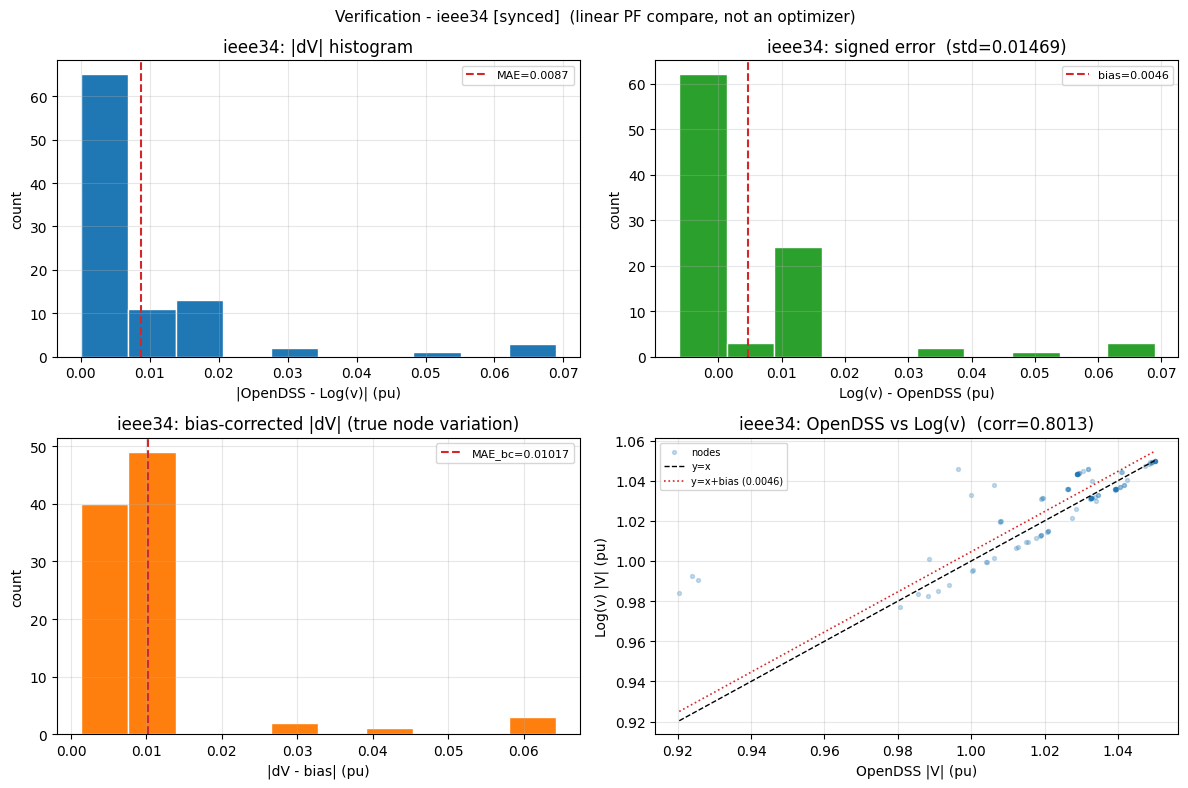

<Figure size 1600x800 with 0 Axes>

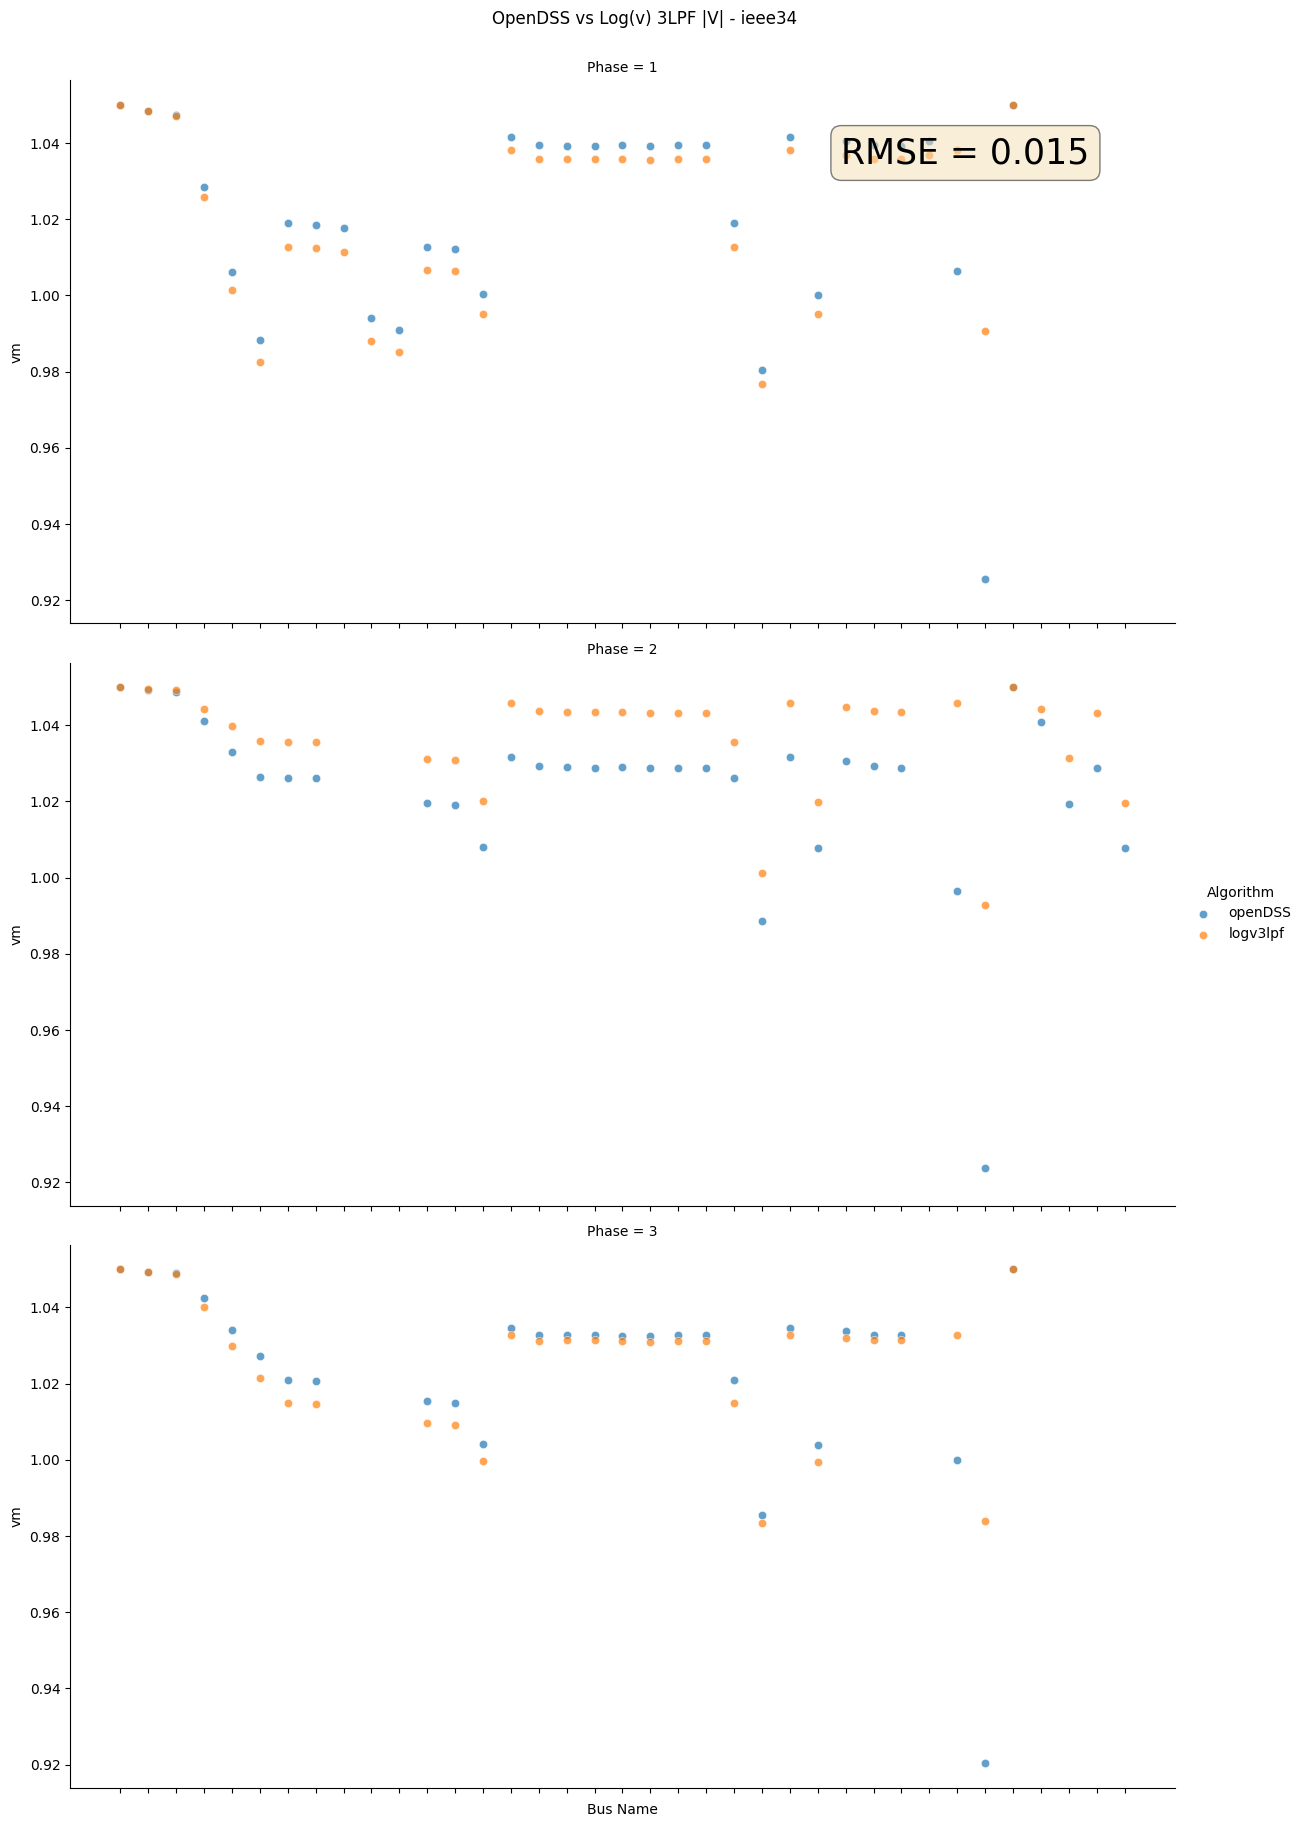

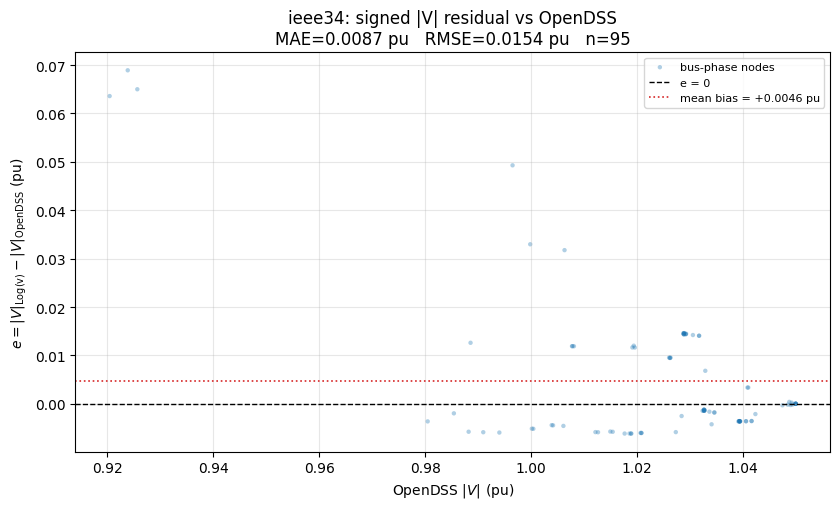

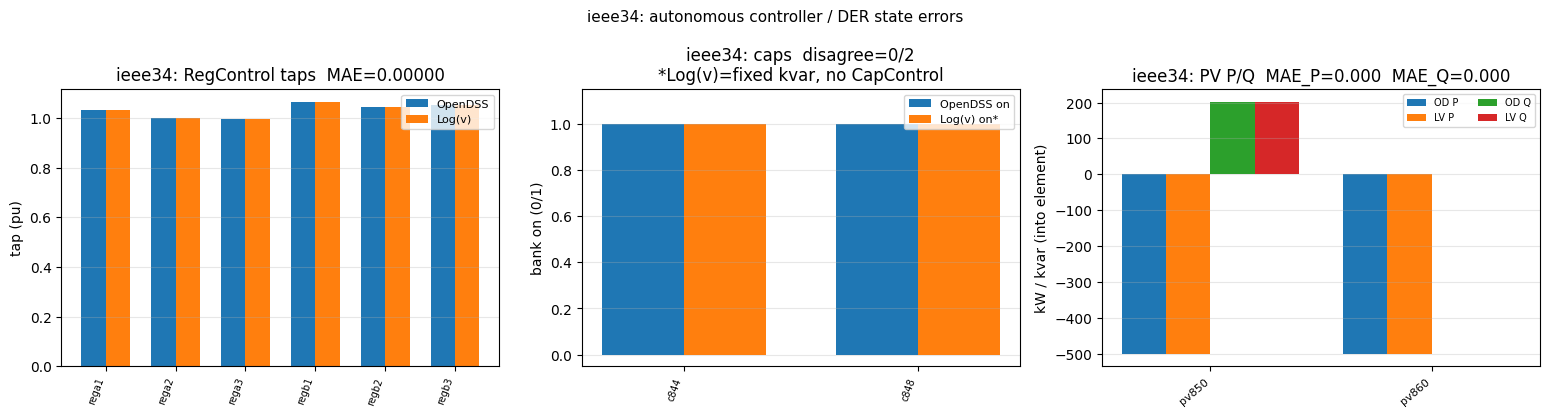

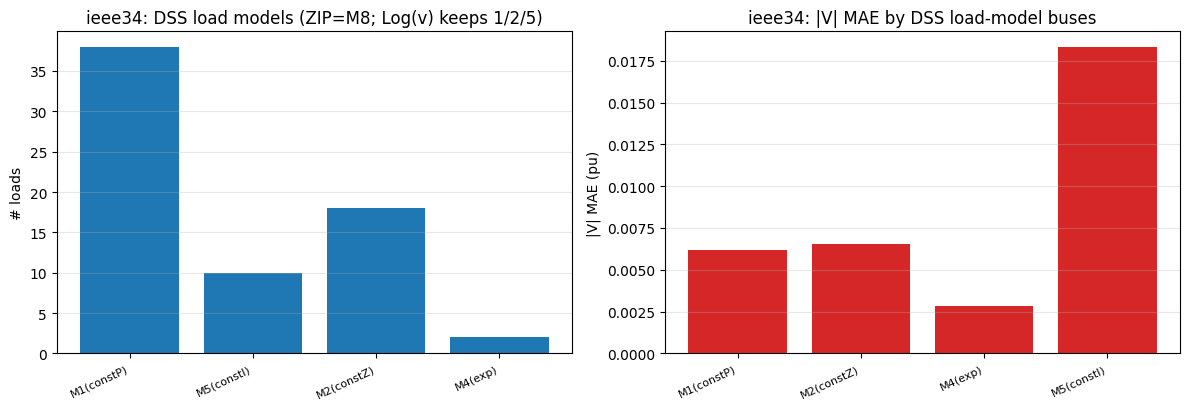


ACCURACY SUMMARY (SNAPSHOT)  feeder=ieee34  mode=synced
  |V| RMSE (pu)  : 0.015409598707416166
  |V| MAPE (%)   : 0.8763302304895875
  angle RMSE deg : 4.185254841177516
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer subxf is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


Nodes =  95
k =  130
Complexity of KLU decomposition, 4.72e+06 FLOPS 
Complexity of LogV algorithm, 1.30e+07 FLOPS 
Ratio 0.36
DAILY OpenDSS vs Log(v)  feeder=ieee34  mode=synced  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  plot nodes: ['890.1', '844.1', '840.1', '814r.1', '852r.1']
  regs: ['reg_rega1_tap_pu', 'reg_rega2_tap_pu', 'reg_rega3_tap_pu', 'reg_regb1_tap_pu', 'reg_regb2_tap_pu', 'reg_regb3_tap_pu']
  caps: ['c844', 'c848']
  load models: M1 constP×36, M2 constZ×20, M4 exp×2, M5 constI×12
  time_speed (FastLogv): True
  OD cold snapshot probe: InitSnap+Solve after metrics (ControlMode=Static; extra probe only — not primary OD metric)
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  fair Fast protocol: bake OD taps into A on change; Fast voltages -> metrics/plots (synced/off)
  profile: native DSS loadshapes -> explicit kW/kvar each step (snapshot); plot distal LV buses (source-end bus 1 i

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "ieee34"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=ieee34  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


AUDIT - what this cell actually ran
  feeder          : ieee34
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Paper Table II FLOPs are inverse-update estimates; wall-clock

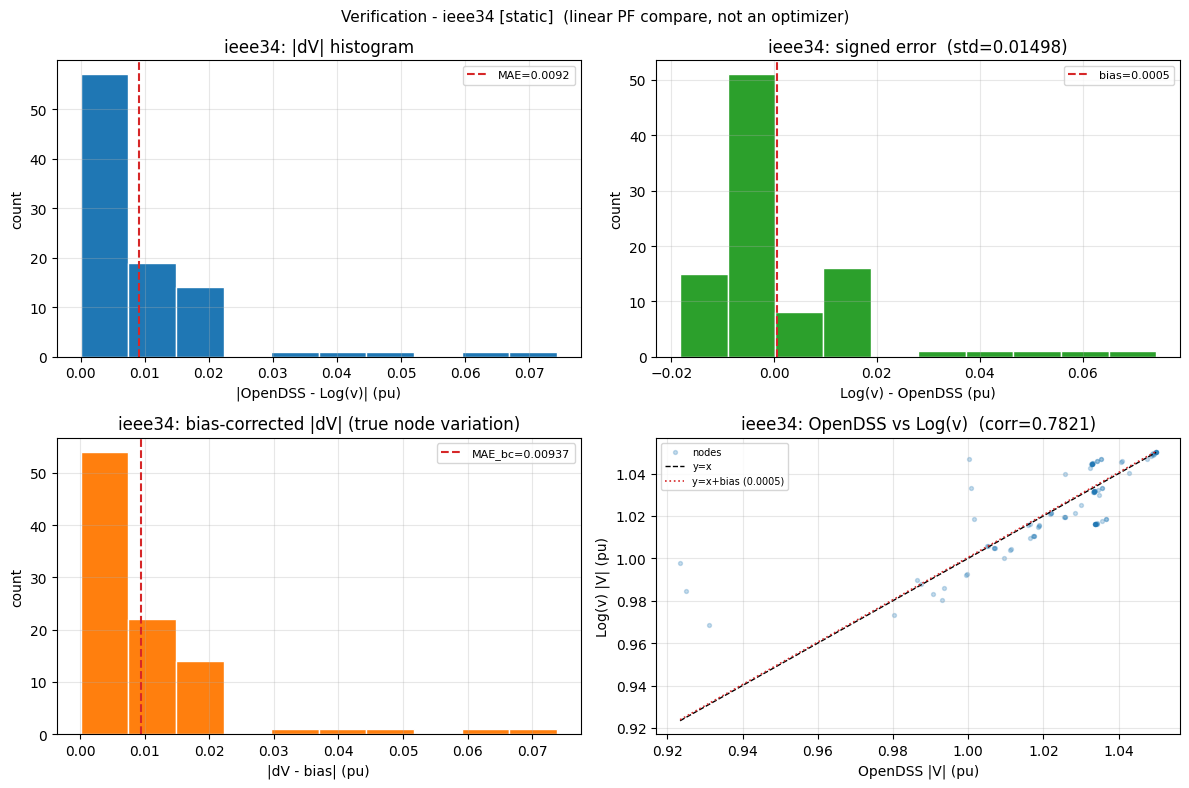

<Figure size 1600x800 with 0 Axes>

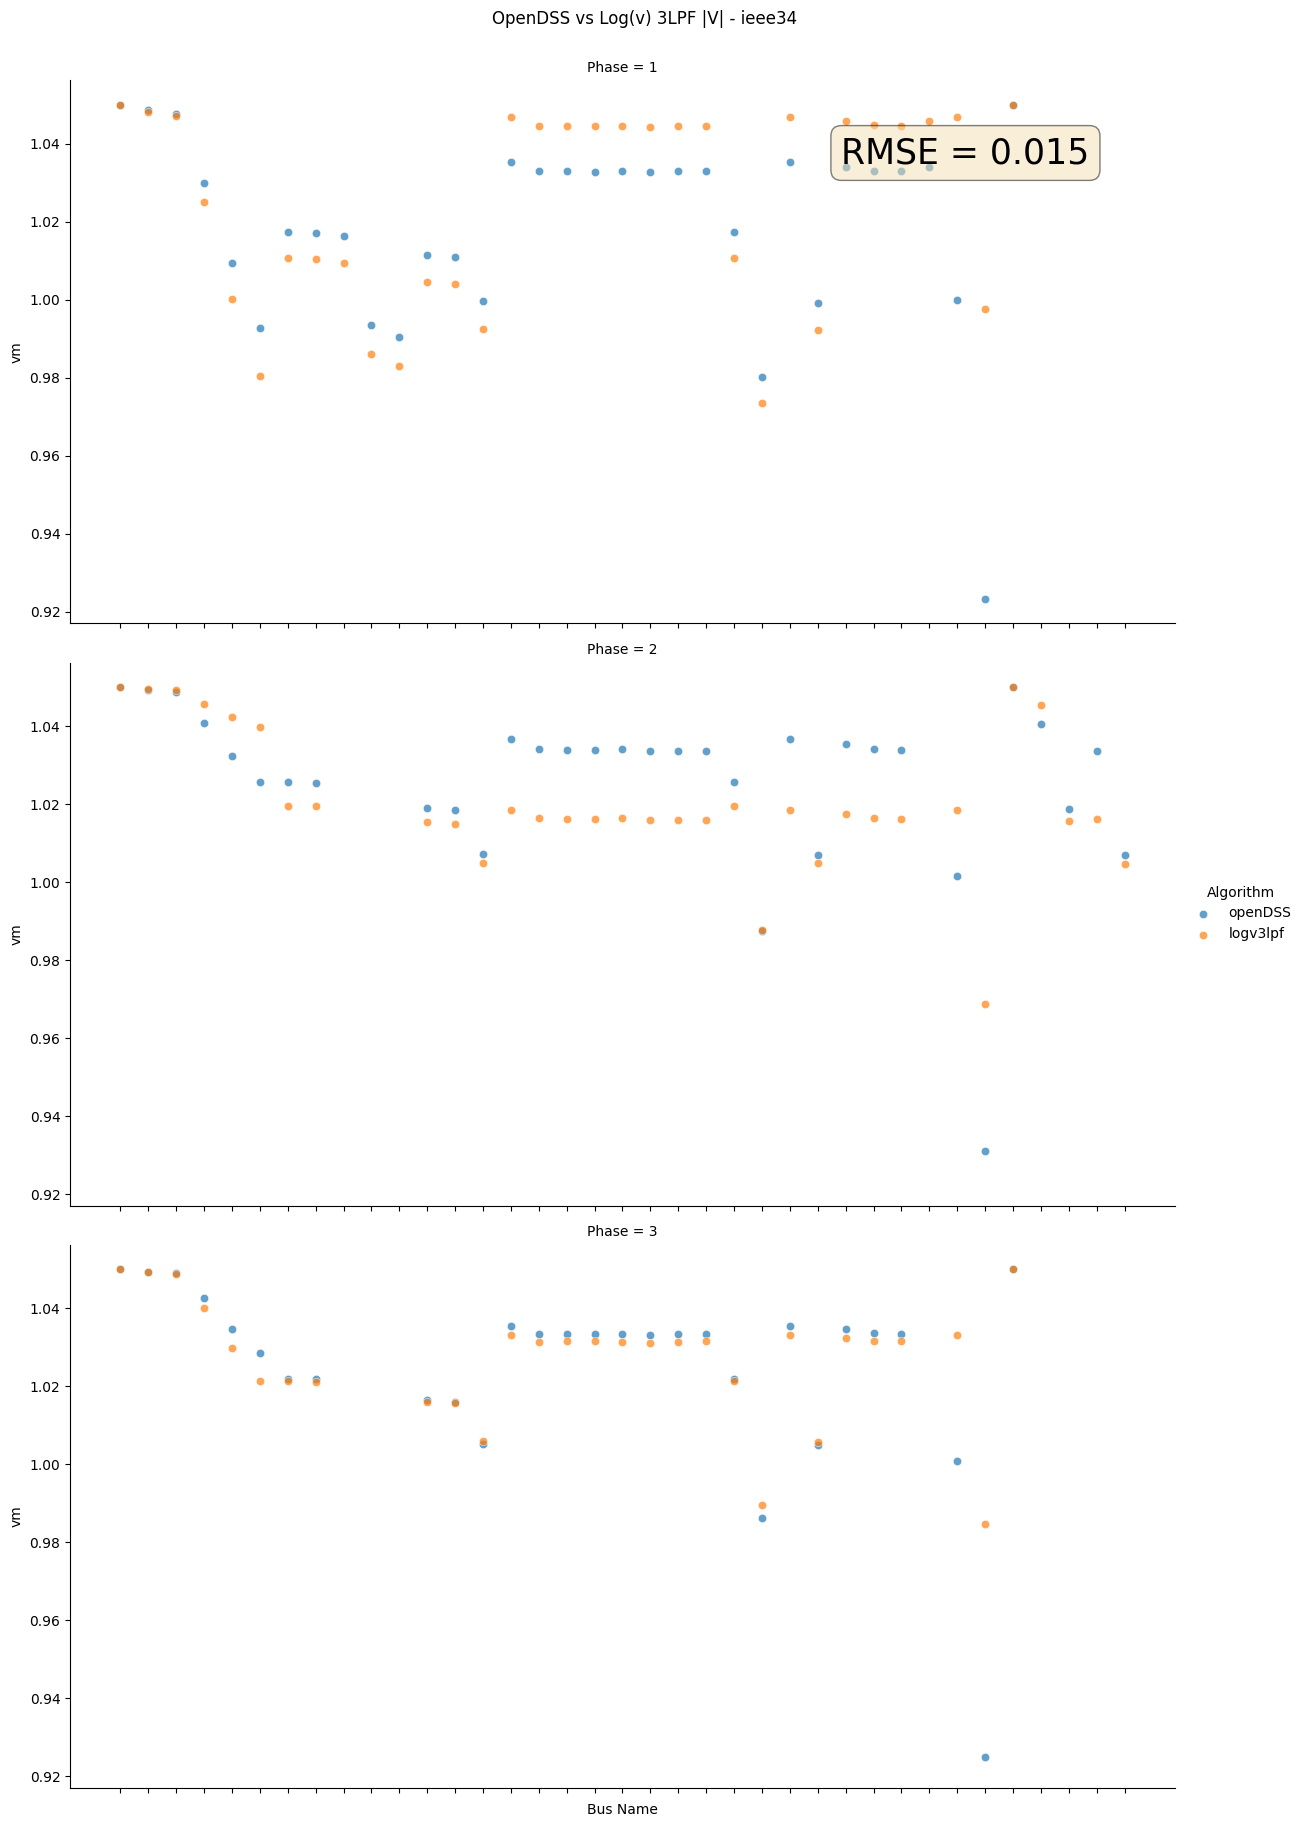

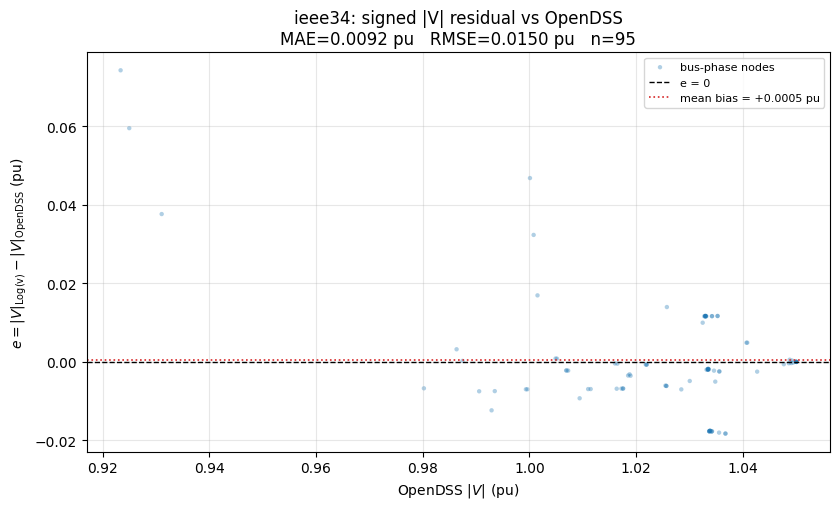

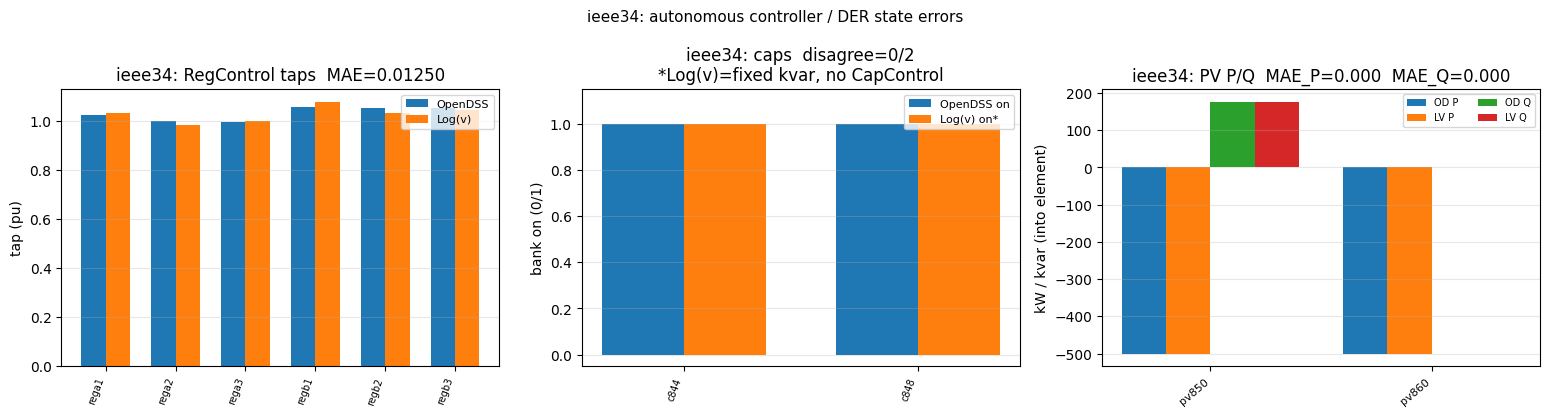

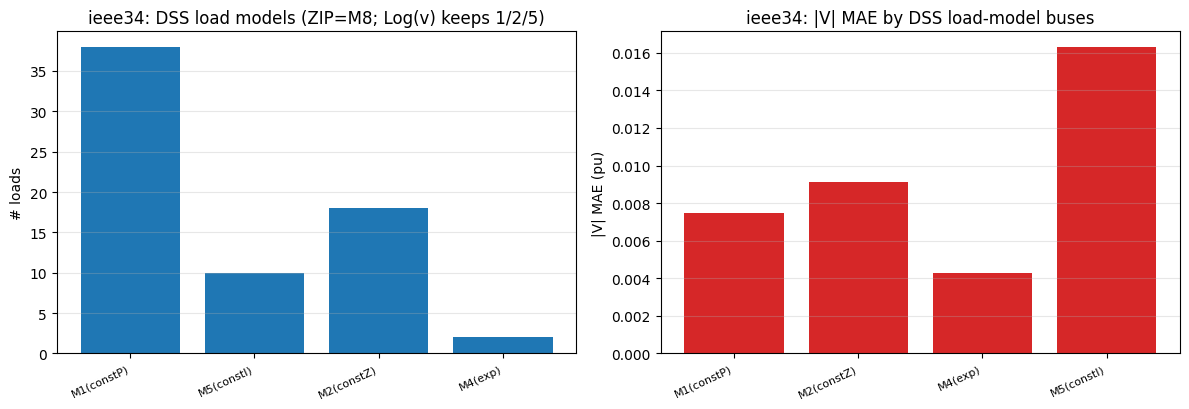


ACCURACY SUMMARY (SNAPSHOT)  feeder=ieee34  mode=static
  |V| RMSE (pu)  : 0.014991073186793465
  |V| MAPE (%)   : 0.9149047285603247
  angle RMSE deg : 3.887646948230946
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer subxf is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  95
k =  130
Complexity of KLU decomposition, 4.72e+06 FLOPS 
Complexity of LogV algorithm, 1.30e+07 FLOPS 
Ratio 0.36
DAILY OpenDSS vs Log(v)  feeder=ieee34  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  plot nodes: ['890.1', '844.1', '840.1', '814r.1', '852r.1']
  regs: ['reg_rega1_tap_pu', 'reg_rega2_tap_pu', 'reg_rega3_tap_pu', 'reg_regb1_tap_pu', 'reg_regb2_tap_pu', 'reg_regb3_tap_pu']
  caps: ['c844', 'c848']
  load models: M1 constP×36, M2 constZ×20, M4 exp×2, M5 constI×12
  time_speed (FastLogv): True
  OD cold snapshot timing: reset taps + InitSnap+Solve ControlMode=Static (controls re-settle from flat start)
  note: static Fast is init-A probe only; plots/metrics use stock autonomous Log(v)
  profile: native DSS loadshapes (Mode=Daily); plot distal LV buses (source-end bus 1 is nearly flat)
  

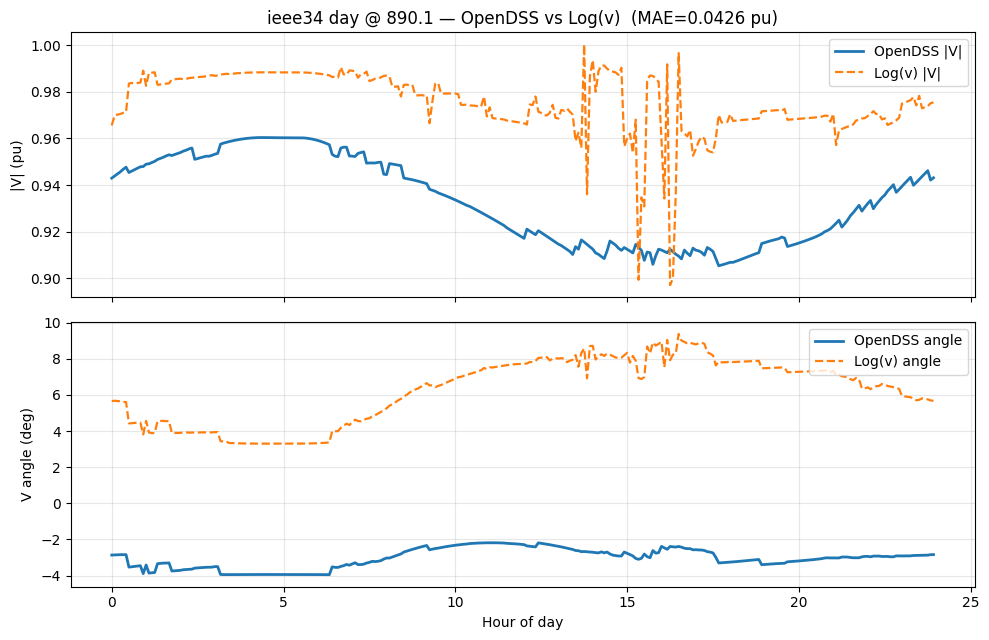

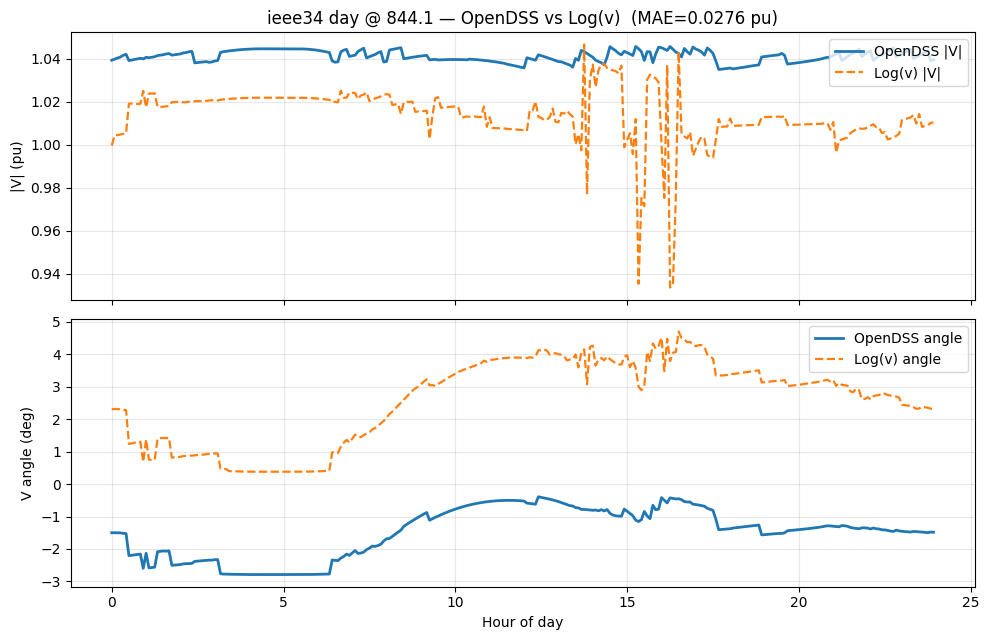

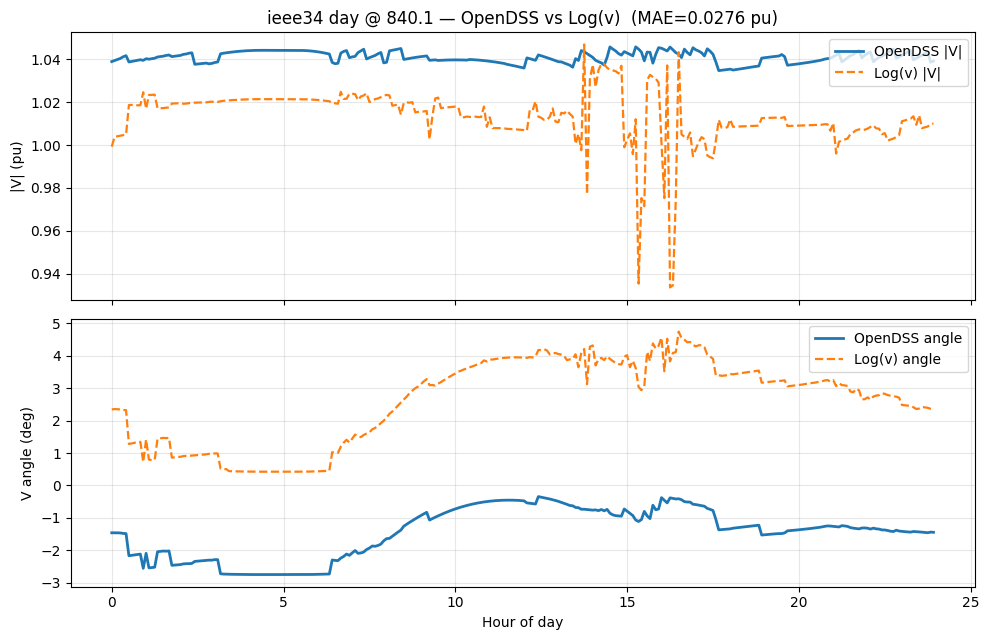

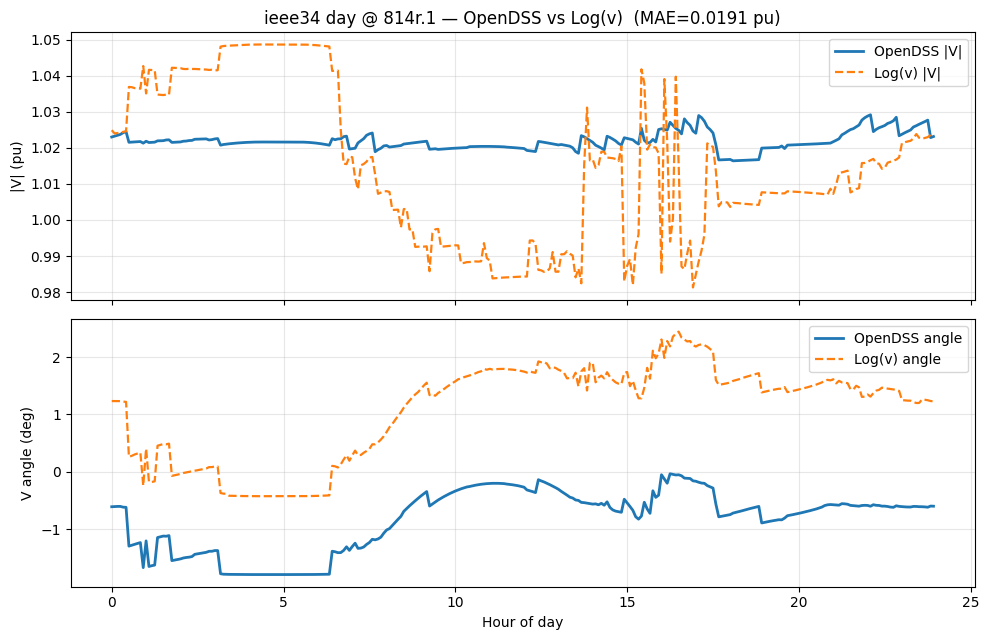

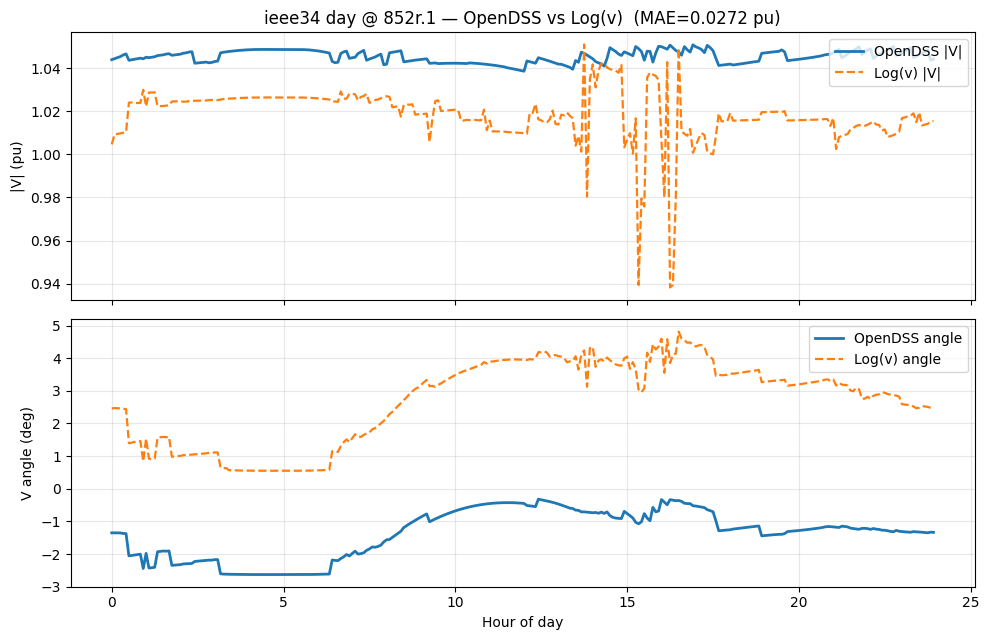

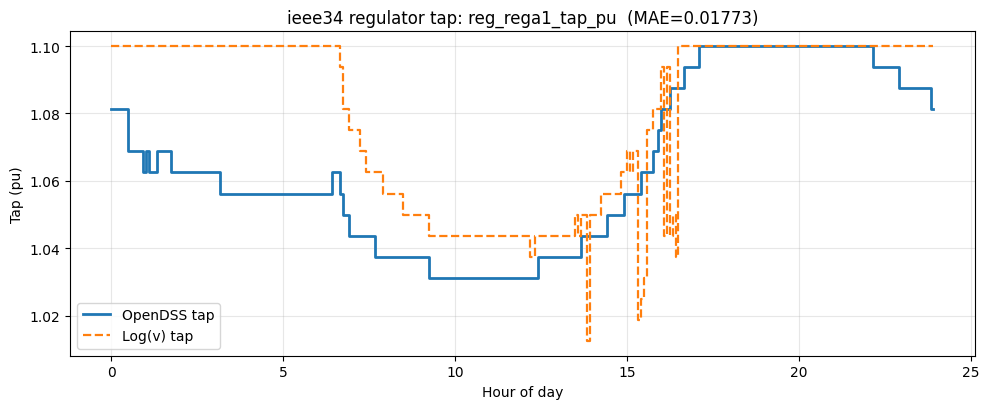

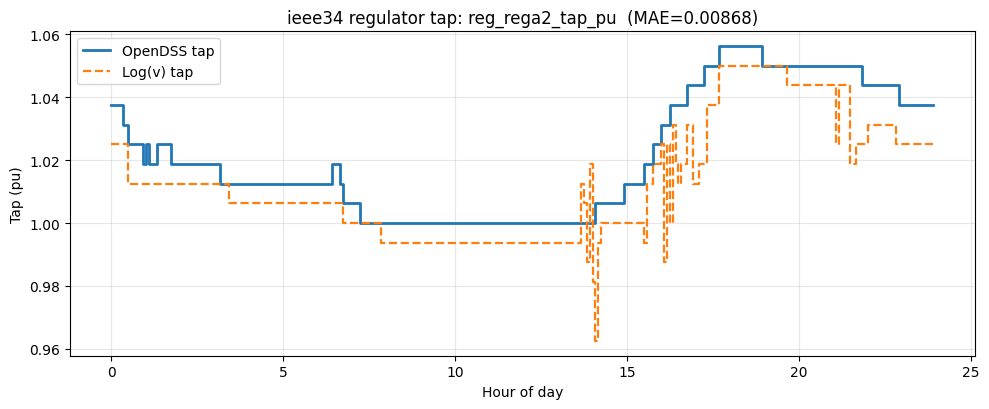

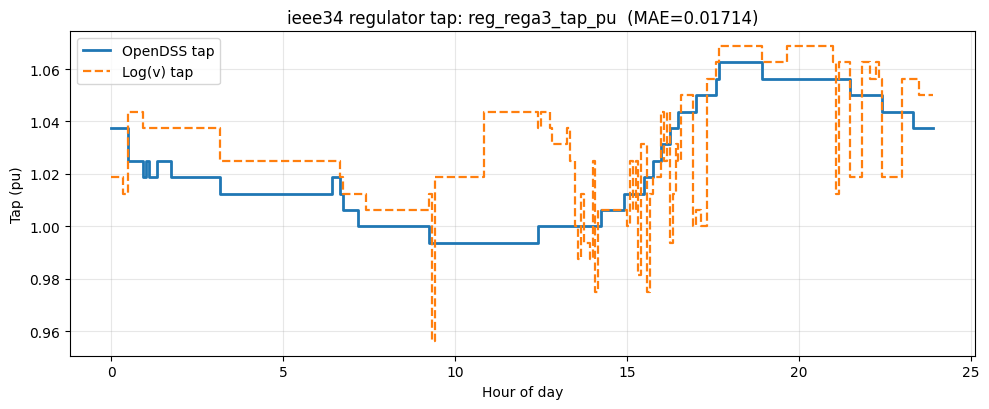

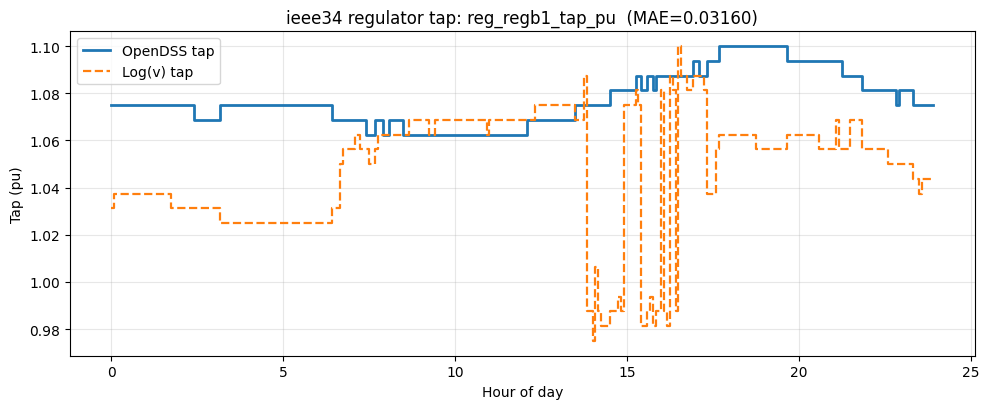

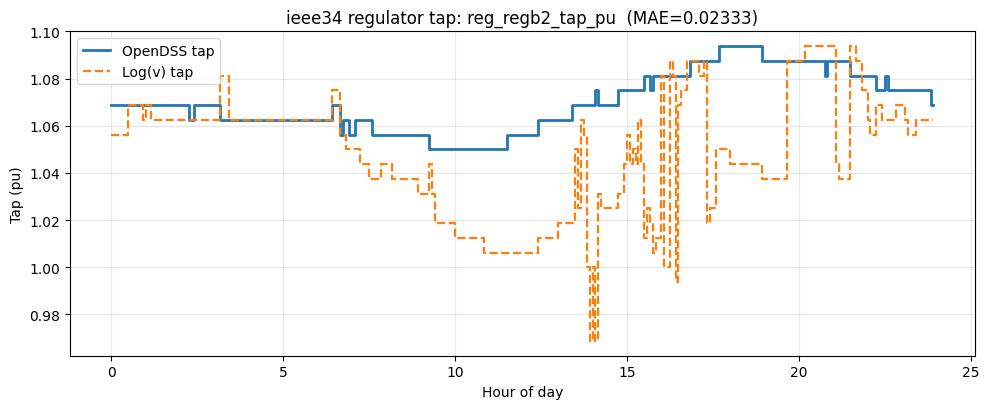

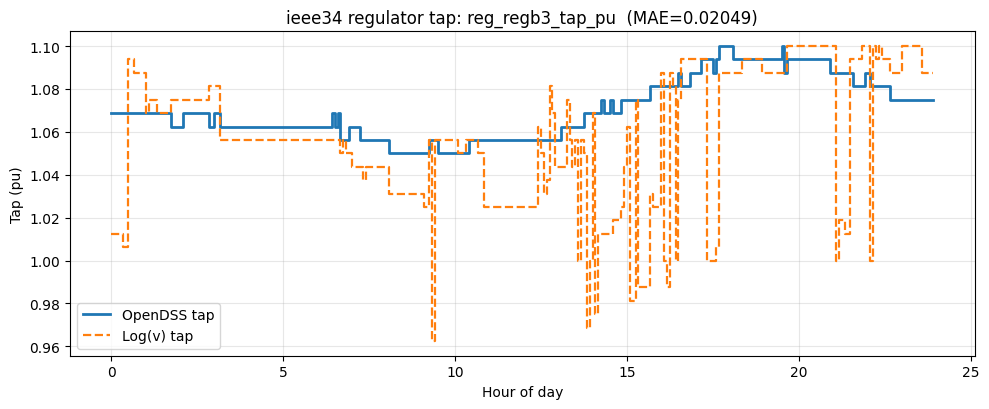

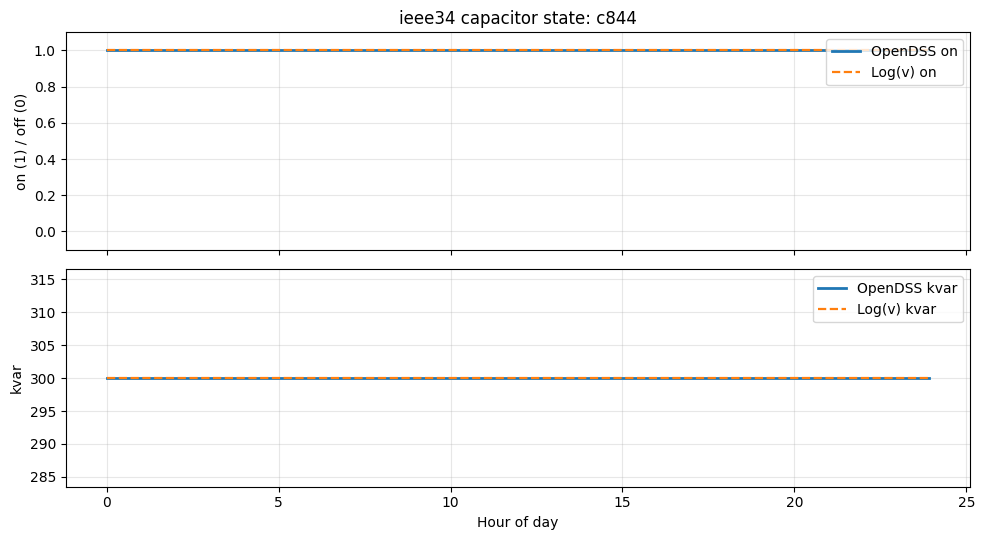

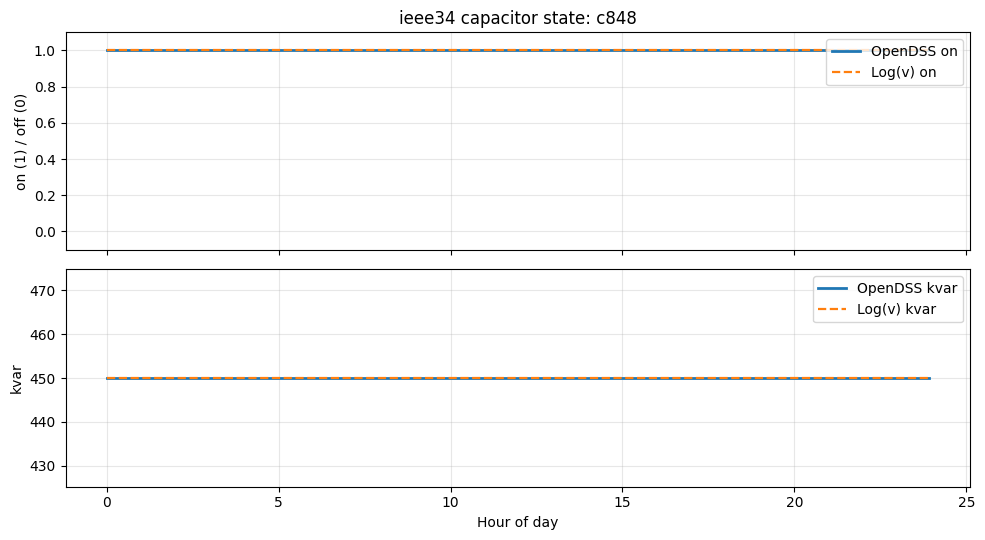

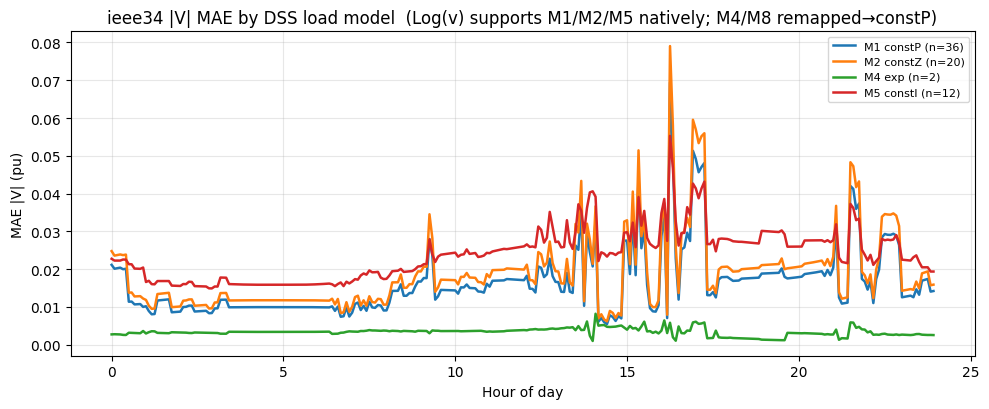

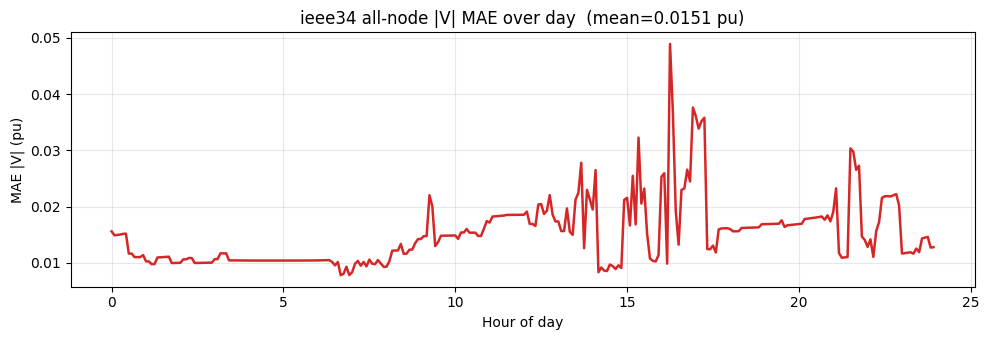

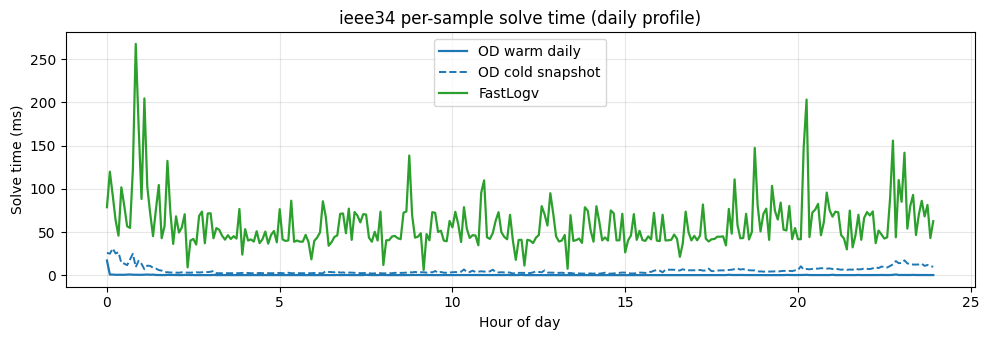


ACCURACY SUMMARY (DAILY)  feeder=ieee34  mode=static
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.015095 pu
  mean |V| RMSE  : 0.020990 pu
  max  |V| MAE   : 0.048937 pu
  wall           : 1552.3 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_ieee34_mode_static_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=ieee34   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : stock  fair_fast=False
  A rebuilds      : 0
  |V| MAE mean    : 0.015095 pu  (median 0.014391, max 0.048937)
  OD warm mean    : 0.277 ms  (median 0.169)
  OD cold mean    : 5.349 ms  (median 3.674)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 5294.889 ms
  FastLogv mean   : 58.973 ms  (median 47.845)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  mean OD_warm/Fast: 0.00x
  mean OD_cold/Fast: 0.09x  <--- fair cold compare
  note: static probe — Fast 

(<logv3lpf.run_case.case at 0x27c0667d110>,
 {'mae': 0.009175370604878014,
  'rmse': 0.014991073186793465,
  'max': 0.07432466620158151,
  'n': 95,
  'control_mode': 'static',
  'n_reg': 6,
  'reg_iters': 2,
  'tap_mae': 0.012500000000000048,
  'paper_accuracy': {'n_phase_nodes': 95,
   'vm_rmse_pu': 0.014991073186793465,
   'vm_mape_pct': 0.9149047285603247,
   'vm_mae_pu': 0.009175370604878014,
   'va_rmse_deg': 3.887646948230946,
   'va_rmse_deg_global_aligned': 2.081705576893908,
   'va_source_offset_deg': -0.00019490872228781578,
   'vsource_angle_deg': 30.0},
  'paper_flops': {'n_bus_phases': 95.0,
   'n_excl_source': 92.0,
   'n_source_phases': 3.0,
   'n_sys': 190.0,
   'k': 130.0,
   'k_load_phases': 47.0,
   'k_cap_phases': 6.0,
   'k_reg_phases': 12.0,
   'k_reg_primary_phases': 6.0,
   'k_woodbury_U': 106.0,
   'n_regulators': 6.0,
   'opendss_lu_flops': 4717066.0,
   'opendss_lu_flops_excl_source': 4288426.0,
   'logv_woodbury_update_flops': 13049230.0,
   'logv_apply_flop

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "ieee34"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=906  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load model

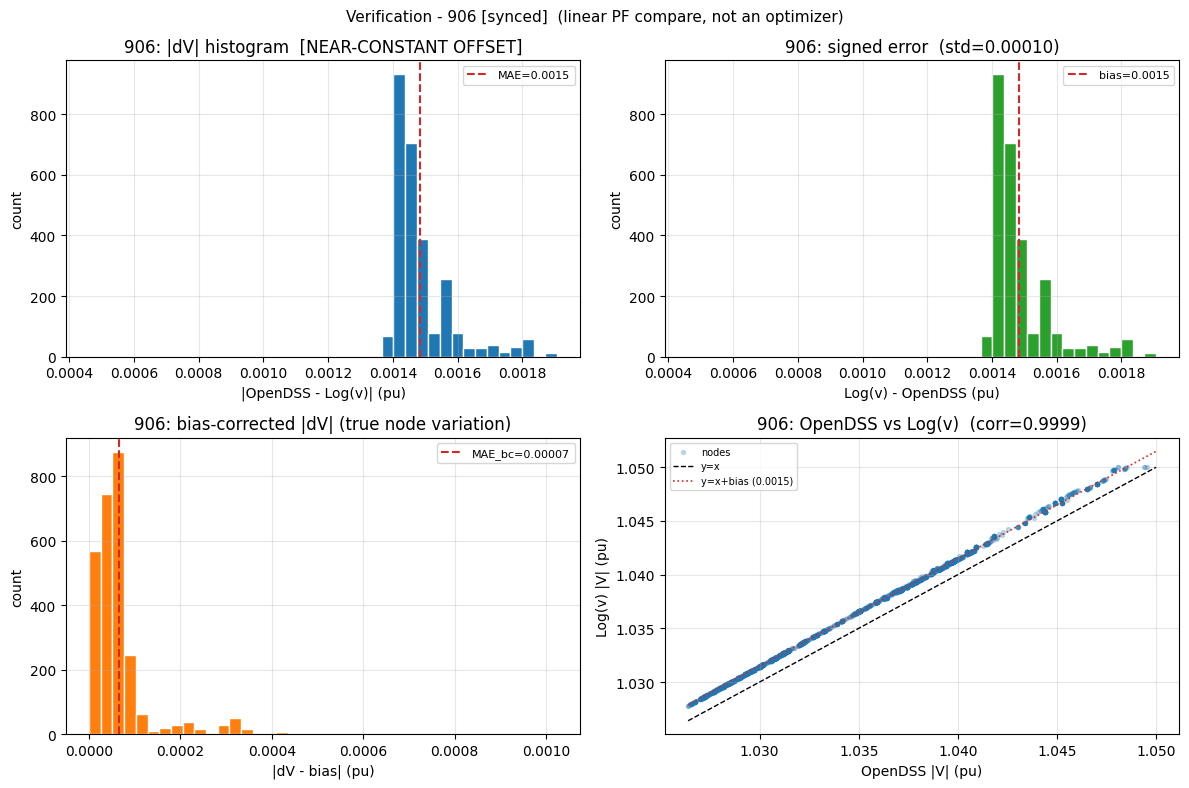

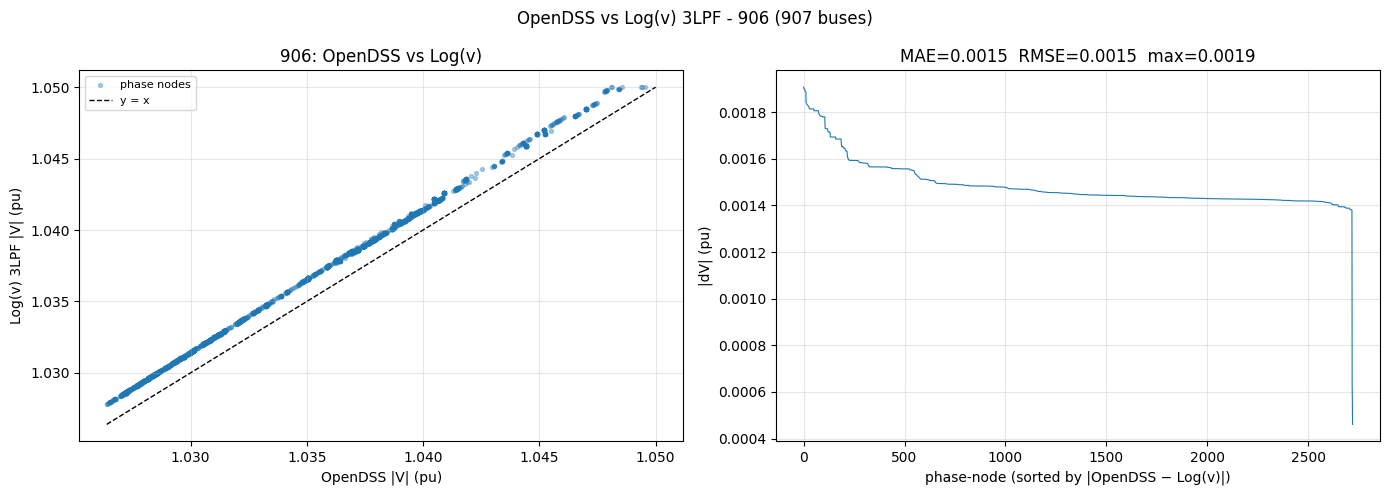

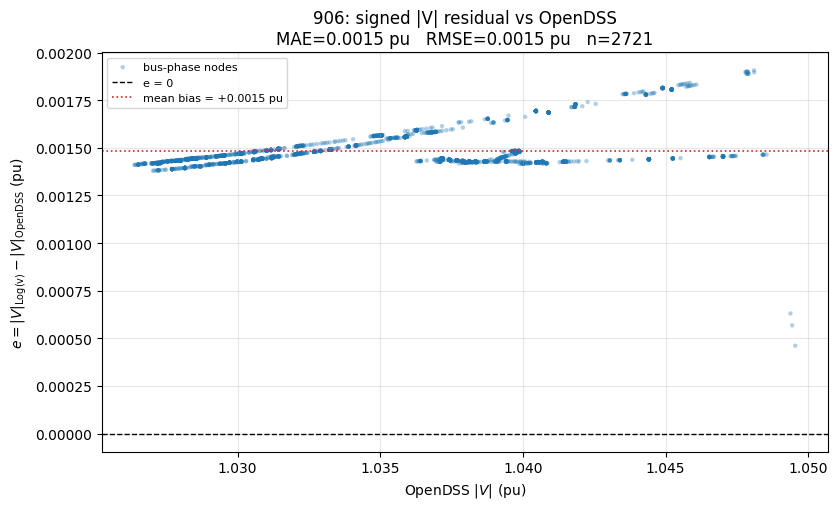


ACCURACY SUMMARY (SNAPSHOT)  feeder=906  mode=synced
  |V| RMSE (pu)  : 0.0014882088706001388
  |V| MAPE (%)   : 0.14345725286626854
  angle RMSE deg : 0.20104696817184936
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
DAILY OpenDSS vs Log(v)  feeder=906  mode=synced  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  plot nodes: ['817.1', '860.1', '896.1', '906.1']
  regs: (none)
  caps: (none)
  load models: M1 constP×55
  time_speed (FastLogv): True

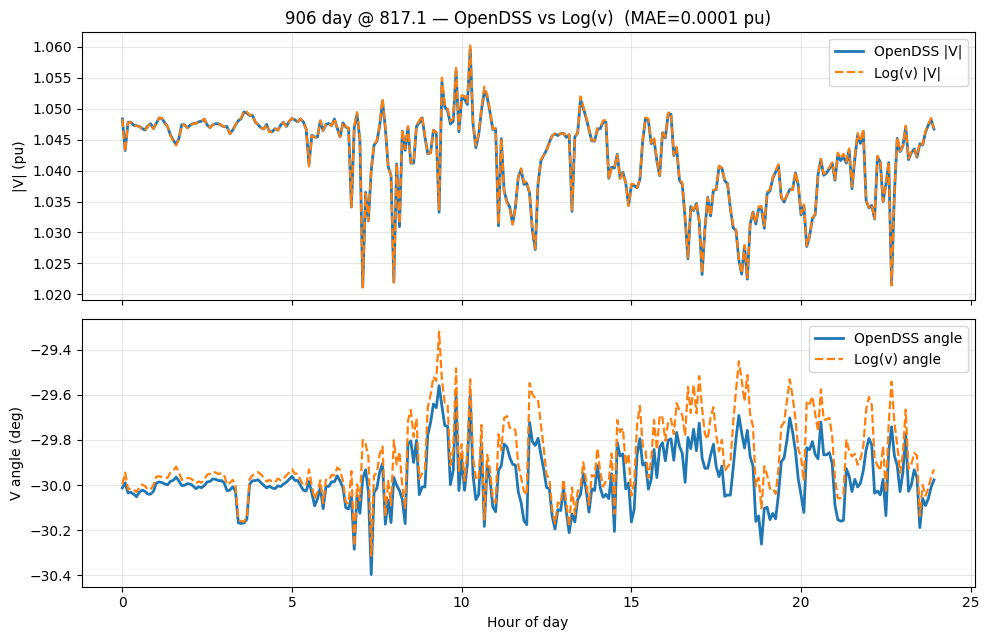

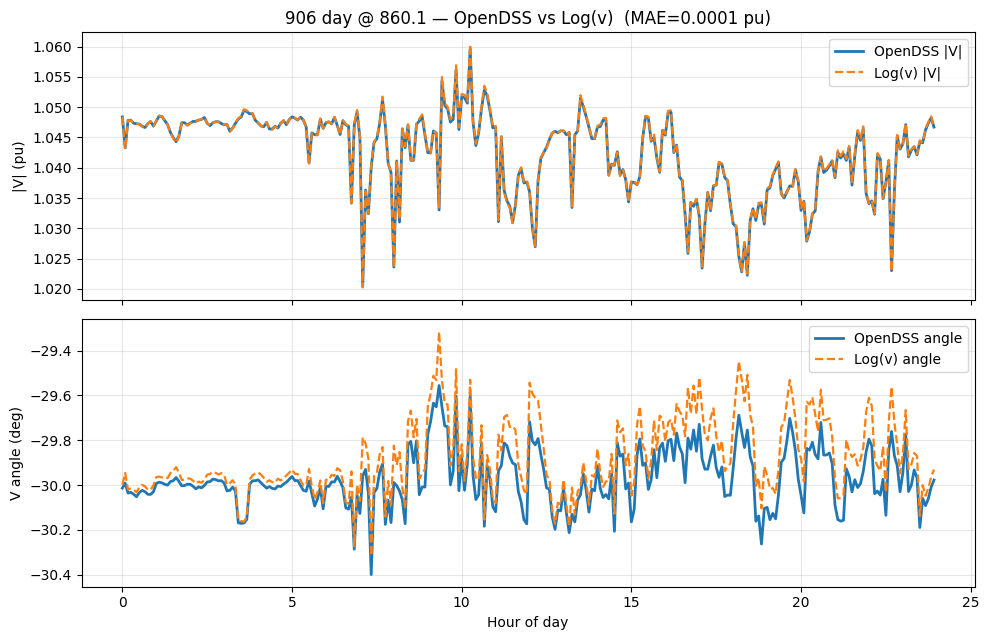

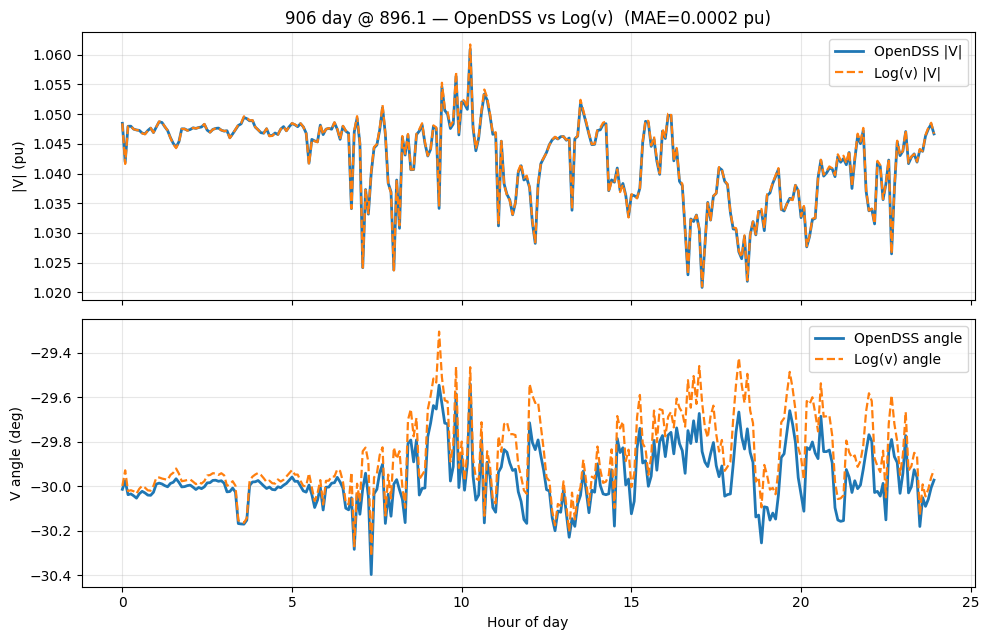

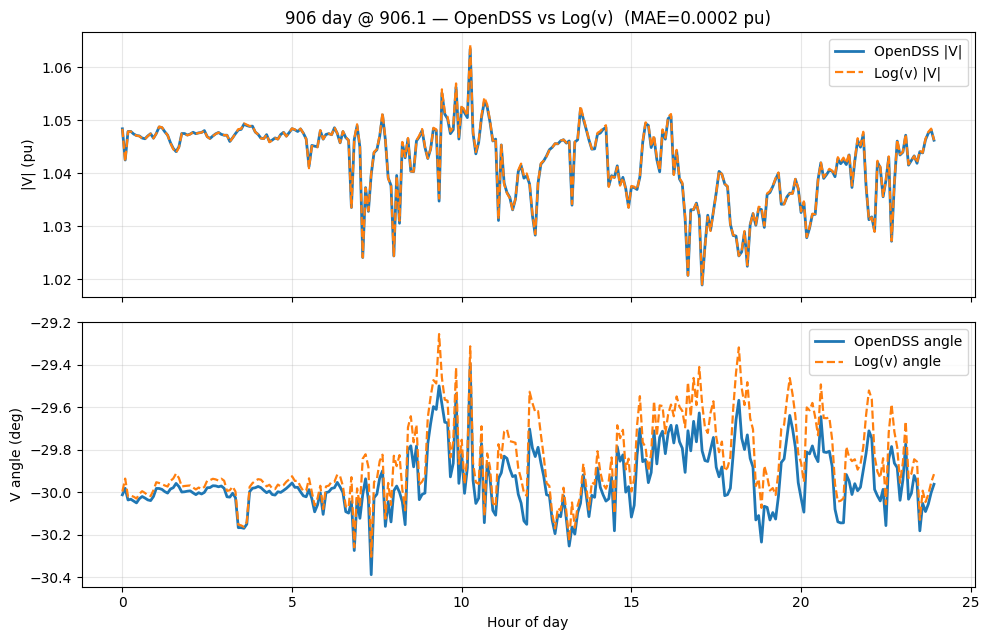

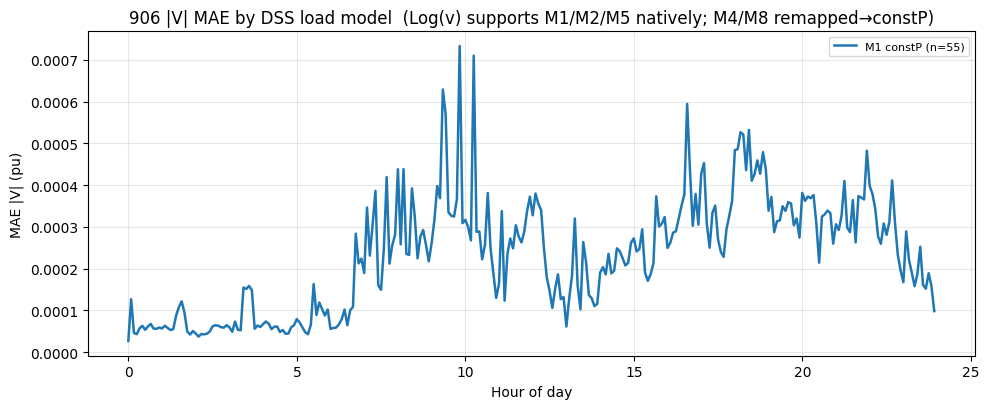

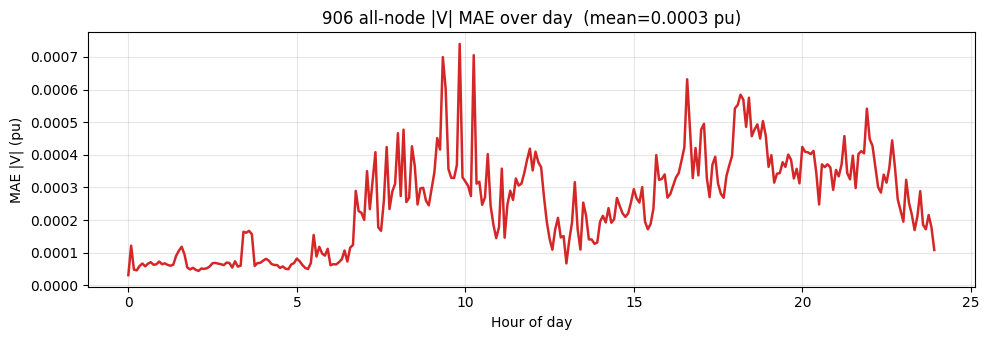

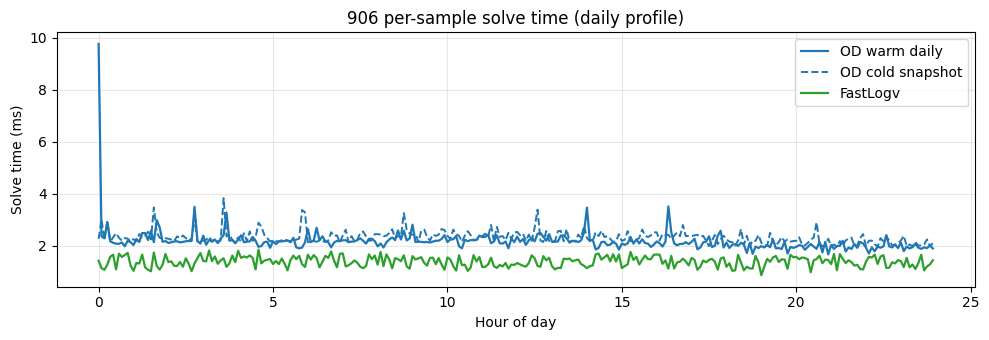


ACCURACY SUMMARY (DAILY)  feeder=906  mode=synced
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.000252 pu
  mean |V| RMSE  : 0.000291 pu
  max  |V| MAE   : 0.000740 pu
  wall           : 44.1 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_906_mode_synced_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=906   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : fast  fair_fast=True
  A rebuilds      : 1
  |V| MAE mean    : 0.000252 pu  (median 0.000257, max 0.000740)
  OD warm mean    : 2.181 ms  (median 2.143)
  OD cold mean    : 2.323 ms  (median 2.271)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 46.786 ms
  FastLogv mean   : 1.389 ms  (median 1.400)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  Fast refresh mean: 197.084 ms  (n=1; outside Fast timer)
  mean OD_warm/Fast: 1.57x
  mean OD_cold/Fast: 1.67x  <--- fair

(<logv3lpf.run_case.case at 0x27c51e39250>,
 {'mae': 0.0014849760382257301,
  'rmse': 0.0014882088706001388,
  'max': 0.0019070265757819005,
  'n': 2721,
  'control_mode': 'synced',
  'n_reg': 0,
  'reg_iters': 0,
  'tap_mae': nan,
  'paper_accuracy': {'n_phase_nodes': 2721,
   'vm_rmse_pu': 0.0014882088706001388,
   'vm_mape_pct': 0.14345725286626854,
   'vm_mae_pu': 0.0014849760382257301,
   'va_rmse_deg': 0.20104696817184936,
   'va_rmse_deg_global_aligned': 0.028450004077618506,
   'va_source_offset_deg': -0.04777777317052786,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 2721.0,
   'n_excl_source': 2718.0,
   'n_source_phases': 3.0,
   'n_sys': 5442.0,
   'k': 0.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 0.0,
   'k_reg_phases': 0.0,
   'k_reg_primary_phases': 0.0,
   'k_woodbury_U': 0.0,
   'n_regulators': 0.0,
   'opendss_lu_flops': 107563002048.0,
   'opendss_lu_flops_excl_source': 107207748288.0,
   'logv_woodbury_update_flops': 0.0,
   'logv_apply_flops_l

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "906"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=906  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Pap

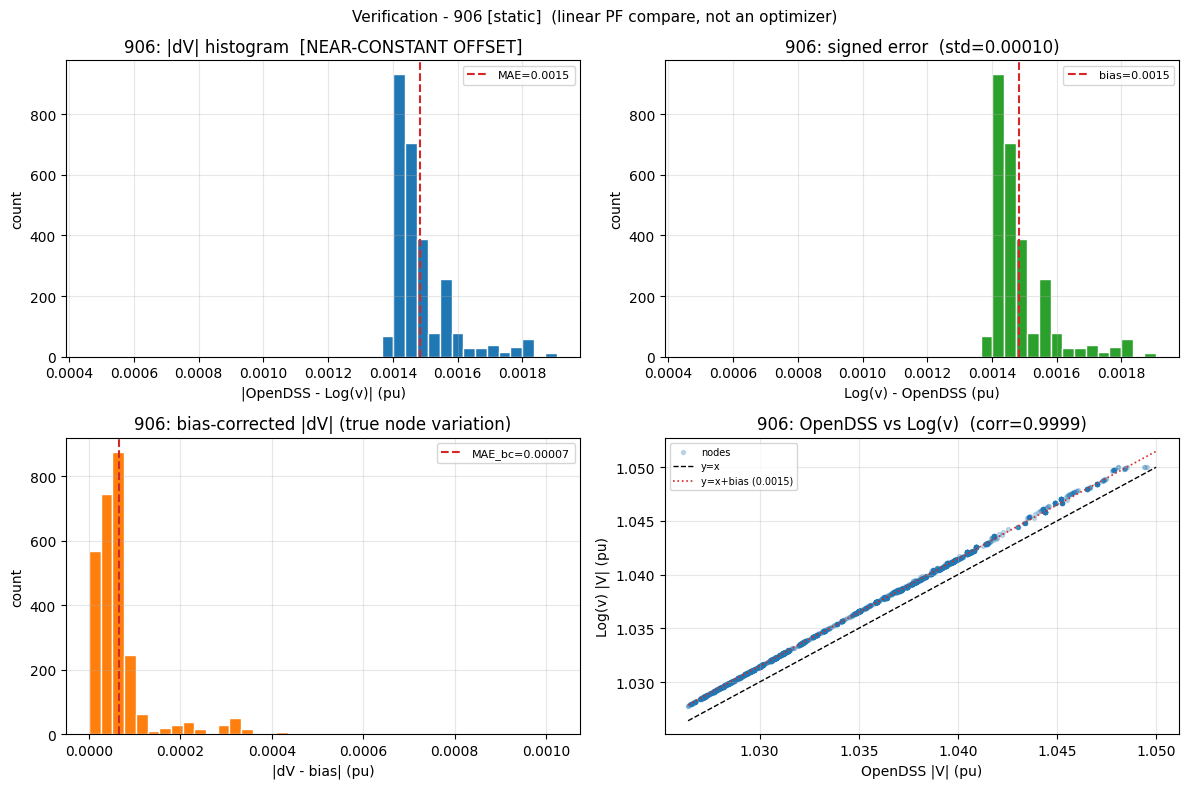

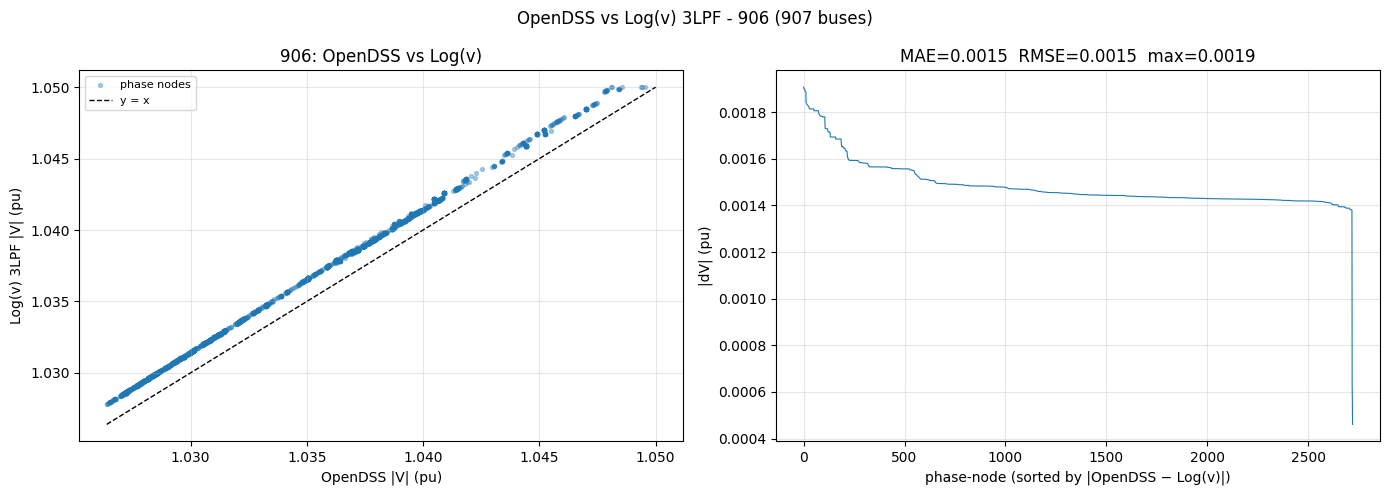

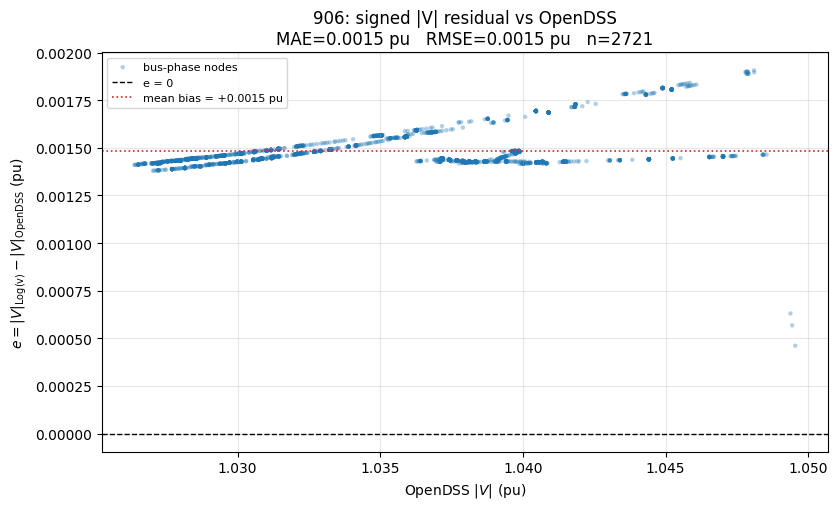


ACCURACY SUMMARY (SNAPSHOT)  feeder=906  mode=static
  |V| RMSE (pu)  : 0.0014882088706001388
  |V| MAPE (%)   : 0.14345725286626854
  angle RMSE deg : 0.20104696817184936
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
DAILY OpenDSS vs Log(v)  feeder=906  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  plot nodes: ['817.1', '860.1', '896.1', '906.1']
  regs: (none)
  caps: (none)
  load models: M1 constP×55
  time_speed (FastLogv): True

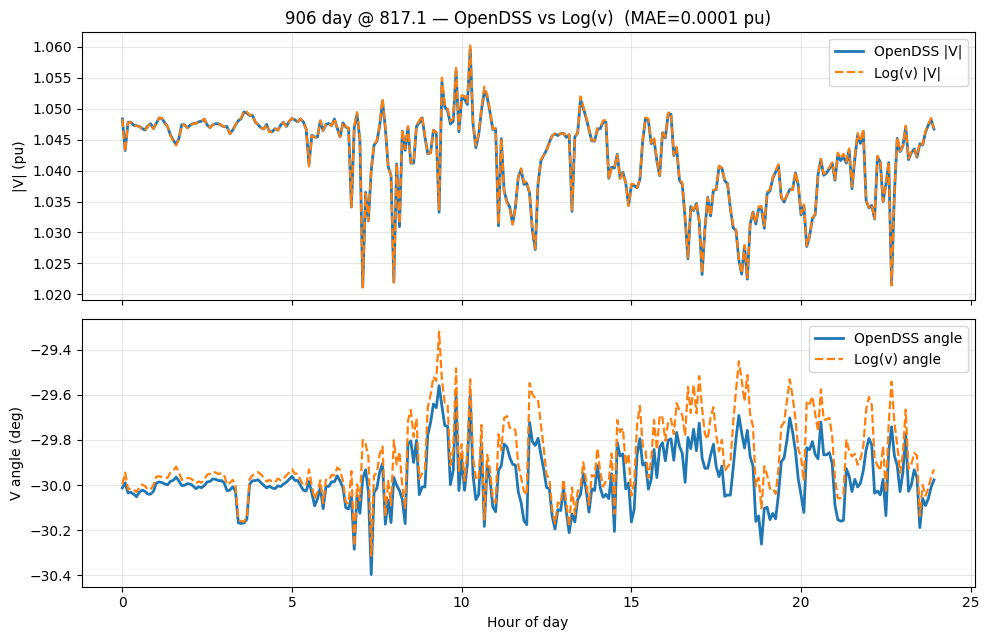

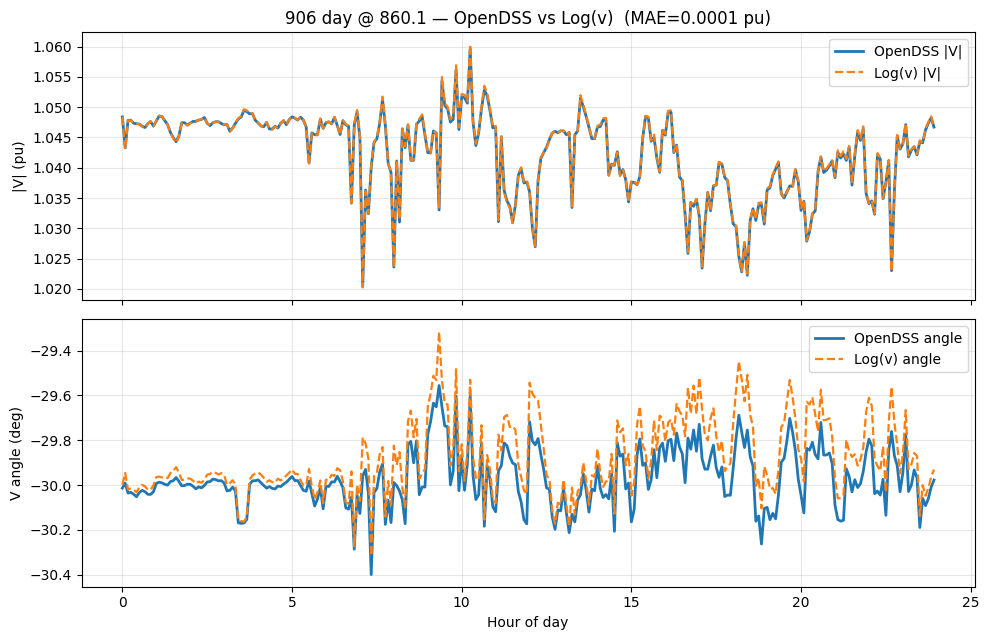

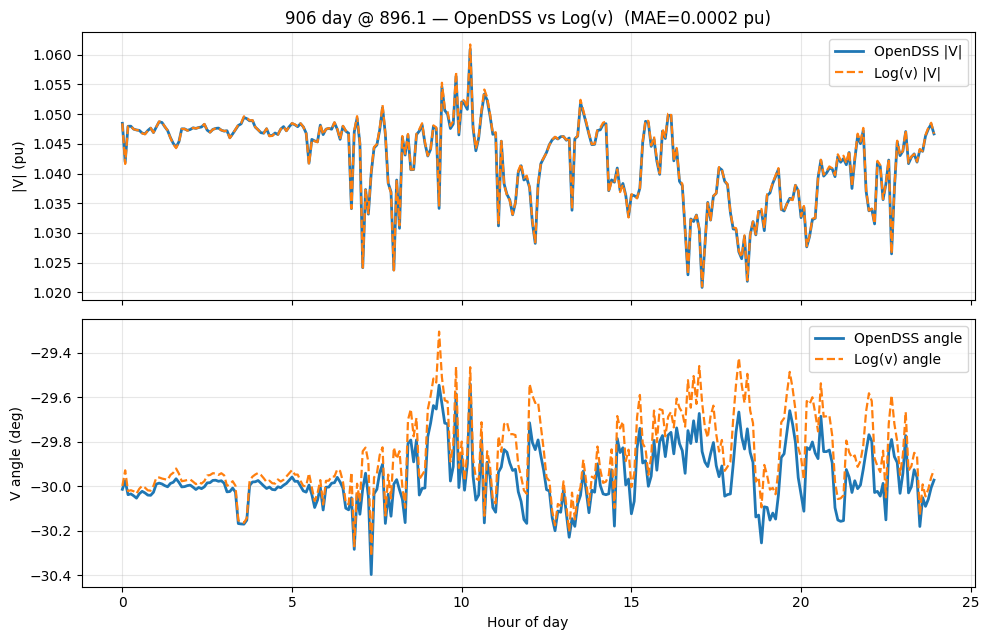

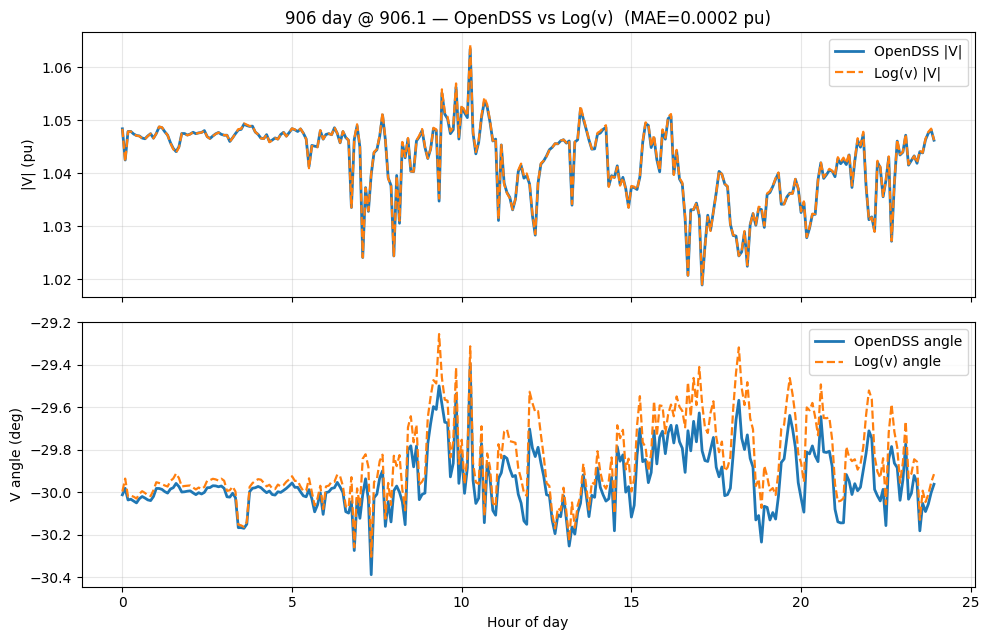

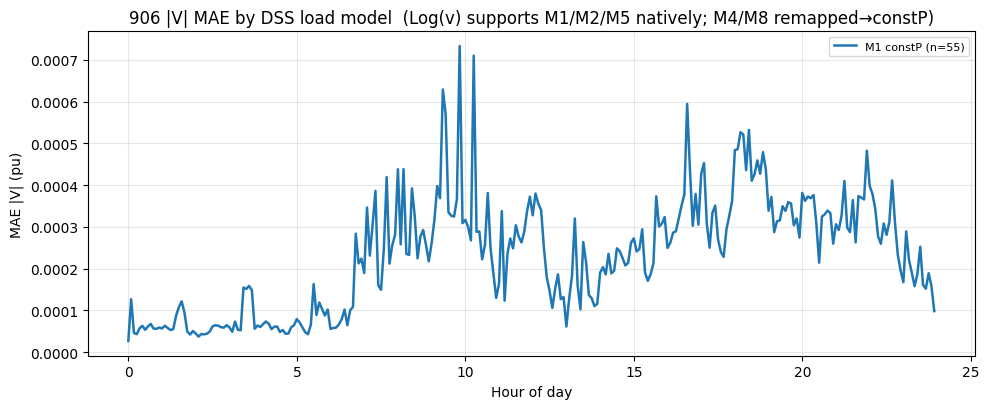

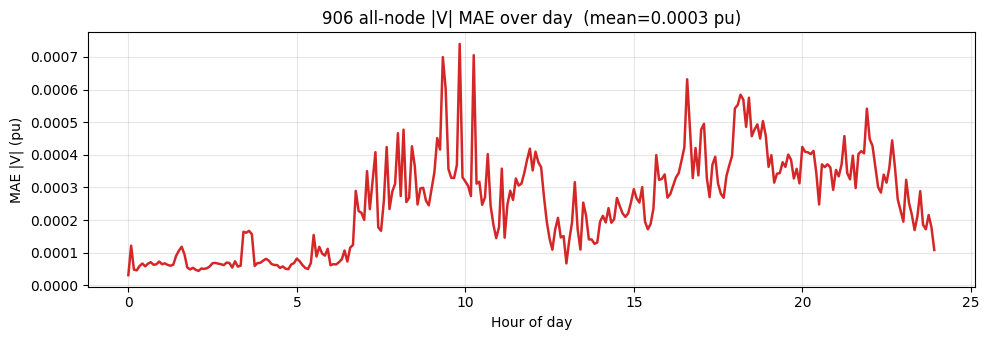

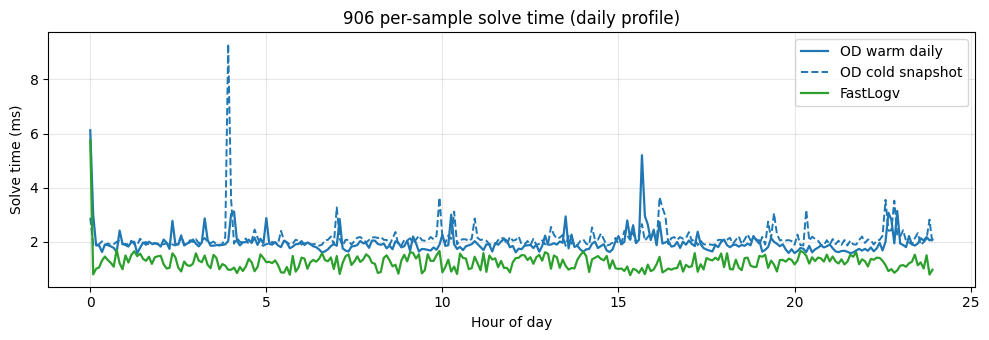


ACCURACY SUMMARY (DAILY)  feeder=906  mode=static
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.000252 pu
  mean |V| RMSE  : 0.000291 pu
  max  |V| MAE   : 0.000740 pu
  wall           : 31.1 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_906_mode_static_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=906   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : stock  fair_fast=False
  A rebuilds      : 0
  |V| MAE mean    : 0.000252 pu  (median 0.000257, max 0.000740)
  OD warm mean    : 1.961 ms  (median 1.888)
  OD cold mean    : 2.127 ms  (median 2.046)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 42.746 ms
  FastLogv mean   : 1.249 ms  (median 1.265)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  mean OD_warm/Fast: 1.57x
  mean OD_cold/Fast: 1.70x  <--- fair cold compare
  note: static probe — Fast uses init A; pl

(<logv3lpf.run_case.case at 0x27c55b64550>,
 {'mae': 0.0014849760382257301,
  'rmse': 0.0014882088706001388,
  'max': 0.0019070265757819005,
  'n': 2721,
  'control_mode': 'static',
  'n_reg': 0,
  'reg_iters': 0,
  'tap_mae': nan,
  'paper_accuracy': {'n_phase_nodes': 2721,
   'vm_rmse_pu': 0.0014882088706001388,
   'vm_mape_pct': 0.14345725286626854,
   'vm_mae_pu': 0.0014849760382257301,
   'va_rmse_deg': 0.20104696817184936,
   'va_rmse_deg_global_aligned': 0.028450004077618506,
   'va_source_offset_deg': -0.04777777317052786,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 2721.0,
   'n_excl_source': 2718.0,
   'n_source_phases': 3.0,
   'n_sys': 5442.0,
   'k': 0.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 0.0,
   'k_reg_phases': 0.0,
   'k_reg_primary_phases': 0.0,
   'k_woodbury_U': 0.0,
   'n_regulators': 0.0,
   'opendss_lu_flops': 107563002048.0,
   'opendss_lu_flops_excl_source': 107207748288.0,
   'logv_woodbury_update_flops': 0.0,
   'logv_apply_flops_l

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "906"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=8500  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=24  STEP_MIN=60.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 8500
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
 

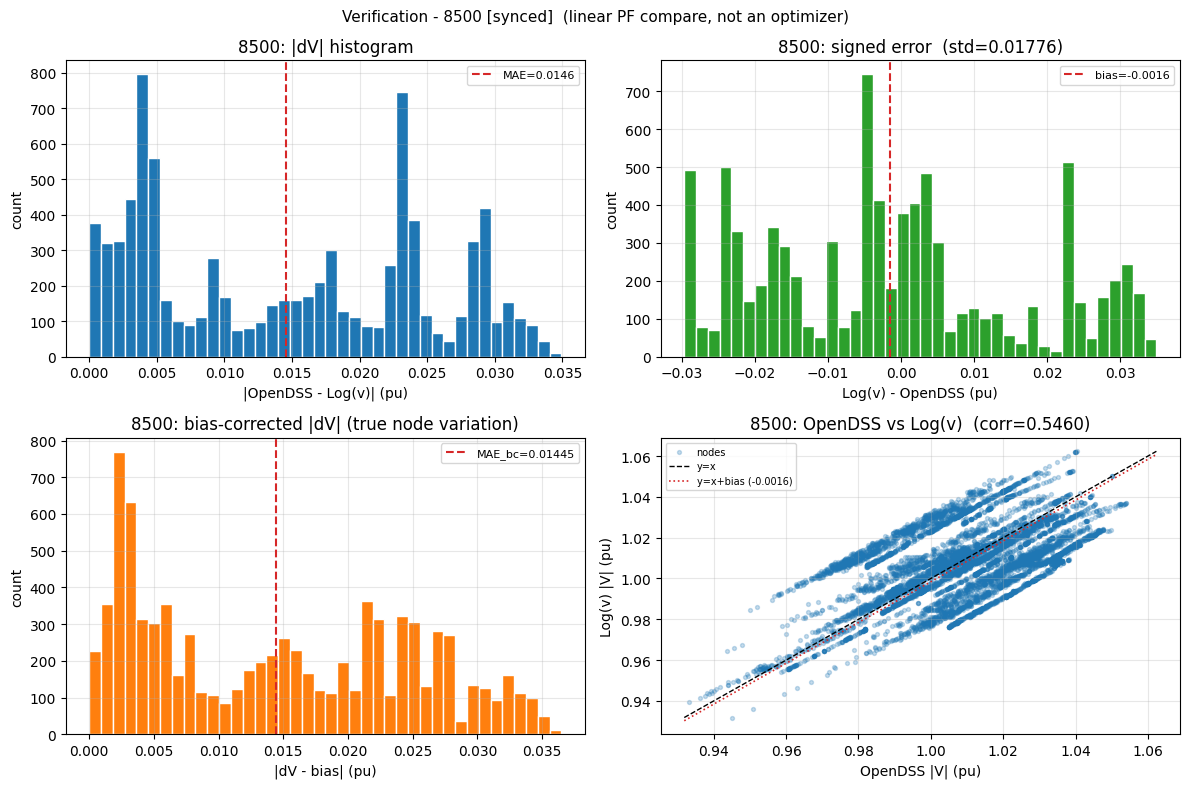

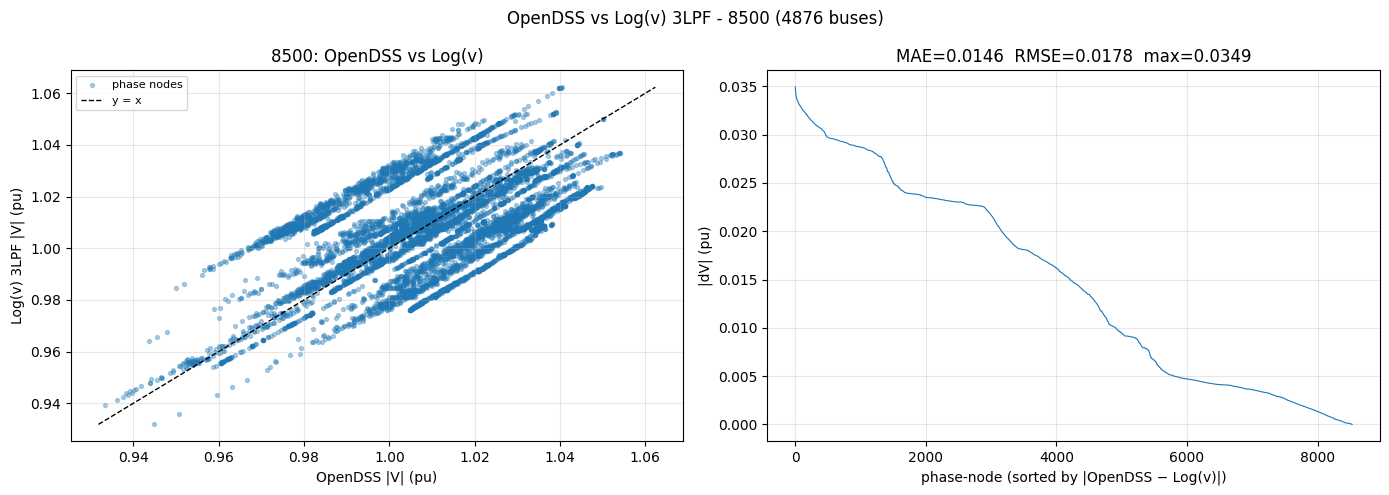

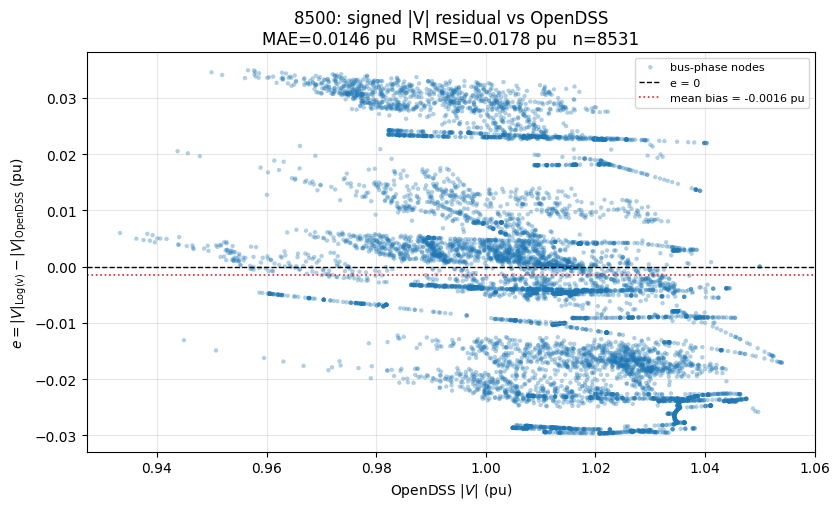

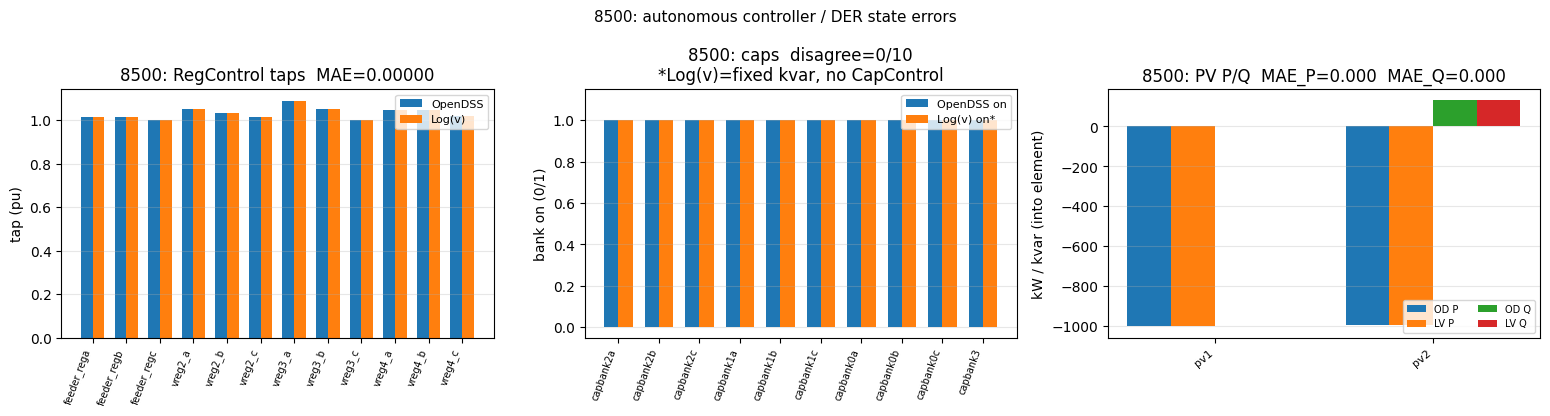


ACCURACY SUMMARY (SNAPSHOT)  feeder=8500  mode=synced
  |V| RMSE (pu)  : 0.017825269783593157
  |V| MAPE (%)   : 1.4444790793157125
  angle RMSE deg : 2.3062047325785326
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer hvmv_sub is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  8534
k =  72
Complexity of KLU decomposition, 3.32e+12 FLOPS 
Complexity of LogV algorithm, 4.69e+08 FLOPS 
Ratio 7064.29


c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DAILY OpenDSS vs Log(v)  feeder=8500  mode=synced  npts=24  step=60.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  plot nodes: ['l2841632.1', '190-8593.1']
  regs: ['reg_vreg3_a_tap_pu', 'reg_feeder_rega_tap_pu', 'reg_vreg2_a_tap_pu']
  caps: ['capbank0a', 'capbank1a', 'capbank2a', 'capbank3']
  load models: M1 constP×2354
  time_speed (FastLogv): True
  OD cold snapshot probe: InitSnap+Solve after metrics (ControlMode=Static; extra probe only — not primary OD metric)
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  fair Fast protocol: bake OD taps into A on change; Fast voltages -> metrics/plots (synced/off)
  profile: 8500 representative-day CSV -> explicit kW/kvar (snapshot)
Solving base case logv3lpf...
Bus 193-48013, phase mismatch
Bus 193-51796, phase mismatch
Bus e182745, phase mismatch
  [1/24] apply=0.01s reassert=0.00s solve=0.47s getV=0.06s  |V| MAE=0.01421  LV=403.8ms  Fast=5.4ms
Solving ba

C:\Users\alita\OneDrive\Desktop\GNN2\logv3lpf_daily_opendss_compare.py:569: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



ACCURACY SUMMARY (DAILY)  feeder=8500  mode=synced
  samples ok     : 24/24  (bad=0)
  mean |V| MAE   : 0.015062 pu
  mean |V| RMSE  : 0.016079 pu
  max  |V| MAE   : 0.016722 pu
  wall           : 108.4 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_8500_mode_synced_npts24_metrics.csv

SPEED SUMMARY (DAILY)  feeder=8500   <--- use MEAN numbers
  N samples ok    : 24
  logv source     : fast  fair_fast=True
  A rebuilds      : 19
  |V| MAE mean    : 0.015062 pu  (median 0.015006, max 0.016722)
  OD warm mean    : 184.527 ms  (median 163.422)
  OD cold mean    : 315.835 ms  (median 285.761)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 474.894 ms
  FastLogv mean   : 5.065 ms  (median 5.101)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  Fast refresh mean: 384.861 ms  (n=19; outside Fast timer)
  mean OD_warm/Fast: 36.43x
  mean OD_cold/Fast: 62.3

(<logv3lpf.run_case.case at 0x1bbac93d250>,
 {'mae': 0.014584379331163652,
  'rmse': 0.017825269783593157,
  'max': 0.034919902659956814,
  'n': 8531,
  'control_mode': 'synced',
  'n_reg': 12,
  'reg_iters': 12,
  'tap_mae': 0.0,
  'paper_accuracy': {'n_phase_nodes': 8531,
   'vm_rmse_pu': 0.017825269783593157,
   'vm_mape_pct': 1.4444790793157125,
   'vm_mae_pu': 0.014584379331163652,
   'va_rmse_deg': 2.3062047325785326,
   'va_rmse_deg_global_aligned': 0.9522017880408518,
   'va_source_offset_deg': -3.844541888990231e-05,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 8534.0,
   'n_excl_source': 8531.0,
   'n_source_phases': 3.0,
   'n_sys': 17068.0,
   'k': 72.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 12.0,
   'k_reg_phases': 24.0,
   'k_reg_primary_phases': 12.0,
   'k_woodbury_U': 24.0,
   'n_regulators': 12.0,
   'opendss_lu_flops': 3315960025450.0,
   'opendss_lu_flops_excl_source': 3312464635594.0,
   'logv_woodbury_update_flops': 469397464.0,
   'logv_a

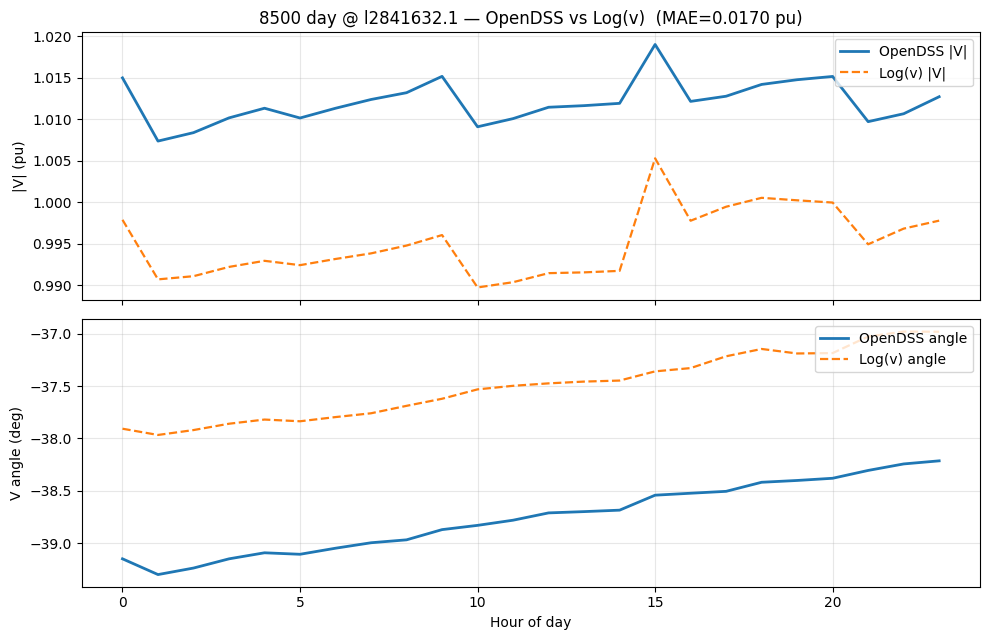

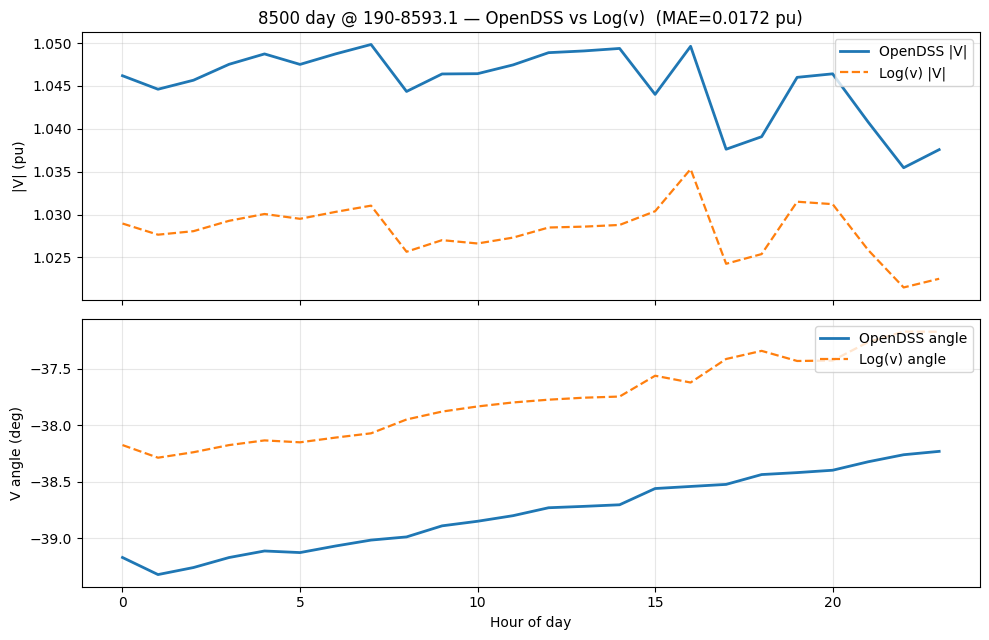

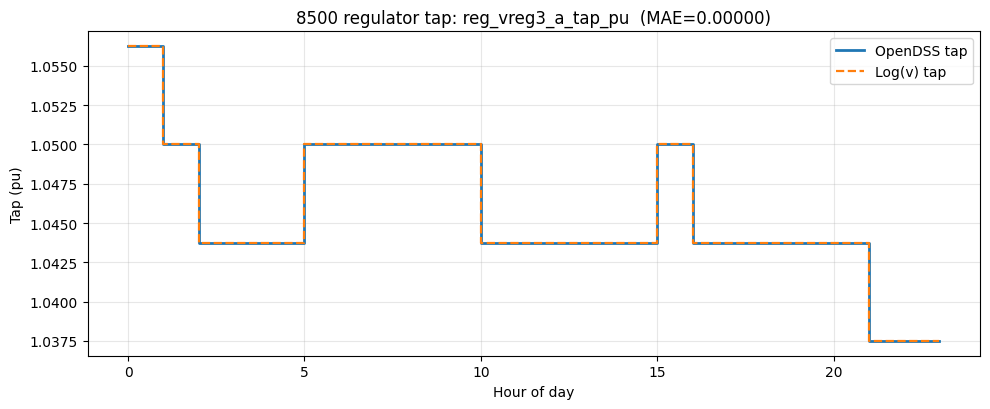

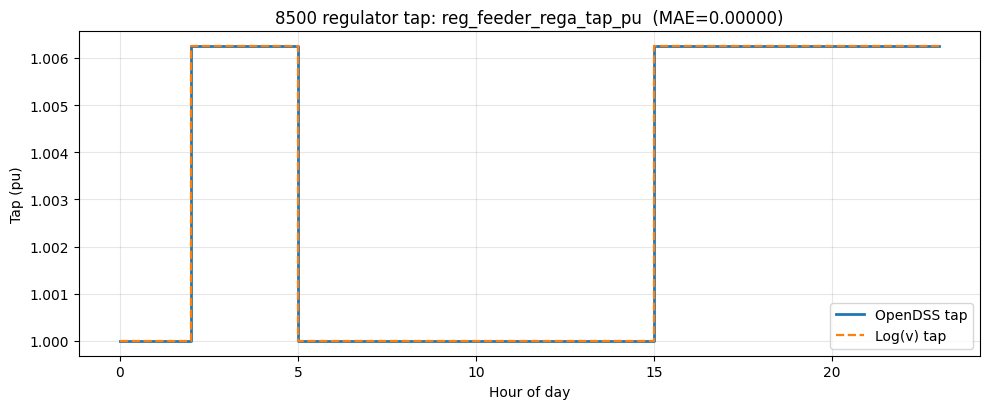

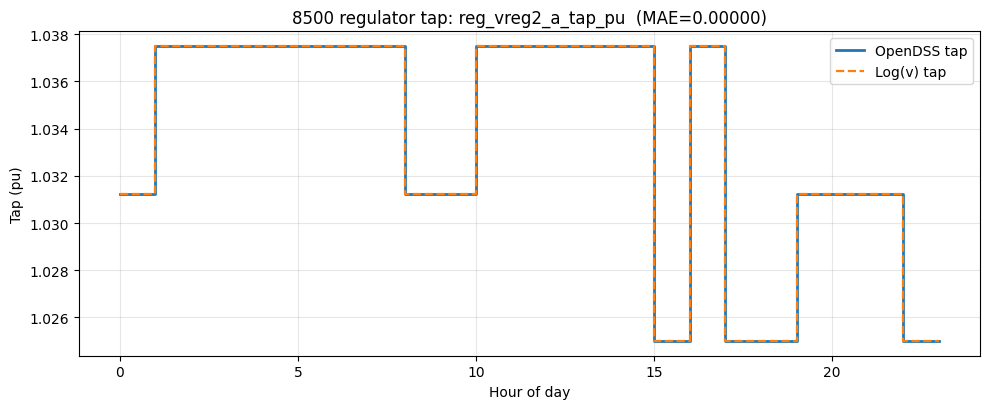

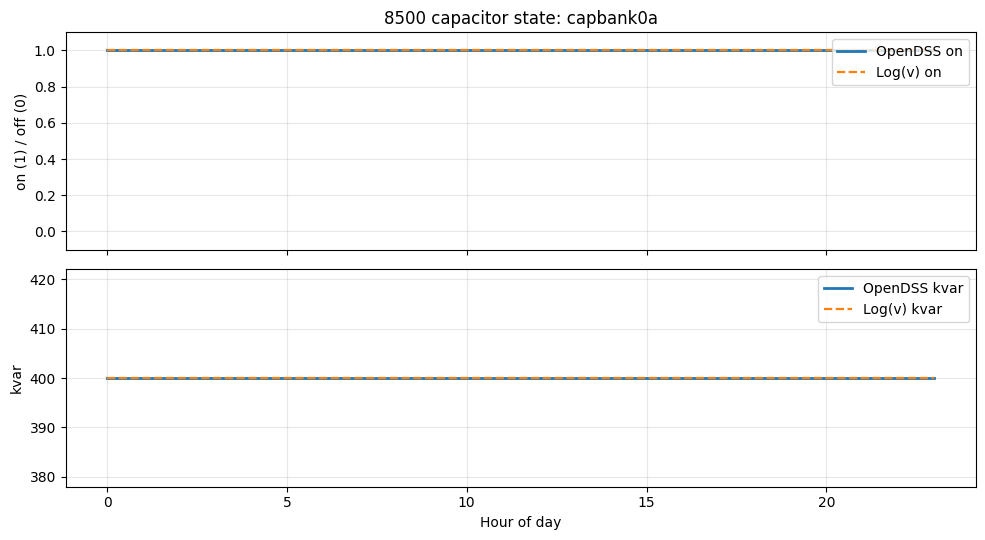

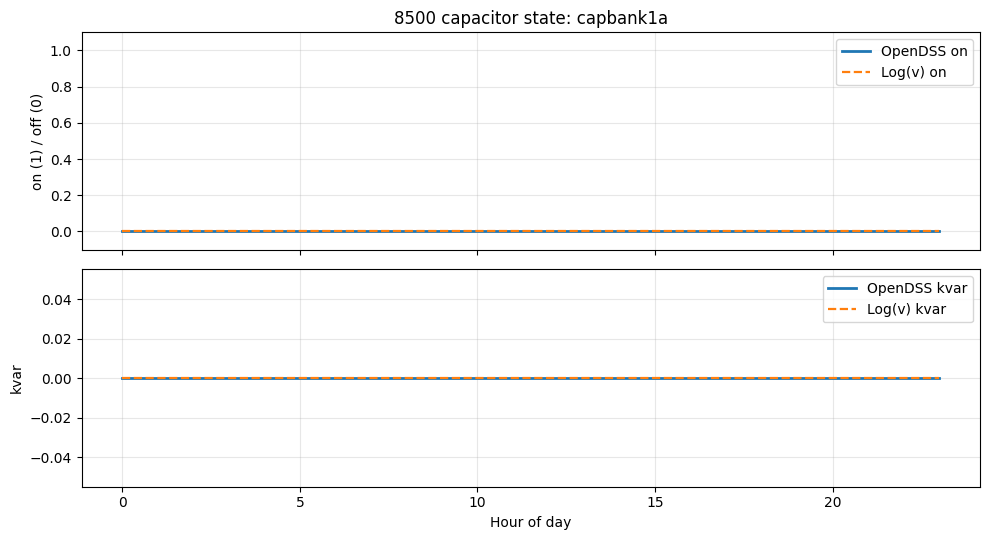

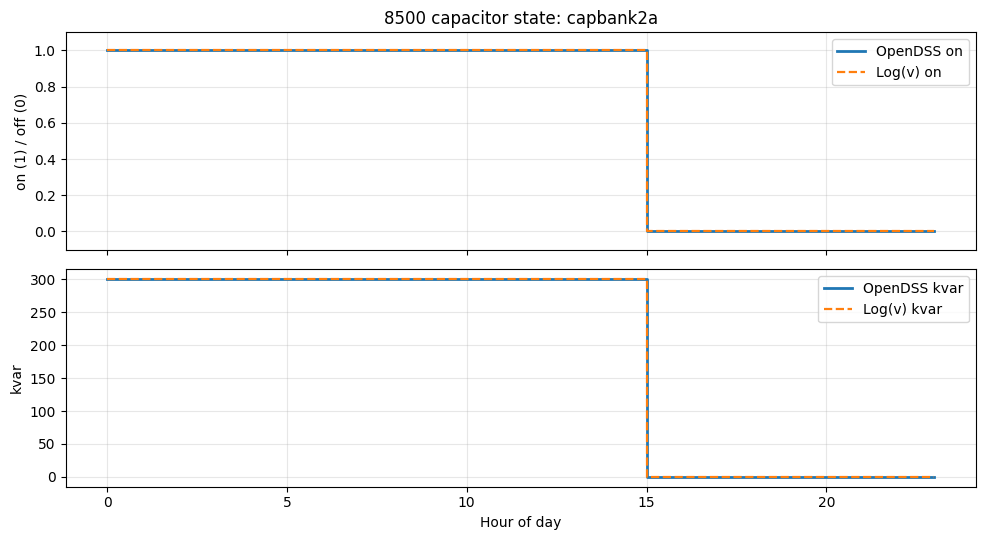

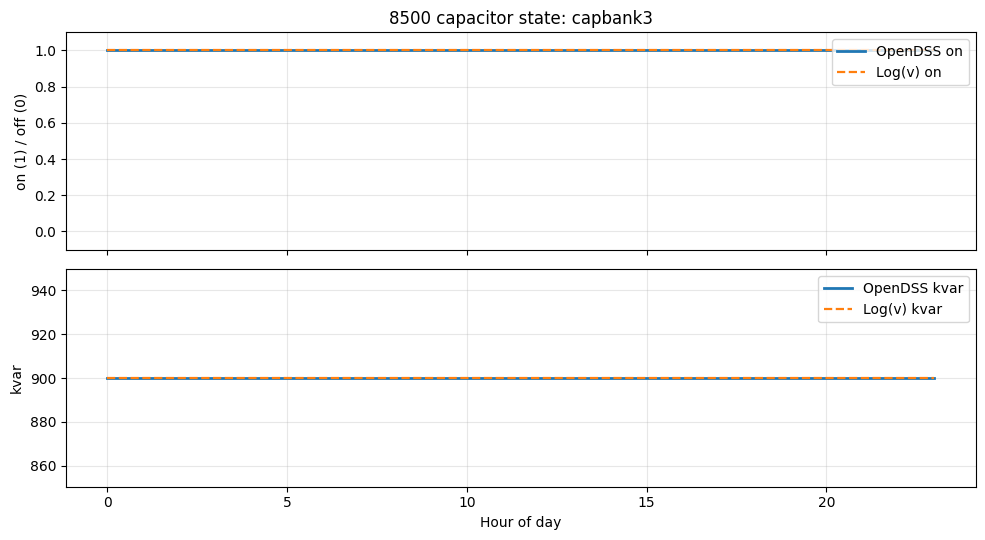

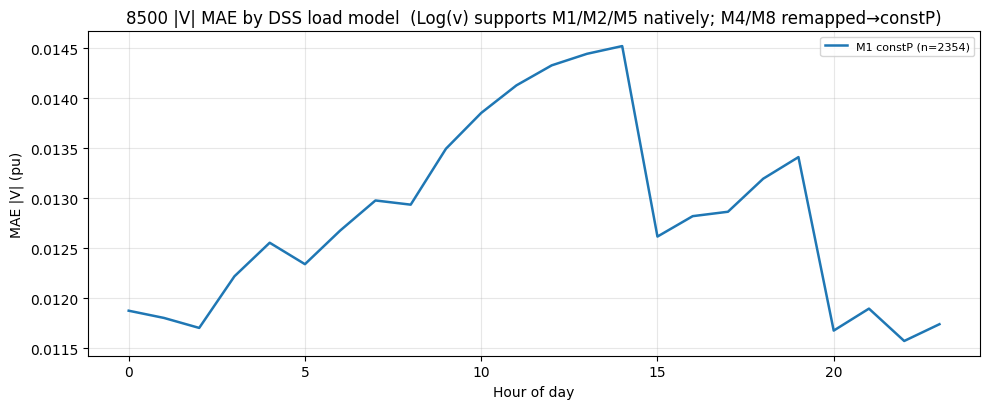

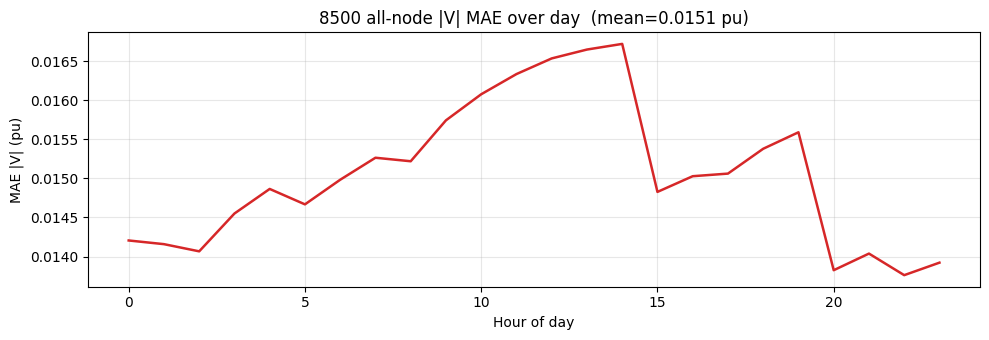

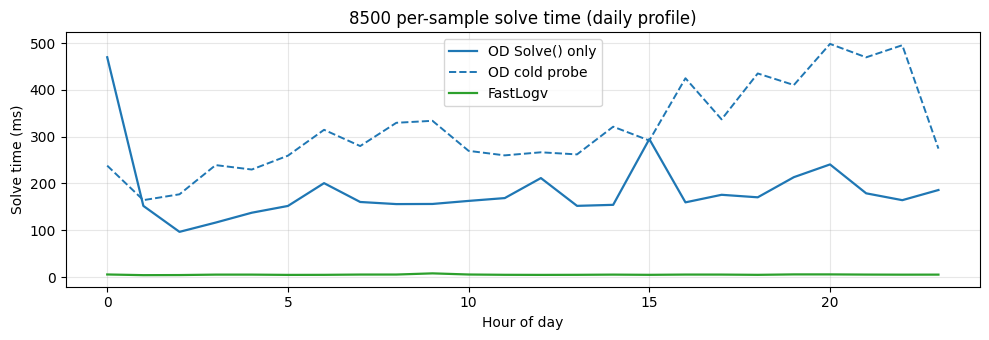

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "8500"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=8500  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 8500
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
 

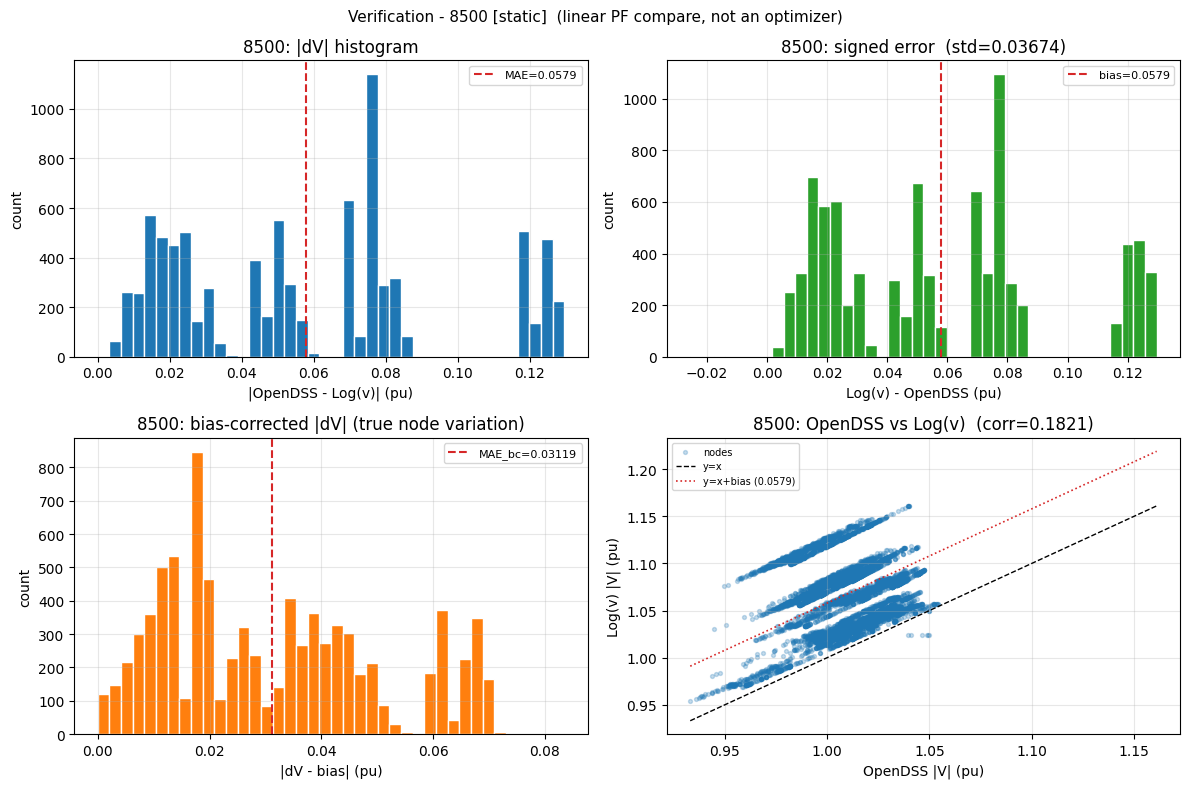

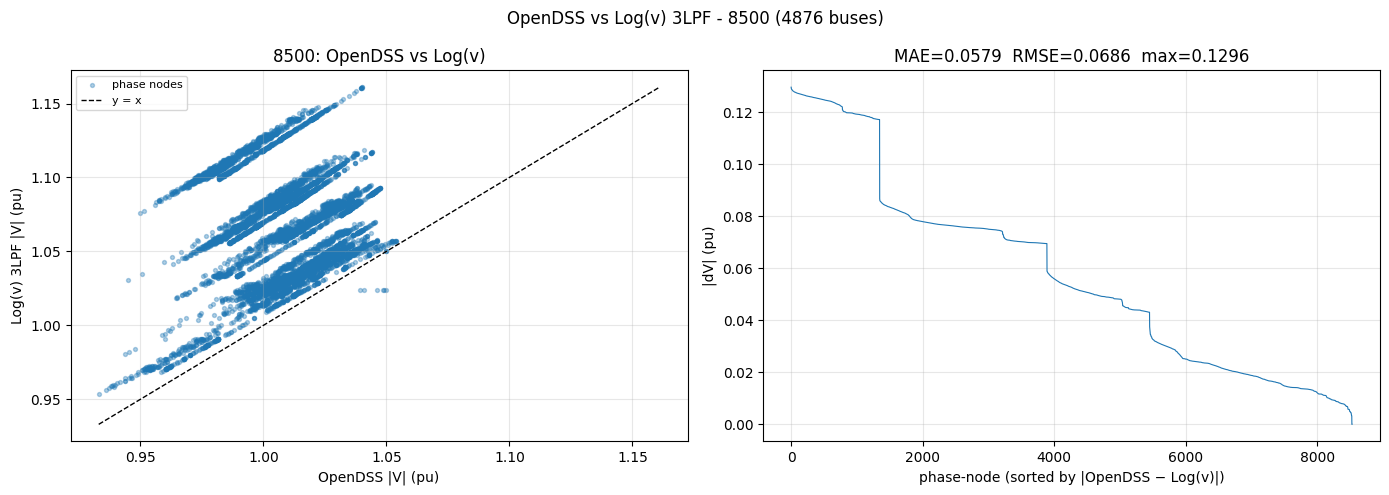

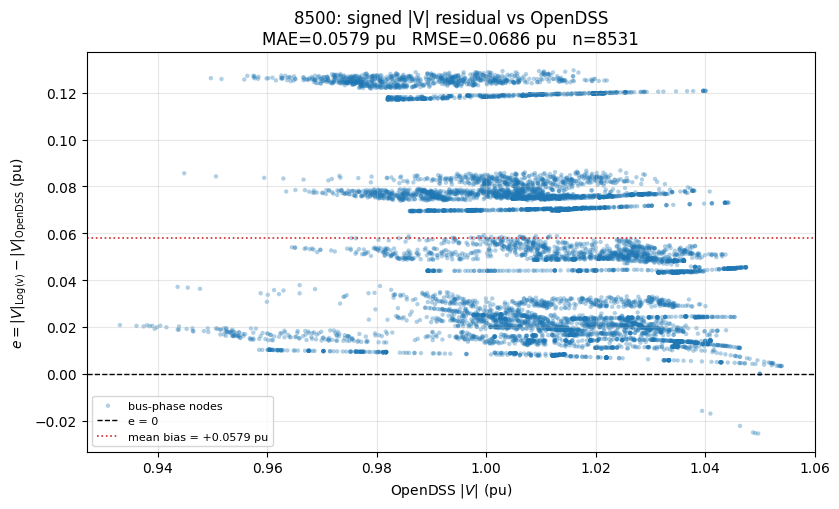

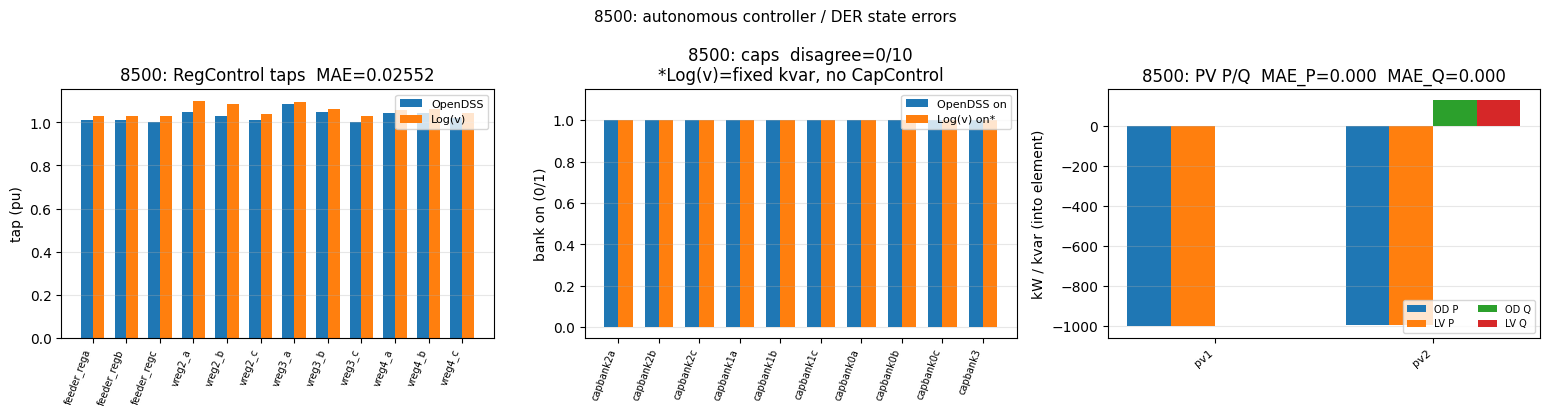


ACCURACY SUMMARY (SNAPSHOT)  feeder=8500  mode=static
  |V| RMSE (pu)  : 0.06856218488900076
  |V| MAPE (%)   : 5.767004077575042
  angle RMSE deg : 1.8670011478858646
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer hvmv_sub is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  8534
k =  72
Complexity of KLU decomposition, 3.32e+12 FLOPS 
Complexity of LogV algorithm, 4.69e+08 FLOPS 
Ratio 7064.29
DAILY OpenDSS vs Log(v)  feeder=8500  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  plot nodes: ['l2841632.1', '190-8593.1']
  regs: ['reg_vreg3_a_tap_pu', 'reg_feeder_rega_tap_pu

KeyboardInterrupt: 

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "8500"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


<!-- obsolete daily compare cell removed; use unified cell above -->


## IEEE 34 (Mirzaei) — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on **Dr. Mirzaei's IEEE34_PV.dss** (`new dss from dr mirzaei/IEEE34_PV.dss`).

Same chunked driver pattern as the 906 / 8500 cells above. Generator script: `run_original_style_dataset_ieee34_mirzaei.py`.

### Full vs smoke sizes
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### What this feeder has (vs 906 / 8500)
| | IEEE 8500 | 906 LVTestCase | **IEEE 34 Mirzaei** |
|---|---|---|---|
| DER | PV (+ optional BESS) | none | **PV850 + PV860** (PV850 has Volt-Var InvControl) |
| Load models | mostly const-P | const-P | **mixed ZIP**: DSS models 1 / 2 / 4 / 5 |
| Caps | CapControl banks | none | **fixed** C844 / C848 (no CapControl) |
| Regs | RegControl taps | none | native `rega*/regb*` transformers (**no RegControl**) |
| Profiles | 5-min load + irrad | 1-min load shapes | **5-min** `5minDayShape` + `IrradShape` (288 pts) |
| Trainer schema | real TARGET_* | dummy TARGET_* | **dummy TARGET_*** (same 8500 column names) + real IEEE34 meta for system tokens |

ZIP shares (`share_m*_p`) are **randomized per scenario** (`RANDOMIZE_ZIP_MODELS=True`) so those tokens are not constant; set False to keep the Mirzaei DSS default model mix.

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` — dummy 8500 `TARGET_*` plus IEEE34 tokens (grid, PV post, ZIP shares, native taps, fixed cap kvar)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads (compat copy; no split-phase agg)

### After generation
Point the IEEE34 DA-GPS training cell's `CHUNK_PARENT` at `CHUNK_ROOT` below.


In [22]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — IEEE 34 Mirzaei
# - runs in chunks, different seed / out folder per chunk
# - PE from static edges each chunk
# - *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 TARGET_* cap/reg meta + real IEEE34 system-token columns
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny path check; set False for full 2000×40

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 3420230

SIGMA_LOAD = 0.02
SIGMA_PV = 0.02

# Scenario totals are scaled around injection BASELINE (~849 kW / 501 kvar / 975 kW PV)
P_LOAD_SCALE_RANGE = (0.95, 1.05)
Q_LOAD_SCALE_RANGE = (0.95, 1.05)
P_PV_SCALE_RANGE = (0.95, 1.05)

VMIN_SAFE_PU = 0.85
VMAX_SAFE_PU = 1.10

# OpenDSS ControlMode while sampling: "static" lets InvControl Volt-Var settle;
# "off" freezes controls. Prefer static so PV Q (autonomous) varies in the data.
CONTROL_MODE = "static"
# Per-scenario random Load.Model in {1,2,4,5} so ZIP-share tokens are informative.
RANDOMIZE_ZIP_MODELS = True

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_ieee34_mirzaei.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_ieee34_mirzaei.py")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_ieee34_mirzaei_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_ieee34_mirzaei_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_ieee34_mirzaei_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_ieee34_mirzaei.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_ieee34_mirzaei", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

dss_file = ns["DSS_FILE"]
print("DSS_FILE:", dss_file)
print("DSS exists:", Path(dss_file).is_file())
if not Path(dss_file).is_file():
    raise FileNotFoundError(f"Missing IEEE34 DSS: {dss_file}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST} | CONTROL_MODE={CONTROL_MODE}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
        control_mode=str(CONTROL_MODE),
        randomize_zip_models=bool(RANDOMIZE_ZIP_MODELS),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_ieee34_mirzaei"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set IEEE34 DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


CHUNK_ROOT: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked
CWD: C:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_original_style_dataset_ieee34_mirzaei.py
DSS_FILE: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
DSS exists: True

Total chunks: 40 | SMOKE_TEST=False | CONTROL_MODE=static

=== Chunk 1/40 ===
Scenarios in chunk: 50
Seed: 3520233
OUT_DIR: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233
[DSS] maxcontroliter=20000
[ieee34] nodes_all=95 nodes_graph=89 control_mode=static
[saved] phase-edge CSV -> K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233\gnn_edges_phase_static.csv | rows=172 | cols=17 | bidirectional=True
[ieee34] computed PE k=8
[ieee34] scenario 1/50 done in 0.3s | samples so far=40
[ieee34] scenario 2/50 done in 0.3s | samples so far=80
[ieee34] scenario 3/50 done in 0.3s | samples so far=120
[ieee34] s

## DA-GPS training on IEEE 34 Mirzaei (chunked)

Train the existing multitask DA-GPS model on the **already-generated** IEEE34 chunked dataset. **Do not regenerate** for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`

### System / latent tokens (chosen for IEEE 34)

`--n_system_tokens` allocates learnable **global tokens** after the fixed (dummy) cap-bank and regulator tokens. With `--aux_meta_cols`, column `i` supervises system-token slot `i` via normalized MSE (`--lambda_pv`).

For IEEE 34 we use **10 supervised system tokens** that match what actually varies on this feeder:

| # | Meta column | Why |
|---|-------------|-----|
| 1–2 | `P_grid_upstream_post_kw`, `Q_grid_upstream_post_kvar` | Substation / net operating point |
| 3–4 | `pv_pv850_p_post_kw`, `pv_pv850_q_post_kvar` | PV850 **active + Volt-Var Q** (autonomous InvControl) |
| 5–6 | `pv_pv860_p_post_kw`, `pv_pv860_q_post_kvar` | PV860 post-solve P/Q |
| 7–10 | `share_m1_p`, `share_m2_p`, `share_m4_p`, `share_m5_p` | ZIP / load-model mix (ConstP / ConstZ / CVR / ConstI), **randomized per scenario** |

**Not** used as supervised tokens (written to meta for diagnostics only):

- Native `reg_*_tap_pu` — mostly fixed (no RegControl on Mirzaei)
- Fixed `cap_c844_*` / `cap_c848_*` kvar
- Dummy 8500 `TARGET_*` cap/reg columns — required by trainer schema; keep `lambda_cap=0`, `lambda_reg=0`

### IEEE 34 vs 906 vs 8500 training

| Setting | 8500 (typical) | 906 | **IEEE 34 (this cell)** |
|--------|----------------|-----|-------------------------|
| Dataset | `original_8500_...` | `original_906_...` | `original_ieee34_mirzaei_chunked` |
| `n_system_tokens` | 10 | 2 | **10** |
| Meta aux | PV + losses | grid P/Q | **grid + 2×PV P/Q + 4 ZIP shares** |
| Cap / reg loss | `> 0` | **0** | **0** (dummy TARGET_*) |
| Physics | optional | off | **off** (`PHYSICS_WEIGHT=0`) |

Caches use **ieee34-specific** names so they never collide with 906/8500.


In [20]:
# --- DA-GPS training on IEEE 34 Mirzaei (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_ieee34_mirzaei_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = True
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_ieee34_smoke_gine" if SMOKE_TEST else "da_gps_chunked_ieee34_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_ieee34_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_ieee34_mirzaei_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for IEEE34 (no 8500 PF catalogs)

# Substation upstream P/Q only (no PV aux, no loss tokens)
META_AUX_COLS = (
    "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,"
    "pv_pv850_p_post_kw,pv_pv850_q_post_kvar,"
    "pv_pv860_p_post_kw,pv_pv860_q_post_kvar,"
    "share_m1_p,share_m2_p,share_m4_p,share_m5_p"
)
N_SYSTEM_TOKENS = 10
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the 10 system tokens
LAMBDA_CAP = 0.0
LAMBDA_REG = 0.0

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (IEEE34 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_ieee34_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_gridPQ"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for IEEE34 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


FileNotFoundError: Repo root missing trainer script: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase

Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
  SKIP  run_001_scen_0000_0001_seed_3520233 (span=2; need span>=50 for full training)
  SKIP  run_002_scen_0002_0003_seed_3620236 (span=2; need span>=50 for full training)
  KEEP  run_001_scen_0000_0049_seed_3520233 (span=50; full)
  KEEP  run_002_scen_0050_0099_seed_3620236 (span=50; full)
  KEEP  run_003_scen_0100_0149_seed_3720239 (span=50; full)
  KEEP  run_004_scen_0150_0199_seed_3820242 (span=50; full)
  KEEP  run_005_scen_0200_0249_seed_3920245 (span=50; full)
  KEEP  run_006_scen_0250_0299_seed_4020248 (span=50; full)
  KEEP  run_007_scen_0300_0349_seed_4120251 (span=50; full)
  KEEP  run_008_scen_0350_0399_seed_4220254 (span=50; full)
  KEEP  run_009_scen_0400_0449_seed_4320257 (span=50; full)
  KEEP  run_010_scen_0450_0499_seed_4420260 (span=50; full)
  KEEP  run_011_scen_0500_0549_seed_4520263 (span=50; full)
  KEEP  run_012_scen_0550_0599_seed_4620266 (span=50; full)
  KEEP  run_013_scen_0600_0649_seed_4720269 (span=50; full)
  KEEP  run_014_scen_0650_0699_seed_4820272 (span=50; full)
  KEEP  run_015_scen_0700_0749_seed_4920275 (span=50; full)
  KEEP  run_016_scen_0750_0799_seed_5020278 (span=50; full)
  KEEP  run_017_scen_0800_0849_seed_5120281 (span=50; full)
  KEEP  run_018_scen_0850_0899_seed_5220284 (span=50; full)
  KEEP  run_019_scen_0900_0949_seed_5320287 (span=50; full)
  KEEP  run_020_scen_0950_0999_seed_5420290 (span=50; full)
  KEEP  run_021_scen_1000_1049_seed_5520293 (span=50; full)
  KEEP  run_022_scen_1050_1099_seed_5620296 (span=50; full)
  KEEP  run_023_scen_1100_1149_seed_5720299 (span=50; full)
  KEEP  run_024_scen_1150_1199_seed_5820302 (span=50; full)
  KEEP  run_025_scen_1200_1249_seed_5920305 (span=50; full)
  KEEP  run_026_scen_1250_1299_seed_6020308 (span=50; full)
  KEEP  run_027_scen_1300_1349_seed_6120311 (span=50; full)
  KEEP  run_028_scen_1350_1399_seed_6220314 (span=50; full)
  KEEP  run_029_scen_1400_1449_seed_6320317 (span=50; full)
  KEEP  run_030_scen_1450_1499_seed_6420320 (span=50; full)
  KEEP  run_031_scen_1500_1549_seed_6520323 (span=50; full)
  KEEP  run_032_scen_1550_1599_seed_6620326 (span=50; full)
  KEEP  run_033_scen_1600_1649_seed_6720329 (span=50; full)
  KEEP  run_034_scen_1650_1699_seed_6820332 (span=50; full)
  KEEP  run_035_scen_1700_1749_seed_6920335 (span=50; full)
  KEEP  run_036_scen_1750_1799_seed_7020338 (span=50; full)
  KEEP  run_037_scen_1800_1849_seed_7120341 (span=50; full)
  KEEP  run_038_scen_1850_1899_seed_7220344 (span=50; full)
  KEEP  run_039_scen_1900_1949_seed_7320347 (span=50; full)
  KEEP  run_040_scen_1950_1999_seed_7420350 (span=50; full)
=== Preflight (IEEE34 DA-GPS) ===
REPO:           /content/GNN-Sandia
SMOKE_TEST:     False
SMOKE_CHUNK_COUNT: 3
CHUNK_GLOB:     run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350
EPOCHS:         200
PATIENCE:       30
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
META_AUX_COLS:  P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,pv_pv850_p_post_kw,pv_pv850_q_post_kvar,pv_pv860_p_post_kw,pv_pv860_q_post_kvar,share_m1_p,share_m2_p,share_m4_p,share_m5_p
N_SYSTEM_TOKENS:10
META_LOSS_SCALE:0.001
lambda_cap/reg/pv: 0.0/0.0/0.1
PHYSICS_WEIGHT: 0.0
run_* preview:  ['run_001_scen_0000_0001_seed_3520233', 'run_001_scen_0000_0049_seed_3520233', 'run_002_scen_0002_0003_seed_3620236', 'run_002_scen_0050_0099_seed_3620236', 'run_003_scen_0100_0149_seed_3720239']
NODE_PE_CSV:    /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)
=================
Found 40 chunk(s) for CHUNK_GLOB under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
PHYSICS_WEIGHT=0.0 (baseline; no 8500 physics)
early_stop_on=total

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 10 --aux_meta_cols P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,pv_pv850_p_post_kw,pv_pv850_q_post_kvar,pv_pv860_p_post_kw,pv_pv860_q_post_kvar,share_m1_p,share_m2_p,share_m4_p,share_m5_p --meta_loss_scale 0.001 --lambda_pv 0.1 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --heads 2 --node_emb_dim 2 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.0 --lambda_reg 0.0 --reg_loss mse --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

meta_loss_scale=0.001: scaling P_loss_total_post_kw / Q_loss_total_post_kvar when those columns are loaded as meta-aux targets
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
Meta aux (sample_meta): 10 column(s); chunk DA caches use suffix __maux80f03146 (per chunk name).
  global token index 22 (system slot 0): column 'p_grid_upstream_post_kw'
  global token index 23 (system slot 1): column 'q_grid_upstream_post_kvar'
  global token index 24 (system slot 2): column 'pv_pv850_p_post_kw'
  global token index 25 (system slot 3): column 'pv_pv850_q_post_kvar'
  global token index 26 (system slot 4): column 'pv_pv860_p_post_kw'
  global token index 27 (system slot 5): column 'pv_pv860_q_post_kvar'
  global token index 28 (system slot 6): column 'share_m1_p'
  global token index 29 (system slot 7): column 'share_m2_p'
  global token index 30 (system slot 8): column 'share_m4_p'
  global token index 31 (system slot 9): column 'share_m5_p'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
  - run_001_scen_0000_0049_seed_3520233
  - run_002_scen_0050_0099_seed_3620236
  - run_003_scen_0100_0149_seed_3720239
  - run_004_scen_0150_0199_seed_3820242
  - run_005_scen_0200_0249_seed_3920245
  - run_006_scen_0250_0299_seed_4020248
  - run_007_scen_0300_0349_seed_4120251
  - run_008_scen_0350_0399_seed_4220254
  - run_009_scen_0400_0449_seed_4320257
  - run_010_scen_0450_0499_seed_4420260
  - run_011_scen_0500_0549_seed_4520263
  - run_012_scen_0550_0599_seed_4620266
  - run_013_scen_0600_0649_seed_4720269
  - run_014_scen_0650_0699_seed_4820272
  - run_015_scen_0700_0749_seed_4920275
  - run_016_scen_0750_0799_seed_5020278
  - run_017_scen_0800_0849_seed_5120281
  - run_018_scen_0850_0899_seed_5220284
  - run_019_scen_0900_0949_seed_5320287
  - run_020_scen_0950_0999_seed_5420290
  - run_021_scen_1000_1049_seed_5520293
  - run_022_scen_1050_1099_seed_5620296
  - run_023_scen_1100_1149_seed_5720299
  - run_024_scen_1150_1199_seed_5820302
  - run_025_scen_1200_1249_seed_5920305
  - run_026_scen_1250_1299_seed_6020308
  - run_027_scen_1300_1349_seed_6120311
  - run_028_scen_1350_1399_seed_6220314
  - run_029_scen_1400_1449_seed_6320317
  - run_030_scen_1450_1499_seed_6420320
  - run_031_scen_1500_1549_seed_6520323
  - run_032_scen_1550_1599_seed_6620326
  - run_033_scen_1600_1649_seed_6720329
  - run_034_scen_1650_1699_seed_6820332
  - run_035_scen_1700_1749_seed_6920335
  - run_036_scen_1750_1799_seed_7020338
  - run_037_scen_1800_1849_seed_7120341
  - run_038_scen_1850_1899_seed_7220344
  - run_039_scen_1900_1949_seed_7320347
  - run_040_scen_1950_1999_seed_7420350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_002_scen_0050_0099_seed_3620236/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_002_scen_0050_0099_seed_3620236__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_003_scen_0100_0149_seed_3720239/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_003_scen_0100_0149_seed_3720239__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_004_scen_0150_0199_seed_3820242/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_004_scen_0150_0199_seed_3820242__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_005_scen_0200_0249_seed_3920245/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_005_scen_0200_0249_seed_3920245__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_006_scen_0250_0299_seed_4020248/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_006_scen_0250_0299_seed_4020248__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_007_scen_0300_0349_seed_4120251/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_007_scen_0300_0349_seed_4120251__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_008_scen_0350_0399_seed_4220254/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_008_scen_0350_0399_seed_4220254__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_009_scen_0400_0449_seed_4320257/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_009_scen_0400_0449_seed_4320257__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_010_scen_0450_0499_seed_4420260/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_010_scen_0450_0499_seed_4420260__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_011_scen_0500_0549_seed_4520263/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_011_scen_0500_0549_seed_4520263__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_012_scen_0550_0599_seed_4620266/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_012_scen_0550_0599_seed_4620266__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_013_scen_0600_0649_seed_4720269/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_013_scen_0600_0649_seed_4720269__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_014_scen_0650_0699_seed_4820272/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_014_scen_0650_0699_seed_4820272__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_015_scen_0700_0749_seed_4920275/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_015_scen_0700_0749_seed_4920275__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_016_scen_0750_0799_seed_5020278/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_016_scen_0750_0799_seed_5020278__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_017_scen_0800_0849_seed_5120281/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_017_scen_0800_0849_seed_5120281__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_018_scen_0850_0899_seed_5220284/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_018_scen_0850_0899_seed_5220284__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_019_scen_0900_0949_seed_5320287/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_019_scen_0900_0949_seed_5320287__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_020_scen_0950_0999_seed_5420290/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_020_scen_0950_0999_seed_5420290__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_021_scen_1000_1049_seed_5520293/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_021_scen_1000_1049_seed_5520293__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_022_scen_1050_1099_seed_5620296/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_022_scen_1050_1099_seed_5620296__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_023_scen_1100_1149_seed_5720299/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_023_scen_1100_1149_seed_5720299__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_024_scen_1150_1199_seed_5820302/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_024_scen_1150_1199_seed_5820302__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_025_scen_1200_1249_seed_5920305/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_025_scen_1200_1249_seed_5920305__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_026_scen_1250_1299_seed_6020308/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_026_scen_1250_1299_seed_6020308__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_027_scen_1300_1349_seed_6120311/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_027_scen_1300_1349_seed_6120311__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_028_scen_1350_1399_seed_6220314/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_028_scen_1350_1399_seed_6220314__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_029_scen_1400_1449_seed_6320317/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_029_scen_1400_1449_seed_6320317__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_030_scen_1450_1499_seed_6420320/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_030_scen_1450_1499_seed_6420320__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_031_scen_1500_1549_seed_6520323/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_031_scen_1500_1549_seed_6520323__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_032_scen_1550_1599_seed_6620326/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_032_scen_1550_1599_seed_6620326__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_033_scen_1600_1649_seed_6720329/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_033_scen_1600_1649_seed_6720329__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_034_scen_1650_1699_seed_6820332/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_034_scen_1650_1699_seed_6820332__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_035_scen_1700_1749_seed_6920335/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_035_scen_1700_1749_seed_6920335__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_036_scen_1750_1799_seed_7020338/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_036_scen_1750_1799_seed_7020338__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_037_scen_1800_1849_seed_7120341/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_037_scen_1800_1849_seed_7120341__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_038_scen_1850_1899_seed_7220344/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_038_scen_1850_1899_seed_7220344__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_039_scen_1900_1949_seed_7320347/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_039_scen_1900_1949_seed_7320347__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_040_scen_1950_1999_seed_7420350/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_040_scen_1950_1999_seed_7420350__full__nobess__maux80f03146.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_run_manifest.json
torch.compile: enabled
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/200 | train_tot=0.2198 train_volt=0.1619 train_cap=0.6665 train_reg=0.5935 train_meta_aux=0.5787 val_meta_aux=0.4734 | val_tot=0.0816 val_volt=0.0343 val_cap=0.6234 val_reg=0.6752 | val_r2_mean=0.9564 val_r2_min=0.6758 val_r2_min_node=806.2 val_worst_mae=0.0076 | best=0.0816
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6480  cap_capbank0b_n_steps_on=0.6557  cap_capbank0c_n_steps_on=0.6722  cap_capbank1a_n_steps_on=0.6759  cap_capbank1b_n_steps_on=0.6566  cap_capbank1c_n_steps_on=0.6752
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6883  cap_capbank2b_n_steps_on=0.6632  cap_capbank2c_n_steps_on=0.6551  cap_capbank3_n_steps_on=0.6742
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6089  cap_capbank0b_n_steps_on=0.6146  cap_capbank0c_n_steps_on=0.6317  cap_capbank1a_n_steps_on=0.6246  cap_capbank1b_n_steps_on=0.6110  cap_capbank1c_n_steps_on=0.6248
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6494  cap_capbank2b_n_steps_on=0.6172  cap_capbank2c_n_steps_on=0.6226  cap_capbank3_n_steps_on=0.6290
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.5834  reg_feeder_regb_tap_pu=0.5752  reg_feeder_regc_tap_pu=0.5985  reg_vreg2_a_tap_pu=0.6527  reg_vreg2_b_tap_pu=0.5578  reg_vreg2_c_tap_pu=0.6011
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.5986  reg_vreg3_b_tap_pu=0.5709  reg_vreg3_c_tap_pu=0.6043  reg_vreg4_a_tap_pu=0.6103  reg_vreg4_b_tap_pu=0.5766  reg_vreg4_c_tap_pu=0.5923
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.6865  reg_feeder_regb_tap_pu=0.6486  reg_feeder_regc_tap_pu=0.6721  reg_vreg2_a_tap_pu=0.7070  reg_vreg2_b_tap_pu=0.6437  reg_vreg2_c_tap_pu=0.6938
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.6919  reg_vreg3_b_tap_pu=0.6429  reg_vreg3_c_tap_pu=0.6840  reg_vreg4_a_tap_pu=0.6772  reg_vreg4_b_tap_pu=0.6690  reg_vreg4_c_tap_pu=0.6858
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.1540  q_grid_upstream_post_kvar=0.1847  pv_pv850_p_post_kw=0.1727  pv_pv850_q_post_kvar=0.1601  pv_pv860_p_post_kw=0.1171  pv_pv860_q_post_kvar=0.9929
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9985  share_m2_p=1.0031  share_m4_p=1.0009  share_m5_p=1.0028
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0284  q_grid_upstream_post_kvar=0.0298  pv_pv850_p_post_kw=0.0335  pv_pv850_q_post_kvar=0.0135  pv_pv860_p_post_kw=0.0172  pv_pv860_q_post_kvar=0.5882
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0068  share_m2_p=1.0154  share_m4_p=1.0006  share_m5_p=1.0006

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.001691  angle MAE=0.061046  Re/Im MSE(nrm)=0.034276  r2_mean=0.9582  r2_min=0.9123  worst_mae=0.007631  tot=0.0816  volt=0.0343
Test  |V| MAE=0.001694  angle MAE=0.060061  Re/Im MSE(nrm)=0.034085  r2_mean=0.9578  r2_min=0.9127  worst_mae=0.007589  tot=0.1043  volt=0.0341
[da_gps chunk_parent] epoch   10/200 | train_tot=0.0592 train_volt=0.0091 train_cap=0.7221 train_reg=0.7186 train_meta_aux=0.5018 val_meta_aux=0.4609 | val_tot=0.0540 val_volt=0.0079 val_cap=0.6997 val_reg=0.7211 | val_r2_mean=0.9914 val_r2_min=0.9402 val_r2_min_node=806.2 val_worst_mae=0.0031 | best=0.0540
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7255  cap_capbank0b_n_steps_on=0.7137  cap_capbank0c_n_steps_on=0.7277  cap_capbank1a_n_steps_on=0.7250  cap_capbank1b_n_steps_on=0.7175  cap_capbank1c_n_steps_on=0.7212
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7215  cap_capbank2b_n_steps_on=0.7179  cap_capbank2c_n_steps_on=0.7228  cap_capbank3_n_steps_on=0.7280
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7034  cap_capbank0b_n_steps_on=0.6863  cap_capbank0c_n_steps_on=0.7200  cap_capbank1a_n_steps_on=0.6965  cap_capbank1b_n_steps_on=0.6926  cap_capbank1c_n_steps_on=0.6950
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7042  cap_capbank2b_n_steps_on=0.6994  cap_capbank2c_n_steps_on=0.6954  cap_capbank3_n_steps_on=0.7043
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.7232  reg_feeder_regb_tap_pu=0.7143  reg_feeder_regc_tap_pu=0.7152  reg_vreg2_a_tap_pu=0.7186  reg_vreg2_b_tap_pu=0.7180  reg_vreg2_c_tap_pu=0.7228
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.7213  reg_vreg3_b_tap_pu=0.7063  reg_vreg3_c_tap_pu=0.7252  reg_vreg4_a_tap_pu=0.7086  reg_vreg4_b_tap_pu=0.7236  reg_vreg4_c_tap_pu=0.7255
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.7268  reg_feeder_regb_tap_pu=0.7174  reg_feeder_regc_tap_pu=0.7189  reg_vreg2_a_tap_pu=0.7228  reg_vreg2_b_tap_pu=0.7173  reg_vreg2_c_tap_pu=0.7212
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.7231  reg_vreg3_b_tap_pu=0.7103  reg_vreg3_c_tap_pu=0.7302  reg_vreg4_a_tap_pu=0.7082  reg_vreg4_b_tap_pu=0.7274  reg_vreg4_c_tap_pu=0.7293
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0161  pv_pv850_p_post_kw=0.0095  pv_pv850_q_post_kvar=0.0081  pv_pv860_p_post_kw=0.0064  pv_pv860_q_post_kvar=0.9629
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0017  share_m2_p=1.0014  share_m4_p=1.0024  share_m5_p=1.0000
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0074  q_grid_upstream_post_kvar=0.0119  pv_pv850_p_post_kw=0.0045  pv_pv850_q_post_kvar=0.0075  pv_pv860_p_post_kw=0.0031  pv_pv860_q_post_kvar=0.5718
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0025  share_m2_p=1.0048  share_m4_p=0.9906  share_m5_p=1.0046

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.000782  angle MAE=0.027266  Re/Im MSE(nrm)=0.007922  r2_mean=0.9919  r2_min=0.9861  worst_mae=0.003115  tot=0.0540  volt=0.0079
Test  |V| MAE=0.000790  angle MAE=0.027431  Re/Im MSE(nrm)=0.008141  r2_mean=0.9916  r2_min=0.9856  worst_mae=0.003163  tot=0.0766  volt=0.0081
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0570 train_volt=0.0072 train_cap=0.7149 train_reg=0.4783 train_meta_aux=0.4982 val_meta_aux=0.4573 | val_tot=0.0554 val_volt=0.0097 val_cap=0.6849 val_reg=0.4799 | val_r2_mean=0.9888 val_r2_min=0.9100 val_r2_min_node=806.2 val_worst_mae=0.0036 | best=0.0540
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7213  cap_capbank0b_n_steps_on=0.7106  cap_capbank0c_n_steps_on=0.7223  cap_capbank1a_n_steps_on=0.7101  cap_capbank1b_n_steps_on=0.7096  cap_capbank1c_n_steps_on=0.7208
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7137  cap_capbank2b_n_steps_on=0.7114  cap_capbank2c_n_steps_on=0.7078  cap_capbank3_n_steps_on=0.7216
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6900  cap_capbank0b_n_steps_on=0.6876  cap_capbank0c_n_steps_on=0.6891  cap_capbank1a_n_steps_on=0.6820  cap_capbank1b_n_steps_on=0.6805  cap_capbank1c_n_steps_on=0.6868
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6912  cap_capbank2b_n_steps_on=0.6815  cap_capbank2c_n_steps_on=0.6711  cap_capbank3_n_steps_on=0.6890
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.4762  reg_feeder_regb_tap_pu=0.4746  reg_feeder_regc_tap_pu=0.4799  reg_vreg2_a_tap_pu=0.4751  reg_vreg2_b_tap_pu=0.4816  reg_vreg2_c_tap_pu=0.4770
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.4801  reg_vreg3_b_tap_pu=0.4753  reg_vreg3_c_tap_pu=0.4818  reg_vreg4_a_tap_pu=0.4722  reg_vreg4_b_tap_pu=0.4795  reg_vreg4_c_tap_pu=0.4861
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.4741  reg_feeder_regb_tap_pu=0.4801  reg_feeder_regc_tap_pu=0.4833  reg_vreg2_a_tap_pu=0.4762  reg_vreg2_b_tap_pu=0.4836  reg_vreg2_c_tap_pu=0.4758
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4847  reg_vreg3_b_tap_pu=0.4792  reg_vreg3_c_tap_pu=0.4792  reg_vreg4_a_tap_pu=0.4764  reg_vreg4_b_tap_pu=0.4786  reg_vreg4_c_tap_pu=0.4879
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0069  q_grid_upstream_post_kvar=0.0124  pv_pv850_p_post_kw=0.0058  pv_pv850_q_post_kvar=0.0064  pv_pv860_p_post_kw=0.0041  pv_pv860_q_post_kvar=0.9406
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0015  share_m2_p=1.0013  share_m4_p=1.0007  share_m5_p=1.0019
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0070  q_grid_upstream_post_kvar=0.0130  pv_pv850_p_post_kw=0.0036  pv_pv850_q_post_kvar=0.0063  pv_pv860_p_post_kw=0.0010  pv_pv860_q_post_kvar=0.5622
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9993  share_m2_p=1.0020  share_m4_p=0.9888  share_m5_p=0.9900

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.000944  angle MAE=0.024549  Re/Im MSE(nrm)=0.009703  r2_mean=0.9894  r2_min=0.9828  worst_mae=0.003640  tot=0.0554  volt=0.0097
Test  |V| MAE=0.000953  angle MAE=0.024512  Re/Im MSE(nrm)=0.009845  r2_mean=0.9892  r2_min=0.9823  worst_mae=0.003657  tot=0.0779  volt=0.0098
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0565 train_volt=0.0067 train_cap=0.7234 train_reg=0.3358 train_meta_aux=0.4973 val_meta_aux=0.4567 | val_tot=0.0512 val_volt=0.0055 val_cap=0.6980 val_reg=0.4048 | val_r2_mean=0.9934 val_r2_min=0.9470 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7278  cap_capbank0b_n_steps_on=0.7154  cap_capbank0c_n_steps_on=0.7280  cap_capbank1a_n_steps_on=0.7251  cap_capbank1b_n_steps_on=0.7207  cap_capbank1c_n_steps_on=0.7253
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7215  cap_capbank2b_n_steps_on=0.7234  cap_capbank2c_n_steps_on=0.7209  cap_capbank3_n_steps_on=0.7258
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7040  cap_capbank0b_n_steps_on=0.6928  cap_capbank0c_n_steps_on=0.6999  cap_capbank1a_n_steps_on=0.7007  cap_capbank1b_n_steps_on=0.6942  cap_capbank1c_n_steps_on=0.6996
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6935  cap_capbank2b_n_steps_on=0.6997  cap_capbank2c_n_steps_on=0.6979  cap_capbank3_n_steps_on=0.6977
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.3343  reg_feeder_regb_tap_pu=0.3351  reg_feeder_regc_tap_pu=0.3349  reg_vreg2_a_tap_pu=0.3350  reg_vreg2_b_tap_pu=0.3355  reg_vreg2_c_tap_pu=0.3339
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.3367  reg_vreg3_b_tap_pu=0.3362  reg_vreg3_c_tap_pu=0.3359  reg_vreg4_a_tap_pu=0.3357  reg_vreg4_b_tap_pu=0.3373  reg_vreg4_c_tap_pu=0.3394
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.4008  reg_feeder_regb_tap_pu=0.4045  reg_feeder_regc_tap_pu=0.4052  reg_vreg2_a_tap_pu=0.4078  reg_vreg2_b_tap_pu=0.4062  reg_vreg2_c_tap_pu=0.4011
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4023  reg_vreg3_b_tap_pu=0.4035  reg_vreg3_c_tap_pu=0.4069  reg_vreg4_a_tap_pu=0.4052  reg_vreg4_b_tap_pu=0.4084  reg_vreg4_c_tap_pu=0.4052
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0059  q_grid_upstream_post_kvar=0.0107  pv_pv850_p_post_kw=0.0047  pv_pv850_q_post_kvar=0.0056  pv_pv860_p_post_kw=0.0034  pv_pv860_q_post_kvar=0.9455
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0010  share_m2_p=1.0003  share_m4_p=0.9995  share_m5_p=0.9968
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0039  q_grid_upstream_post_kvar=0.0095  pv_pv850_p_post_kw=0.0017  pv_pv850_q_post_kvar=0.0048  pv_pv860_p_post_kw=0.0008  pv_pv860_q_post_kvar=0.5622
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0058  share_m4_p=0.9909  share_m5_p=0.9915

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.000689  angle MAE=0.018488  Re/Im MSE(nrm)=0.005541  r2_mean=0.9937  r2_min=0.9883  worst_mae=0.002875  tot=0.0512  volt=0.0055
Test  |V| MAE=0.000696  angle MAE=0.018615  Re/Im MSE(nrm)=0.005721  r2_mean=0.9935  r2_min=0.9877  worst_mae=0.002888  tot=0.0737  volt=0.0057
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0558 train_volt=0.0064 train_cap=0.7290 train_reg=0.2765 train_meta_aux=0.4937 val_meta_aux=0.4574 | val_tot=0.0525 val_volt=0.0068 val_cap=0.6981 val_reg=0.3094 | val_r2_mean=0.9914 val_r2_min=0.9368 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7326  cap_capbank0b_n_steps_on=0.7285  cap_capbank0c_n_steps_on=0.7293  cap_capbank1a_n_steps_on=0.7274  cap_capbank1b_n_steps_on=0.7286  cap_capbank1c_n_steps_on=0.7303
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7280  cap_capbank2b_n_steps_on=0.7309  cap_capbank2c_n_steps_on=0.7261  cap_capbank3_n_steps_on=0.7284
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7017  cap_capbank0b_n_steps_on=0.6970  cap_capbank0c_n_steps_on=0.6991  cap_capbank1a_n_steps_on=0.6970  cap_capbank1b_n_steps_on=0.6979  cap_capbank1c_n_steps_on=0.7009
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6982  cap_capbank2b_n_steps_on=0.6981  cap_capbank2c_n_steps_on=0.6947  cap_capbank3_n_steps_on=0.6969
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2727  reg_feeder_regb_tap_pu=0.2768  reg_feeder_regc_tap_pu=0.2716  reg_vreg2_a_tap_pu=0.2790  reg_vreg2_b_tap_pu=0.2774  reg_vreg2_c_tap_pu=0.2745
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2751  reg_vreg3_b_tap_pu=0.2796  reg_vreg3_c_tap_pu=0.2792  reg_vreg4_a_tap_pu=0.2773  reg_vreg4_b_tap_pu=0.2778  reg_vreg4_c_tap_pu=0.2773
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.3054  reg_feeder_regb_tap_pu=0.3060  reg_feeder_regc_tap_pu=0.3029  reg_vreg2_a_tap_pu=0.3109  reg_vreg2_b_tap_pu=0.3103  reg_vreg2_c_tap_pu=0.3078
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.3078  reg_vreg3_b_tap_pu=0.3146  reg_vreg3_c_tap_pu=0.3123  reg_vreg4_a_tap_pu=0.3121  reg_vreg4_b_tap_pu=0.3117  reg_vreg4_c_tap_pu=0.3110
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0056  q_grid_upstream_post_kvar=0.0101  pv_pv850_p_post_kw=0.0035  pv_pv850_q_post_kvar=0.0052  pv_pv860_p_post_kw=0.0030  pv_pv860_q_post_kvar=0.9118
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9996  share_m2_p=0.9993  share_m4_p=1.0015  share_m5_p=0.9978
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0085  pv_pv850_p_post_kw=0.0014  pv_pv850_q_post_kvar=0.0036  pv_pv860_p_post_kw=0.0009  pv_pv860_q_post_kvar=0.5635
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0009  share_m2_p=1.0060  share_m4_p=0.9914  share_m5_p=0.9932

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.000821  angle MAE=0.017484  Re/Im MSE(nrm)=0.006753  r2_mean=0.9919  r2_min=0.9873  worst_mae=0.002862  tot=0.0525  volt=0.0068
Test  |V| MAE=0.000824  angle MAE=0.017641  Re/Im MSE(nrm)=0.006849  r2_mean=0.9918  r2_min=0.9872  worst_mae=0.002870  tot=0.0742  volt=0.0068
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0554 train_volt=0.0061 train_cap=0.7296 train_reg=0.2432 train_meta_aux=0.4931 val_meta_aux=0.4604 | val_tot=0.0530 val_volt=0.0070 val_cap=0.7233 val_reg=0.2148 | val_r2_mean=0.9920 val_r2_min=0.9345 val_r2_min_node=806.2 val_worst_mae=0.0032 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7307  cap_capbank0b_n_steps_on=0.7283  cap_capbank0c_n_steps_on=0.7305  cap_capbank1a_n_steps_on=0.7280  cap_capbank1b_n_steps_on=0.7306  cap_capbank1c_n_steps_on=0.7316
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7272  cap_capbank2b_n_steps_on=0.7297  cap_capbank2c_n_steps_on=0.7290  cap_capbank3_n_steps_on=0.7304
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7255  cap_capbank0b_n_steps_on=0.7213  cap_capbank0c_n_steps_on=0.7241  cap_capbank1a_n_steps_on=0.7215  cap_capbank1b_n_steps_on=0.7236  cap_capbank1c_n_steps_on=0.7263
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7217  cap_capbank2b_n_steps_on=0.7216  cap_capbank2c_n_steps_on=0.7230  cap_capbank3_n_steps_on=0.7248
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2419  reg_feeder_regb_tap_pu=0.2422  reg_feeder_regc_tap_pu=0.2438  reg_vreg2_a_tap_pu=0.2433  reg_vreg2_b_tap_pu=0.2440  reg_vreg2_c_tap_pu=0.2397
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2410  reg_vreg3_b_tap_pu=0.2435  reg_vreg3_c_tap_pu=0.2483  reg_vreg4_a_tap_pu=0.2400  reg_vreg4_b_tap_pu=0.2454  reg_vreg4_c_tap_pu=0.2450
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.2088  reg_feeder_regb_tap_pu=0.2113  reg_feeder_regc_tap_pu=0.2181  reg_vreg2_a_tap_pu=0.2168  reg_vreg2_b_tap_pu=0.2166  reg_vreg2_c_tap_pu=0.2116
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.2164  reg_vreg3_b_tap_pu=0.2134  reg_vreg3_c_tap_pu=0.2183  reg_vreg4_a_tap_pu=0.2106  reg_vreg4_b_tap_pu=0.2166  reg_vreg4_c_tap_pu=0.2187
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0052  q_grid_upstream_post_kvar=0.0093  pv_pv850_p_post_kw=0.0030  pv_pv850_q_post_kvar=0.0047  pv_pv860_p_post_kw=0.0025  pv_pv860_q_post_kvar=0.9100
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9978  share_m2_p=0.9985  share_m4_p=1.0000  share_m5_p=0.9996
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0086  pv_pv850_p_post_kw=0.0031  pv_pv850_q_post_kvar=0.0042  pv_pv860_p_post_kw=0.0011  pv_pv860_q_post_kvar=0.6011
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9990  share_m2_p=1.0017  share_m4_p=0.9905  share_m5_p=0.9897

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.000747  angle MAE=0.020223  Re/Im MSE(nrm)=0.006964  r2_mean=0.9924  r2_min=0.9858  worst_mae=0.003217  tot=0.0530  volt=0.0070
Test  |V| MAE=0.000742  angle MAE=0.020351  Re/Im MSE(nrm)=0.006961  r2_mean=0.9925  r2_min=0.9856  worst_mae=0.003192  tot=0.0745  volt=0.0070
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0552 train_volt=0.0059 train_cap=0.7307 train_reg=0.2019 train_meta_aux=0.4935 val_meta_aux=0.4655 | val_tot=0.0529 val_volt=0.0064 val_cap=0.7179 val_reg=0.1774 | val_r2_mean=0.9923 val_r2_min=0.9394 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7297  cap_capbank0b_n_steps_on=0.7286  cap_capbank0c_n_steps_on=0.7339  cap_capbank1a_n_steps_on=0.7295  cap_capbank1b_n_steps_on=0.7286  cap_capbank1c_n_steps_on=0.7324
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7313  cap_capbank2b_n_steps_on=0.7290  cap_capbank2c_n_steps_on=0.7316  cap_capbank3_n_steps_on=0.7321
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7177  cap_capbank0b_n_steps_on=0.7179  cap_capbank0c_n_steps_on=0.7215  cap_capbank1a_n_steps_on=0.7149  cap_capbank1b_n_steps_on=0.7151  cap_capbank1c_n_steps_on=0.7178
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7181  cap_capbank2b_n_steps_on=0.7164  cap_capbank2c_n_steps_on=0.7177  cap_capbank3_n_steps_on=0.7217
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1998  reg_feeder_regb_tap_pu=0.2013  reg_feeder_regc_tap_pu=0.2044  reg_vreg2_a_tap_pu=0.2038  reg_vreg2_b_tap_pu=0.2005  reg_vreg2_c_tap_pu=0.2032
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2049  reg_vreg3_b_tap_pu=0.1986  reg_vreg3_c_tap_pu=0.2049  reg_vreg4_a_tap_pu=0.1982  reg_vreg4_b_tap_pu=0.1990  reg_vreg4_c_tap_pu=0.2043
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1770  reg_feeder_regb_tap_pu=0.1784  reg_feeder_regc_tap_pu=0.1770  reg_vreg2_a_tap_pu=0.1772  reg_vreg2_b_tap_pu=0.1770  reg_vreg2_c_tap_pu=0.1781
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1792  reg_vreg3_b_tap_pu=0.1751  reg_vreg3_c_tap_pu=0.1813  reg_vreg4_a_tap_pu=0.1747  reg_vreg4_b_tap_pu=0.1743  reg_vreg4_c_tap_pu=0.1796
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0027  pv_pv850_q_post_kvar=0.0046  pv_pv860_p_post_kw=0.0024  pv_pv860_q_post_kvar=0.9144
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9990  share_m2_p=0.9998  share_m4_p=0.9992  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0057  q_grid_upstream_post_kvar=0.0073  pv_pv850_p_post_kw=0.0036  pv_pv850_q_post_kvar=0.0050  pv_pv860_p_post_kw=0.0011  pv_pv860_q_post_kvar=0.6566
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0013  share_m4_p=0.9869  share_m5_p=0.9910

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.000730  angle MAE=0.022653  Re/Im MSE(nrm)=0.006358  r2_mean=0.9927  r2_min=0.9870  worst_mae=0.002946  tot=0.0529  volt=0.0064
Test  |V| MAE=0.000731  angle MAE=0.022620  Re/Im MSE(nrm)=0.006553  r2_mean=0.9925  r2_min=0.9866  worst_mae=0.002950  tot=0.0719  volt=0.0066
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.0551 train_volt=0.0058 train_cap=0.7194 train_reg=0.1698 train_meta_aux=0.4930 val_meta_aux=0.4646 | val_tot=0.0520 val_volt=0.0055 val_cap=0.6929 val_reg=0.1903 | val_r2_mean=0.9932 val_r2_min=0.9496 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7198  cap_capbank0b_n_steps_on=0.7180  cap_capbank0c_n_steps_on=0.7208  cap_capbank1a_n_steps_on=0.7187  cap_capbank1b_n_steps_on=0.7180  cap_capbank1c_n_steps_on=0.7205
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7174  cap_capbank2b_n_steps_on=0.7187  cap_capbank2c_n_steps_on=0.7219  cap_capbank3_n_steps_on=0.7199
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6947  cap_capbank0b_n_steps_on=0.6906  cap_capbank0c_n_steps_on=0.6949  cap_capbank1a_n_steps_on=0.6930  cap_capbank1b_n_steps_on=0.6917  cap_capbank1c_n_steps_on=0.6938
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6898  cap_capbank2b_n_steps_on=0.6921  cap_capbank2c_n_steps_on=0.6945  cap_capbank3_n_steps_on=0.6941
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1683  reg_feeder_regb_tap_pu=0.1706  reg_feeder_regc_tap_pu=0.1716  reg_vreg2_a_tap_pu=0.1702  reg_vreg2_b_tap_pu=0.1710  reg_vreg2_c_tap_pu=0.1705
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1643  reg_vreg3_b_tap_pu=0.1714  reg_vreg3_c_tap_pu=0.1699  reg_vreg4_a_tap_pu=0.1710  reg_vreg4_b_tap_pu=0.1708  reg_vreg4_c_tap_pu=0.1678
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1888  reg_feeder_regb_tap_pu=0.1909  reg_feeder_regc_tap_pu=0.1919  reg_vreg2_a_tap_pu=0.1908  reg_vreg2_b_tap_pu=0.1918  reg_vreg2_c_tap_pu=0.1914
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1855  reg_vreg3_b_tap_pu=0.1915  reg_vreg3_c_tap_pu=0.1914  reg_vreg4_a_tap_pu=0.1901  reg_vreg4_b_tap_pu=0.1902  reg_vreg4_c_tap_pu=0.1897
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0049  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0027  pv_pv850_q_post_kvar=0.0046  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.9154
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9982  share_m2_p=0.9977  share_m4_p=0.9993  share_m5_p=0.9962
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0044  q_grid_upstream_post_kvar=0.0072  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0014  pv_pv860_q_post_kvar=0.6227
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9963  share_m2_p=1.0186  share_m4_p=0.9896  share_m5_p=1.0012

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.000688  angle MAE=0.017370  Re/Im MSE(nrm)=0.005549  r2_mean=0.9936  r2_min=0.9889  worst_mae=0.002727  tot=0.0520  volt=0.0055
Test  |V| MAE=0.000701  angle MAE=0.017694  Re/Im MSE(nrm)=0.005906  r2_mean=0.9932  r2_min=0.9884  worst_mae=0.002750  tot=0.0712  volt=0.0059
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.0548 train_volt=0.0057 train_cap=0.7234 train_reg=0.1413 train_meta_aux=0.4907 val_meta_aux=0.4571 | val_tot=0.0516 val_volt=0.0059 val_cap=0.7046 val_reg=0.1638 | val_r2_mean=0.9925 val_r2_min=0.9400 val_r2_min_node=806.2 val_worst_mae=0.0030 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7253  cap_capbank0b_n_steps_on=0.7213  cap_capbank0c_n_steps_on=0.7237  cap_capbank1a_n_steps_on=0.7206  cap_capbank1b_n_steps_on=0.7238  cap_capbank1c_n_steps_on=0.7248
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7224  cap_capbank2b_n_steps_on=0.7227  cap_capbank2c_n_steps_on=0.7240  cap_capbank3_n_steps_on=0.7251
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7064  cap_capbank0b_n_steps_on=0.7035  cap_capbank0c_n_steps_on=0.7045  cap_capbank1a_n_steps_on=0.7017  cap_capbank1b_n_steps_on=0.7055  cap_capbank1c_n_steps_on=0.7059
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7035  cap_capbank2b_n_steps_on=0.7026  cap_capbank2c_n_steps_on=0.7050  cap_capbank3_n_steps_on=0.7076
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1419  reg_feeder_regb_tap_pu=0.1388  reg_feeder_regc_tap_pu=0.1423  reg_vreg2_a_tap_pu=0.1394  reg_vreg2_b_tap_pu=0.1446  reg_vreg2_c_tap_pu=0.1427
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1392  reg_vreg3_b_tap_pu=0.1403  reg_vreg3_c_tap_pu=0.1419  reg_vreg4_a_tap_pu=0.1421  reg_vreg4_b_tap_pu=0.1402  reg_vreg4_c_tap_pu=0.1419
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1657  reg_feeder_regb_tap_pu=0.1598  reg_feeder_regc_tap_pu=0.1674  reg_vreg2_a_tap_pu=0.1605  reg_vreg2_b_tap_pu=0.1653  reg_vreg2_c_tap_pu=0.1655
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1627  reg_vreg3_b_tap_pu=0.1632  reg_vreg3_c_tap_pu=0.1668  reg_vreg4_a_tap_pu=0.1635  reg_vreg4_b_tap_pu=0.1604  reg_vreg4_c_tap_pu=0.1654
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0049  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0025  pv_pv850_q_post_kvar=0.0044  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.8913
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9979  share_m2_p=0.9996  share_m4_p=0.9978  share_m5_p=0.9975
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0060  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0033  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5685
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0035  share_m4_p=0.9972  share_m5_p=0.9917

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.000733  angle MAE=0.017348  Re/Im MSE(nrm)=0.005865  r2_mean=0.9929  r2_min=0.9875  worst_mae=0.003034  tot=0.0516  volt=0.0059
Test  |V| MAE=0.000735  angle MAE=0.017417  Re/Im MSE(nrm)=0.006007  r2_mean=0.9928  r2_min=0.9871  worst_mae=0.003033  tot=0.0732  volt=0.0060
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   90/200 | train_tot=0.0543 train_volt=0.0056 train_cap=0.7083 train_reg=0.1193 train_meta_aux=0.4873 val_meta_aux=0.4556 | val_tot=0.0509 val_volt=0.0054 val_cap=0.7003 val_reg=0.1324 | val_r2_mean=0.9935 val_r2_min=0.9521 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0509
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7086  cap_capbank0b_n_steps_on=0.7079  cap_capbank0c_n_steps_on=0.7087  cap_capbank1a_n_steps_on=0.7067  cap_capbank1b_n_steps_on=0.7075  cap_capbank1c_n_steps_on=0.7079
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7074  cap_capbank2b_n_steps_on=0.7090  cap_capbank2c_n_steps_on=0.7082  cap_capbank3_n_steps_on=0.7114
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7012  cap_capbank0b_n_steps_on=0.6997  cap_capbank0c_n_steps_on=0.7013  cap_capbank1a_n_steps_on=0.6986  cap_capbank1b_n_steps_on=0.6987  cap_capbank1c_n_steps_on=0.7004
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6997  cap_capbank2b_n_steps_on=0.7006  cap_capbank2c_n_steps_on=0.6995  cap_capbank3_n_steps_on=0.7035
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1200  reg_feeder_regb_tap_pu=0.1171  reg_feeder_regc_tap_pu=0.1203  reg_vreg2_a_tap_pu=0.1164  reg_vreg2_b_tap_pu=0.1211  reg_vreg2_c_tap_pu=0.1211
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1175  reg_vreg3_b_tap_pu=0.1205  reg_vreg3_c_tap_pu=0.1202  reg_vreg4_a_tap_pu=0.1199  reg_vreg4_b_tap_pu=0.1169  reg_vreg4_c_tap_pu=0.1209
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1312  reg_feeder_regb_tap_pu=0.1292  reg_feeder_regc_tap_pu=0.1359  reg_vreg2_a_tap_pu=0.1293  reg_vreg2_b_tap_pu=0.1347  reg_vreg2_c_tap_pu=0.1357
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1296  reg_vreg3_b_tap_pu=0.1343  reg_vreg3_c_tap_pu=0.1327  reg_vreg4_a_tap_pu=0.1333  reg_vreg4_b_tap_pu=0.1296  reg_vreg4_c_tap_pu=0.1336
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0048  q_grid_upstream_post_kvar=0.0086  pv_pv850_p_post_kw=0.0030  pv_pv850_q_post_kvar=0.0044  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.8543
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9960  share_m2_p=0.9992  share_m4_p=1.0013  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0062  pv_pv850_p_post_kw=0.0009  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5608
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9963  share_m2_p=0.9997  share_m4_p=0.9897  share_m5_p=0.9949

=== train_pool_eval (epoch 90) ===
Val  |V| MAE=0.000684  angle MAE=0.016239  Re/Im MSE(nrm)=0.005380  r2_mean=0.9939  r2_min=0.9885  worst_mae=0.002890  tot=0.0509  volt=0.0054
Test  |V| MAE=0.000695  angle MAE=0.016198  Re/Im MSE(nrm)=0.005671  r2_mean=0.9935  r2_min=0.9879  worst_mae=0.002910  tot=0.0706  volt=0.0057
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  100/200 | train_tot=0.0552 train_volt=0.0056 train_cap=0.7075 train_reg=0.1107 train_meta_aux=0.4960 val_meta_aux=0.4558 | val_tot=0.0510 val_volt=0.0054 val_cap=0.7051 val_reg=0.1283 | val_r2_mean=0.9940 val_r2_min=0.9519 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0509
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7076  cap_capbank0b_n_steps_on=0.7076  cap_capbank0c_n_steps_on=0.7075  cap_capbank1a_n_steps_on=0.7066  cap_capbank1b_n_steps_on=0.7071  cap_capbank1c_n_steps_on=0.7072
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7059  cap_capbank2b_n_steps_on=0.7087  cap_capbank2c_n_steps_on=0.7066  cap_capbank3_n_steps_on=0.7102
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7044  cap_capbank0b_n_steps_on=0.7056  cap_capbank0c_n_steps_on=0.7050  cap_capbank1a_n_steps_on=0.7040  cap_capbank1b_n_steps_on=0.7047  cap_capbank1c_n_steps_on=0.7053
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7031  cap_capbank2b_n_steps_on=0.7067  cap_capbank2c_n_steps_on=0.7046  cap_capbank3_n_steps_on=0.7077
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1097  reg_feeder_regb_tap_pu=0.1077  reg_feeder_regc_tap_pu=0.1112  reg_vreg2_a_tap_pu=0.1085  reg_vreg2_b_tap_pu=0.1122  reg_vreg2_c_tap_pu=0.1134
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1087  reg_vreg3_b_tap_pu=0.1114  reg_vreg3_c_tap_pu=0.1108  reg_vreg4_a_tap_pu=0.1102  reg_vreg4_b_tap_pu=0.1120  reg_vreg4_c_tap_pu=0.1128
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1255  reg_feeder_regb_tap_pu=0.1237  reg_feeder_regc_tap_pu=0.1280  reg_vreg2_a_tap_pu=0.1259  reg_vreg2_b_tap_pu=0.1313  reg_vreg2_c_tap_pu=0.1314
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1247  reg_vreg3_b_tap_pu=0.1311  reg_vreg3_c_tap_pu=0.1276  reg_vreg4_a_tap_pu=0.1296  reg_vreg4_b_tap_pu=0.1303  reg_vreg4_c_tap_pu=0.1305
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0091  pv_pv850_p_post_kw=0.0021  pv_pv850_q_post_kvar=0.0047  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.9446
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9969  share_m2_p=0.9975  share_m4_p=0.9995  share_m5_p=0.9979
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0025  q_grid_upstream_post_kvar=0.0076  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0031  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5631
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9995  share_m2_p=1.0002  share_m4_p=0.9905  share_m5_p=0.9891

=== train_pool_eval (epoch 100) ===
Val  |V| MAE=0.000641  angle MAE=0.019656  Re/Im MSE(nrm)=0.005404  r2_mean=0.9943  r2_min=0.9899  worst_mae=0.002679  tot=0.0510  volt=0.0054
Test  |V| MAE=0.000643  angle MAE=0.019846  Re/Im MSE(nrm)=0.005499  r2_mean=0.9943  r2_min=0.9897  worst_mae=0.002676  tot=0.0724  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  110/200 | train_tot=0.0543 train_volt=0.0055 train_cap=0.7087 train_reg=0.0974 train_meta_aux=0.4884 val_meta_aux=0.4550 | val_tot=0.0507 val_volt=0.0052 val_cap=0.7074 val_reg=0.1057 | val_r2_mean=0.9935 val_r2_min=0.9507 val_r2_min_node=806.2 val_worst_mae=0.0028 | best=0.0507
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7077  cap_capbank0b_n_steps_on=0.7085  cap_capbank0c_n_steps_on=0.7108  cap_capbank1a_n_steps_on=0.7087  cap_capbank1b_n_steps_on=0.7073  cap_capbank1c_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7065  cap_capbank2b_n_steps_on=0.7094  cap_capbank2c_n_steps_on=0.7088  cap_capbank3_n_steps_on=0.7107
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7054  cap_capbank0b_n_steps_on=0.7070  cap_capbank0c_n_steps_on=0.7104  cap_capbank1a_n_steps_on=0.7081  cap_capbank1b_n_steps_on=0.7051  cap_capbank1c_n_steps_on=0.7069
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7059  cap_capbank2b_n_steps_on=0.7078  cap_capbank2c_n_steps_on=0.7073  cap_capbank3_n_steps_on=0.7100
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0971  reg_feeder_regb_tap_pu=0.0978  reg_feeder_regc_tap_pu=0.0984  reg_vreg2_a_tap_pu=0.0962  reg_vreg2_b_tap_pu=0.0969  reg_vreg2_c_tap_pu=0.0978
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0963  reg_vreg3_b_tap_pu=0.0995  reg_vreg3_c_tap_pu=0.0981  reg_vreg4_a_tap_pu=0.0977  reg_vreg4_b_tap_pu=0.0950  reg_vreg4_c_tap_pu=0.0984
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1064  reg_feeder_regb_tap_pu=0.1056  reg_feeder_regc_tap_pu=0.1070  reg_vreg2_a_tap_pu=0.1040  reg_vreg2_b_tap_pu=0.1053  reg_vreg2_c_tap_pu=0.1072
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1058  reg_vreg3_b_tap_pu=0.1060  reg_vreg3_c_tap_pu=0.1069  reg_vreg4_a_tap_pu=0.1064  reg_vreg4_b_tap_pu=0.1018  reg_vreg4_c_tap_pu=0.1055
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0046  q_grid_upstream_post_kvar=0.0084  pv_pv850_p_post_kw=0.0020  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0021  pv_pv860_q_post_kvar=0.8706
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9970  share_m2_p=0.9990  share_m4_p=0.9996  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5667
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9934  share_m2_p=0.9995  share_m4_p=0.9884  share_m5_p=0.9885

=== train_pool_eval (epoch 110) ===
Val  |V| MAE=0.000671  angle MAE=0.015649  Re/Im MSE(nrm)=0.005243  r2_mean=0.9938  r2_min=0.9887  worst_mae=0.002769  tot=0.0507  volt=0.0052
Test  |V| MAE=0.000682  angle MAE=0.015718  Re/Im MSE(nrm)=0.005596  r2_mean=0.9934  r2_min=0.9880  worst_mae=0.002788  tot=0.0705  volt=0.0056
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  120/200 | train_tot=0.0537 train_volt=0.0055 train_cap=0.7063 train_reg=0.0879 train_meta_aux=0.4822 val_meta_aux=0.4559 | val_tot=0.0509 val_volt=0.0053 val_cap=0.7156 val_reg=0.0896 | val_r2_mean=0.9937 val_r2_min=0.9508 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0507
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7064  cap_capbank0b_n_steps_on=0.7041  cap_capbank0c_n_steps_on=0.7072  cap_capbank1a_n_steps_on=0.7055  cap_capbank1b_n_steps_on=0.7057  cap_capbank1c_n_steps_on=0.7062
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7054  cap_capbank2b_n_steps_on=0.7071  cap_capbank2c_n_steps_on=0.7065  cap_capbank3_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7148  cap_capbank0b_n_steps_on=0.7137  cap_capbank0c_n_steps_on=0.7167  cap_capbank1a_n_steps_on=0.7152  cap_capbank1b_n_steps_on=0.7154  cap_capbank1c_n_steps_on=0.7152
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7140  cap_capbank2b_n_steps_on=0.7162  cap_capbank2c_n_steps_on=0.7152  cap_capbank3_n_steps_on=0.7194
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0883  reg_feeder_regb_tap_pu=0.0887  reg_feeder_regc_tap_pu=0.0877  reg_vreg2_a_tap_pu=0.0885  reg_vreg2_b_tap_pu=0.0892  reg_vreg2_c_tap_pu=0.0878
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0883  reg_vreg3_b_tap_pu=0.0842  reg_vreg3_c_tap_pu=0.0863  reg_vreg4_a_tap_pu=0.0893  reg_vreg4_b_tap_pu=0.0874  reg_vreg4_c_tap_pu=0.0888
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0882  reg_feeder_regb_tap_pu=0.0894  reg_feeder_regc_tap_pu=0.0897  reg_vreg2_a_tap_pu=0.0896  reg_vreg2_b_tap_pu=0.0906  reg_vreg2_c_tap_pu=0.0898
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0900  reg_vreg3_b_tap_pu=0.0880  reg_vreg3_c_tap_pu=0.0885  reg_vreg4_a_tap_pu=0.0918  reg_vreg4_b_tap_pu=0.0882  reg_vreg4_c_tap_pu=0.0917
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0045  q_grid_upstream_post_kvar=0.0082  pv_pv850_p_post_kw=0.0017  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0020  pv_pv860_q_post_kvar=0.8094
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9963  share_m2_p=0.9981  share_m4_p=0.9994  share_m5_p=0.9978
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0060  pv_pv850_p_post_kw=0.0008  pv_pv850_q_post_kvar=0.0035  pv_pv860_p_post_kw=0.0010  pv_pv860_q_post_kvar=0.5690
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9981  share_m2_p=0.9988  share_m4_p=0.9880  share_m5_p=0.9906

=== train_pool_eval (epoch 120) ===
Val  |V| MAE=0.000667  angle MAE=0.017420  Re/Im MSE(nrm)=0.005293  r2_mean=0.9940  r2_min=0.9893  worst_mae=0.002729  tot=0.0509  volt=0.0053
Test  |V| MAE=0.000669  angle MAE=0.017694  Re/Im MSE(nrm)=0.005501  r2_mean=0.9938  r2_min=0.9889  worst_mae=0.002725  tot=0.0695  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  130/200 | train_tot=0.0546 train_volt=0.0054 train_cap=0.7038 train_reg=0.0817 train_meta_aux=0.4921 val_meta_aux=0.4553 | val_tot=0.0506 val_volt=0.0050 val_cap=0.7159 val_reg=0.0933 | val_r2_mean=0.9940 val_r2_min=0.9546 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7038  cap_capbank0b_n_steps_on=0.7033  cap_capbank0c_n_steps_on=0.7037  cap_capbank1a_n_steps_on=0.7032  cap_capbank1b_n_steps_on=0.7042  cap_capbank1c_n_steps_on=0.7027
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7032  cap_capbank2b_n_steps_on=0.7038  cap_capbank2c_n_steps_on=0.7045  cap_capbank3_n_steps_on=0.7054
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7145  cap_capbank0b_n_steps_on=0.7146  cap_capbank0c_n_steps_on=0.7158  cap_capbank1a_n_steps_on=0.7172  cap_capbank1b_n_steps_on=0.7167  cap_capbank1c_n_steps_on=0.7140
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7149  cap_capbank2b_n_steps_on=0.7164  cap_capbank2c_n_steps_on=0.7153  cap_capbank3_n_steps_on=0.7200
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0831  reg_feeder_regb_tap_pu=0.0813  reg_feeder_regc_tap_pu=0.0825  reg_vreg2_a_tap_pu=0.0771  reg_vreg2_b_tap_pu=0.0802  reg_vreg2_c_tap_pu=0.0835
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0811  reg_vreg3_b_tap_pu=0.0792  reg_vreg3_c_tap_pu=0.0831  reg_vreg4_a_tap_pu=0.0846  reg_vreg4_b_tap_pu=0.0806  reg_vreg4_c_tap_pu=0.0839
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0940  reg_feeder_regb_tap_pu=0.0929  reg_feeder_regc_tap_pu=0.0944  reg_vreg2_a_tap_pu=0.0933  reg_vreg2_b_tap_pu=0.0937  reg_vreg2_c_tap_pu=0.0939
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0929  reg_vreg3_b_tap_pu=0.0928  reg_vreg3_c_tap_pu=0.0941  reg_vreg4_a_tap_pu=0.0944  reg_vreg4_b_tap_pu=0.0912  reg_vreg4_c_tap_pu=0.0925
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0045  q_grid_upstream_post_kvar=0.0083  pv_pv850_p_post_kw=0.0026  pv_pv850_q_post_kvar=0.0042  pv_pv860_p_post_kw=0.0022  pv_pv860_q_post_kvar=0.9100
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9975  share_m2_p=0.9966  share_m4_p=0.9987  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0029  q_grid_upstream_post_kvar=0.0059  pv_pv850_p_post_kw=0.0007  pv_pv850_q_post_kvar=0.0033  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5653
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9922  share_m2_p=1.0026  share_m4_p=0.9911  share_m5_p=0.9889

=== train_pool_eval (epoch 130) ===
Val  |V| MAE=0.000661  angle MAE=0.016158  Re/Im MSE(nrm)=0.005047  r2_mean=0.9943  r2_min=0.9899  worst_mae=0.002724  tot=0.0506  volt=0.0050
Test  |V| MAE=0.000672  angle MAE=0.016464  Re/Im MSE(nrm)=0.005319  r2_mean=0.9940  r2_min=0.9894  worst_mae=0.002757  tot=0.0691  volt=0.0053
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  140/200 | train_tot=0.0537 train_volt=0.0053 train_cap=0.7063 train_reg=0.0739 train_meta_aux=0.4833 val_meta_aux=0.4558 | val_tot=0.0509 val_volt=0.0053 val_cap=0.7111 val_reg=0.0777 | val_r2_mean=0.9939 val_r2_min=0.9540 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7073  cap_capbank0b_n_steps_on=0.7062  cap_capbank0c_n_steps_on=0.7079  cap_capbank1a_n_steps_on=0.7050  cap_capbank1b_n_steps_on=0.7070  cap_capbank1c_n_steps_on=0.7057
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7045  cap_capbank2b_n_steps_on=0.7054  cap_capbank2c_n_steps_on=0.7064  cap_capbank3_n_steps_on=0.7076
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7126  cap_capbank0b_n_steps_on=0.7109  cap_capbank0c_n_steps_on=0.7139  cap_capbank1a_n_steps_on=0.7086  cap_capbank1b_n_steps_on=0.7116  cap_capbank1c_n_steps_on=0.7105
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7086  cap_capbank2b_n_steps_on=0.7101  cap_capbank2c_n_steps_on=0.7114  cap_capbank3_n_steps_on=0.7129
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0749  reg_feeder_regb_tap_pu=0.0738  reg_feeder_regc_tap_pu=0.0744  reg_vreg2_a_tap_pu=0.0738  reg_vreg2_b_tap_pu=0.0750  reg_vreg2_c_tap_pu=0.0707
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0747  reg_vreg3_b_tap_pu=0.0755  reg_vreg3_c_tap_pu=0.0739  reg_vreg4_a_tap_pu=0.0744  reg_vreg4_b_tap_pu=0.0725  reg_vreg4_c_tap_pu=0.0727
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0770  reg_feeder_regb_tap_pu=0.0772  reg_feeder_regc_tap_pu=0.0782  reg_vreg2_a_tap_pu=0.0791  reg_vreg2_b_tap_pu=0.0811  reg_vreg2_c_tap_pu=0.0814
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0752  reg_vreg3_b_tap_pu=0.0811  reg_vreg3_c_tap_pu=0.0779  reg_vreg4_a_tap_pu=0.0770  reg_vreg4_b_tap_pu=0.0739  reg_vreg4_c_tap_pu=0.0737
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0081  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0040  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.8186
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9972  share_m2_p=0.9984  share_m4_p=0.9996  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0063  pv_pv850_p_post_kw=0.0005  pv_pv850_q_post_kvar=0.0032  pv_pv860_p_post_kw=0.0005  pv_pv860_q_post_kvar=0.5732
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9954  share_m2_p=0.9982  share_m4_p=0.9880  share_m5_p=0.9896

=== train_pool_eval (epoch 140) ===
Val  |V| MAE=0.000661  angle MAE=0.017566  Re/Im MSE(nrm)=0.005328  r2_mean=0.9942  r2_min=0.9894  worst_mae=0.002683  tot=0.0509  volt=0.0053
Test  |V| MAE=0.000665  angle MAE=0.017644  Re/Im MSE(nrm)=0.005487  r2_mean=0.9940  r2_min=0.9890  worst_mae=0.002685  tot=0.0694  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  150/200 | train_tot=0.0531 train_volt=0.0053 train_cap=0.7086 train_reg=0.0700 train_meta_aux=0.4776 val_meta_aux=0.4586 | val_tot=0.0510 val_volt=0.0051 val_cap=0.6943 val_reg=0.0841 | val_r2_mean=0.9940 val_r2_min=0.9536 val_r2_min_node=806.2 val_worst_mae=0.0026 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7082  cap_capbank0b_n_steps_on=0.7095  cap_capbank0c_n_steps_on=0.7111  cap_capbank1a_n_steps_on=0.7078  cap_capbank1b_n_steps_on=0.7097  cap_capbank1c_n_steps_on=0.7071
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7085  cap_capbank2b_n_steps_on=0.7076  cap_capbank2c_n_steps_on=0.7077  cap_capbank3_n_steps_on=0.7084
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6925  cap_capbank0b_n_steps_on=0.6946  cap_capbank0c_n_steps_on=0.6963  cap_capbank1a_n_steps_on=0.6948  cap_capbank1b_n_steps_on=0.6965  cap_capbank1c_n_steps_on=0.6924
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6944  cap_capbank2b_n_steps_on=0.6932  cap_capbank2c_n_steps_on=0.6941  cap_capbank3_n_steps_on=0.6941
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0686  reg_feeder_regb_tap_pu=0.0696  reg_feeder_regc_tap_pu=0.0700  reg_vreg2_a_tap_pu=0.0704  reg_vreg2_b_tap_pu=0.0704  reg_vreg2_c_tap_pu=0.0717
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0710  reg_vreg3_b_tap_pu=0.0717  reg_vreg3_c_tap_pu=0.0676  reg_vreg4_a_tap_pu=0.0711  reg_vreg4_b_tap_pu=0.0679  reg_vreg4_c_tap_pu=0.0694
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0810  reg_feeder_regb_tap_pu=0.0843  reg_feeder_regc_tap_pu=0.0851  reg_vreg2_a_tap_pu=0.0857  reg_vreg2_b_tap_pu=0.0847  reg_vreg2_c_tap_pu=0.0860
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0857  reg_vreg3_b_tap_pu=0.0847  reg_vreg3_c_tap_pu=0.0819  reg_vreg4_a_tap_pu=0.0851  reg_vreg4_b_tap_pu=0.0815  reg_vreg4_c_tap_pu=0.0835
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0042  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0018  pv_pv860_q_post_kvar=0.7675
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9978  share_m2_p=0.9948  share_m4_p=1.0000  share_m5_p=0.9966
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0027  q_grid_upstream_post_kvar=0.0055  pv_pv850_p_post_kw=0.0011  pv_pv850_q_post_kvar=0.0028  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.6028
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9939  share_m2_p=0.9998  share_m4_p=0.9874  share_m5_p=0.9896

=== train_pool_eval (epoch 150) ===
Val  |V| MAE=0.000640  angle MAE=0.017448  Re/Im MSE(nrm)=0.005120  r2_mean=0.9943  r2_min=0.9901  worst_mae=0.002632  tot=0.0510  volt=0.0051
Test  |V| MAE=0.000641  angle MAE=0.017257  Re/Im MSE(nrm)=0.005194  r2_mean=0.9943  r2_min=0.9898  worst_mae=0.002631  tot=0.0623  volt=0.0052
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  160/200 | train_tot=0.0526 train_volt=0.0053 train_cap=0.7110 train_reg=0.0644 train_meta_aux=0.4731 val_meta_aux=0.4579 | val_tot=0.0507 val_volt=0.0049 val_cap=0.7232 val_reg=0.0664 | val_r2_mean=0.9941 val_r2_min=0.9552 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7097  cap_capbank0b_n_steps_on=0.7122  cap_capbank0c_n_steps_on=0.7117  cap_capbank1a_n_steps_on=0.7109  cap_capbank1b_n_steps_on=0.7116  cap_capbank1c_n_steps_on=0.7100
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7108  cap_capbank2b_n_steps_on=0.7103  cap_capbank2c_n_steps_on=0.7113  cap_capbank3_n_steps_on=0.7117
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7201  cap_capbank0b_n_steps_on=0.7243  cap_capbank0c_n_steps_on=0.7255  cap_capbank1a_n_steps_on=0.7236  cap_capbank1b_n_steps_on=0.7239  cap_capbank1c_n_steps_on=0.7223
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7226  cap_capbank2b_n_steps_on=0.7228  cap_capbank2c_n_steps_on=0.7226  cap_capbank3_n_steps_on=0.7240
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0594  reg_feeder_regb_tap_pu=0.0657  reg_feeder_regc_tap_pu=0.0626  reg_vreg2_a_tap_pu=0.0668  reg_vreg2_b_tap_pu=0.0641  reg_vreg2_c_tap_pu=0.0646
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0677  reg_vreg3_b_tap_pu=0.0658  reg_vreg3_c_tap_pu=0.0639  reg_vreg4_a_tap_pu=0.0647  reg_vreg4_b_tap_pu=0.0629  reg_vreg4_c_tap_pu=0.0649
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0595  reg_feeder_regb_tap_pu=0.0691  reg_feeder_regc_tap_pu=0.0651  reg_vreg2_a_tap_pu=0.0690  reg_vreg2_b_tap_pu=0.0659  reg_vreg2_c_tap_pu=0.0671
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0695  reg_vreg3_b_tap_pu=0.0692  reg_vreg3_c_tap_pu=0.0645  reg_vreg4_a_tap_pu=0.0675  reg_vreg4_b_tap_pu=0.0645  reg_vreg4_c_tap_pu=0.0656
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0042  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.7261
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9937  share_m2_p=0.9963  share_m4_p=0.9989  share_m5_p=0.9965
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0054  pv_pv850_p_post_kw=0.0007  pv_pv850_q_post_kvar=0.0030  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5845
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9976  share_m2_p=1.0041  share_m4_p=0.9880  share_m5_p=0.9920

=== train_pool_eval (epoch 160) ===
Val  |V| MAE=0.000641  angle MAE=0.017436  Re/Im MSE(nrm)=0.004923  r2_mean=0.9944  r2_min=0.9897  worst_mae=0.002681  tot=0.0507  volt=0.0049
Test  |V| MAE=0.000654  angle MAE=0.017743  Re/Im MSE(nrm)=0.005207  r2_mean=0.9941  r2_min=0.9891  worst_mae=0.002717  tot=0.0683  volt=0.0052
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  170/200 | train_tot=0.0528 train_volt=0.0053 train_cap=0.7081 train_reg=0.0657 train_meta_aux=0.4744 val_meta_aux=0.4579 | val_tot=0.0511 val_volt=0.0053 val_cap=0.7200 val_reg=0.0759 | val_r2_mean=0.9938 val_r2_min=0.9536 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7092  cap_capbank0b_n_steps_on=0.7088  cap_capbank0c_n_steps_on=0.7097  cap_capbank1a_n_steps_on=0.7065  cap_capbank1b_n_steps_on=0.7092  cap_capbank1c_n_steps_on=0.7067
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7083  cap_capbank2b_n_steps_on=0.7074  cap_capbank2c_n_steps_on=0.7076  cap_capbank3_n_steps_on=0.7077
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7203  cap_capbank0b_n_steps_on=0.7195  cap_capbank0c_n_steps_on=0.7226  cap_capbank1a_n_steps_on=0.7206  cap_capbank1b_n_steps_on=0.7204  cap_capbank1c_n_steps_on=0.7190
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7192  cap_capbank2b_n_steps_on=0.7178  cap_capbank2c_n_steps_on=0.7199  cap_capbank3_n_steps_on=0.7203
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0661  reg_feeder_regb_tap_pu=0.0668  reg_feeder_regc_tap_pu=0.0663  reg_vreg2_a_tap_pu=0.0670  reg_vreg2_b_tap_pu=0.0652  reg_vreg2_c_tap_pu=0.0645
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0683  reg_vreg3_b_tap_pu=0.0667  reg_vreg3_c_tap_pu=0.0620  reg_vreg4_a_tap_pu=0.0662  reg_vreg4_b_tap_pu=0.0636  reg_vreg4_c_tap_pu=0.0650
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0762  reg_feeder_regb_tap_pu=0.0780  reg_feeder_regc_tap_pu=0.0777  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0755  reg_vreg2_c_tap_pu=0.0763
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0788  reg_vreg3_b_tap_pu=0.0769  reg_vreg3_c_tap_pu=0.0721  reg_vreg4_a_tap_pu=0.0765  reg_vreg4_b_tap_pu=0.0709  reg_vreg4_c_tap_pu=0.0746
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0080  pv_pv850_p_post_kw=0.0023  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.7332
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9956  share_m2_p=0.9986  share_m4_p=0.9999  share_m5_p=0.9963
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0031  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0007  pv_pv860_q_post_kvar=0.5941
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9937  share_m2_p=0.9980  share_m4_p=0.9860  share_m5_p=0.9924

=== train_pool_eval (epoch 170) ===
Val  |V| MAE=0.000686  angle MAE=0.019209  Re/Im MSE(nrm)=0.005278  r2_mean=0.9941  r2_min=0.9897  worst_mae=0.002862  tot=0.0511  volt=0.0053
Test  |V| MAE=0.000693  angle MAE=0.019310  Re/Im MSE(nrm)=0.005480  r2_mean=0.9939  r2_min=0.9894  worst_mae=0.002874  tot=0.0670  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  180/200 | train_tot=0.0535 train_volt=0.0053 train_cap=0.7108 train_reg=0.0682 train_meta_aux=0.4821 val_meta_aux=0.4548 | val_tot=0.0503 val_volt=0.0048 val_cap=0.7099 val_reg=0.0747 | val_r2_mean=0.9942 val_r2_min=0.9564 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7102  cap_capbank0b_n_steps_on=0.7121  cap_capbank0c_n_steps_on=0.7123  cap_capbank1a_n_steps_on=0.7096  cap_capbank1b_n_steps_on=0.7109  cap_capbank1c_n_steps_on=0.7104
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7116  cap_capbank2b_n_steps_on=0.7095  cap_capbank2c_n_steps_on=0.7096  cap_capbank3_n_steps_on=0.7114
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7103  cap_capbank0b_n_steps_on=0.7108  cap_capbank0c_n_steps_on=0.7101  cap_capbank1a_n_steps_on=0.7094  cap_capbank1b_n_steps_on=0.7099  cap_capbank1c_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7117  cap_capbank2b_n_steps_on=0.7082  cap_capbank2c_n_steps_on=0.7102  cap_capbank3_n_steps_on=0.7096
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0681  reg_feeder_regb_tap_pu=0.0699  reg_feeder_regc_tap_pu=0.0690  reg_vreg2_a_tap_pu=0.0701  reg_vreg2_b_tap_pu=0.0687  reg_vreg2_c_tap_pu=0.0701
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0688  reg_vreg3_b_tap_pu=0.0655  reg_vreg3_c_tap_pu=0.0656  reg_vreg4_a_tap_pu=0.0674  reg_vreg4_b_tap_pu=0.0666  reg_vreg4_c_tap_pu=0.0688
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0771  reg_feeder_regb_tap_pu=0.0769  reg_feeder_regc_tap_pu=0.0729  reg_vreg2_a_tap_pu=0.0757  reg_vreg2_b_tap_pu=0.0733  reg_vreg2_c_tap_pu=0.0757
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0746  reg_vreg3_b_tap_pu=0.0749  reg_vreg3_c_tap_pu=0.0747  reg_vreg4_a_tap_pu=0.0743  reg_vreg4_b_tap_pu=0.0726  reg_vreg4_c_tap_pu=0.0742
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0021  pv_pv850_q_post_kvar=0.0040  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.8155
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9937  share_m2_p=0.9966  share_m4_p=0.9982  share_m5_p=0.9972
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0028  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0004  pv_pv850_q_post_kvar=0.0029  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.5703
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9930  share_m2_p=0.9973  share_m4_p=0.9854  share_m5_p=0.9896

=== train_pool_eval (epoch 180) ===
Val  |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808  r2_mean=0.9945  r2_min=0.9898  worst_mae=0.002703  tot=0.0503  volt=0.0048
Test  |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  r2_mean=0.9943  r2_min=0.9894  worst_mae=0.002721  tot=0.0699  volt=0.0050
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  190/200 | train_tot=0.0545 train_volt=0.0053 train_cap=0.7025 train_reg=0.0660 train_meta_aux=0.4919 val_meta_aux=0.4560 | val_tot=0.0506 val_volt=0.0050 val_cap=0.7230 val_reg=0.0732 | val_r2_mean=0.9936 val_r2_min=0.9467 val_r2_min_node=806.2 val_worst_mae=0.0028 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7034  cap_capbank0b_n_steps_on=0.7027  cap_capbank0c_n_steps_on=0.7021  cap_capbank1a_n_steps_on=0.7010  cap_capbank1b_n_steps_on=0.7028  cap_capbank1c_n_steps_on=0.7011
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7037  cap_capbank2b_n_steps_on=0.7015  cap_capbank2c_n_steps_on=0.7024  cap_capbank3_n_steps_on=0.7040
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7239  cap_capbank0b_n_steps_on=0.7228  cap_capbank0c_n_steps_on=0.7228  cap_capbank1a_n_steps_on=0.7205  cap_capbank1b_n_steps_on=0.7235  cap_capbank1c_n_steps_on=0.7213
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7241  cap_capbank2b_n_steps_on=0.7219  cap_capbank2c_n_steps_on=0.7235  cap_capbank3_n_steps_on=0.7255
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0663  reg_feeder_regb_tap_pu=0.0672  reg_feeder_regc_tap_pu=0.0657  reg_vreg2_a_tap_pu=0.0673  reg_vreg2_b_tap_pu=0.0667  reg_vreg2_c_tap_pu=0.0675
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0678  reg_vreg3_b_tap_pu=0.0659  reg_vreg3_c_tap_pu=0.0583  reg_vreg4_a_tap_pu=0.0676  reg_vreg4_b_tap_pu=0.0651  reg_vreg4_c_tap_pu=0.0663
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0725  reg_feeder_regb_tap_pu=0.0742  reg_feeder_regc_tap_pu=0.0739  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0748  reg_vreg2_c_tap_pu=0.0738
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0735  reg_vreg3_b_tap_pu=0.0764  reg_vreg3_c_tap_pu=0.0586  reg_vreg4_a_tap_pu=0.0762  reg_vreg4_b_tap_pu=0.0732  reg_vreg4_c_tap_pu=0.0742
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0044  q_grid_upstream_post_kvar=0.0080  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.9126
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9966  share_m2_p=0.9962  share_m4_p=0.9975  share_m5_p=0.9960
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0033  q_grid_upstream_post_kvar=0.0055  pv_pv850_p_post_kw=0.0003  pv_pv850_q_post_kvar=0.0029  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.5830
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9925  share_m2_p=0.9987  share_m4_p=0.9851  share_m5_p=0.9885

=== train_pool_eval (epoch 190) ===
Val  |V| MAE=0.000677  angle MAE=0.015305  Re/Im MSE(nrm)=0.005036  r2_mean=0.9939  r2_min=0.9889  worst_mae=0.002750  tot=0.0506  volt=0.0050
Test  |V| MAE=0.000685  angle MAE=0.015638  Re/Im MSE(nrm)=0.005274  r2_mean=0.9937  r2_min=0.9885  worst_mae=0.002763  tot=0.0693  volt=0.0053
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  200/200 | train_tot=0.0498 train_volt=0.0052 train_cap=0.6914 train_reg=0.0765 train_meta_aux=0.4465 val_meta_aux=0.4560 | val_tot=0.0504 val_volt=0.0048 val_cap=0.7060 val_reg=0.0795 | val_r2_mean=0.9943 val_r2_min=0.9562 val_r2_min_node=806.2 val_worst_mae=0.0026 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6914  cap_capbank0b_n_steps_on=0.6901  cap_capbank0c_n_steps_on=0.6917  cap_capbank1a_n_steps_on=0.6904  cap_capbank1b_n_steps_on=0.6934  cap_capbank1c_n_steps_on=0.6885
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6921  cap_capbank2b_n_steps_on=0.6914  cap_capbank2c_n_steps_on=0.6918  cap_capbank3_n_steps_on=0.6935
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7055  cap_capbank0b_n_steps_on=0.7057  cap_capbank0c_n_steps_on=0.7066  cap_capbank1a_n_steps_on=0.7044  cap_capbank1b_n_steps_on=0.7069  cap_capbank1c_n_steps_on=0.7041
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7082  cap_capbank2b_n_steps_on=0.7064  cap_capbank2c_n_steps_on=0.7052  cap_capbank3_n_steps_on=0.7065
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0770  reg_feeder_regb_tap_pu=0.0792  reg_feeder_regc_tap_pu=0.0767  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0771  reg_vreg2_c_tap_pu=0.0771
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0779  reg_vreg3_b_tap_pu=0.0760  reg_vreg3_c_tap_pu=0.0725  reg_vreg4_a_tap_pu=0.0776  reg_vreg4_b_tap_pu=0.0749  reg_vreg4_c_tap_pu=0.0755
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0804  reg_feeder_regb_tap_pu=0.0813  reg_feeder_regc_tap_pu=0.0794  reg_vreg2_a_tap_pu=0.0802  reg_vreg2_b_tap_pu=0.0802  reg_vreg2_c_tap_pu=0.0800
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0808  reg_vreg3_b_tap_pu=0.0790  reg_vreg3_c_tap_pu=0.0764  reg_vreg4_a_tap_pu=0.0800  reg_vreg4_b_tap_pu=0.0767  reg_vreg4_c_tap_pu=0.0795
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0040  q_grid_upstream_post_kvar=0.0076  pv_pv850_p_post_kw=0.0016  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0017  pv_pv860_q_post_kvar=0.4623
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9933  share_m2_p=0.9964  share_m4_p=0.9983  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0029  q_grid_upstream_post_kvar=0.0059  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0032  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5803
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9936  share_m2_p=0.9990  share_m4_p=0.9855  share_m5_p=0.9891

=== train_pool_eval (epoch 200) ===
Val  |V| MAE=0.000626  angle MAE=0.015650  Re/Im MSE(nrm)=0.004762  r2_mean=0.9946  r2_min=0.9902  worst_mae=0.002603  tot=0.0504  volt=0.0048
Test  |V| MAE=0.000631  angle MAE=0.015734  Re/Im MSE(nrm)=0.004916  r2_mean=0.9945  r2_min=0.9900  worst_mae=0.002603  tot=0.0697  volt=0.0049
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 180) ===
Val  |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808  r2_mean=0.9945  r2_min=0.9898  worst_mae=0.002703  tot=0.0503  volt=0.0048
Test  |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  r2_mean=0.9943  r2_min=0.9894  worst_mae=0.002721  tot=0.0699  volt=0.0050
Val |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808
Test |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  cap_BCE=0.711671  reg_MSE(pu)=0.000000  reg_MAE(pu)=0.000000  meta_aux_MSE(nrm)=0.649265  meta_aux_MSE(raw)=43.760593  time=10740.7s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.711514
  cap_capbank0b_n_steps_on=0.712728
  cap_capbank0c_n_steps_on=0.712044
  cap_capbank1a_n_steps_on=0.710995
  cap_capbank1b_n_steps_on=0.711692
  cap_capbank1c_n_steps_on=0.710638
  cap_capbank2a_n_steps_on=0.713508
  cap_capbank2b_n_steps_on=0.710129
  cap_capbank2c_n_steps_on=0.712011
  cap_capbank3_n_steps_on=0.711452
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=0.076812 pu=0.000000  MAE nrm=0.234857 pu=0.000000
  reg_feeder_regb_tap_pu: MSE nrm=0.076656 pu=0.000000  MAE nrm=0.236227 pu=0.000000
  reg_feeder_regc_tap_pu: MSE nrm=0.072618 pu=0.000000  MAE nrm=0.229095 pu=0.000000
  reg_vreg2_a_tap_pu: MSE nrm=0.075399 pu=0.000000  MAE nrm=0.234131 pu=0.000000
  reg_vreg2_b_tap_pu: MSE nrm=0.073002 pu=0.000000  MAE nrm=0.230396 pu=0.000000
  reg_vreg2_c_tap_pu: MSE nrm=0.075362 pu=0.000000  MAE nrm=0.234445 pu=0.000000
  reg_vreg3_a_tap_pu: MSE nrm=0.074419 pu=0.000000  MAE nrm=0.232260 pu=0.000000
  reg_vreg3_b_tap_pu: MSE nrm=0.074769 pu=0.000000  MAE nrm=0.230185 pu=0.000000
  reg_vreg3_c_tap_pu: MSE nrm=0.074511 pu=0.000000  MAE nrm=0.230646 pu=0.000000
  reg_vreg4_a_tap_pu: MSE nrm=0.074183 pu=0.000000  MAE nrm=0.230151 pu=0.000000
  reg_vreg4_b_tap_pu: MSE nrm=0.072470 pu=0.000000  MAE nrm=0.227701 pu=0.000000
  reg_vreg4_c_tap_pu: MSE nrm=0.073897 pu=0.000000  MAE nrm=0.230524 pu=0.000000
[da_gps chunk_parent] Test per-head meta_aux_MSE (nrm / raw):
  p_grid_upstream_post_kw: nrm=0.002850  raw=166.454996
  q_grid_upstream_post_kvar: nrm=0.005956  raw=125.941462
  pv_pv850_p_post_kw: nrm=0.000448  raw=3.513814
  pv_pv850_q_post_kvar: nrm=0.003030  raw=130.133164
  pv_pv860_p_post_kw: nrm=0.000305  raw=11.469039
  pv_pv860_q_post_kvar: nrm=2.495391  raw=0.000000
  share_m1_p: nrm=0.992880  raw=0.022255
  share_m2_p: nrm=1.015379  raw=0.023959
  share_m4_p: nrm=0.987407  raw=0.024115
  share_m5_p: nrm=0.989005  raw=0.023129
Saved /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_report.json
Smoke compare manifest (baseline) -> /content/drive/MyDrive/datasets_gnn2/runs/_smoke_compare_manifest_906.json

## Method A daily — ieee34 / 906 (CPU/GPU toggle)

**Purpose:** Colab Method A timing for trained **ieee34** and **906** DA-GPS checkpoints via the same interleaved snapshot path as the 8500 Method A cells (`run_da_gps_daily_opendss_compare.py`).

### Drive checkpoints (mount Drive on Colab)
| Feeder | Run folder |
|--|--|
| ieee34 | `/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/` |
| 906 | `/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/` |

Caches (first chunk):
- ieee34: `.../cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt`
- 906: `.../cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt`

### Knobs (each code cell)
- `DEVICE = "auto"` — uses CUDA when available; set `"cpu"` or `"cuda"` to force
- `SMOKE = False` — set `True` for a short `npts=12` timing smoke
- `DER_MAX_KW = 0` — DER off (gridPQ training runs did not use DER injection)
- Prefer `da_gps_multitask_best.pt`, else `training_last.pt`
- Script flag: `--feeder ieee34` / `--feeder 906`


In [ ]:
# Method A daily — ieee34 Mirzaei — run_da_gps_daily_opendss_compare.py
# Colab-ready. Toggle DEVICE near the top ("auto" / "cuda" / "cpu").
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_da_gps_daily_opendss_compare.py). "
        "On Colab: clone/pull /content/GNN2 or /content/GNN-Sandia. "
        "Locally: set GNN2_REPO_ROOT or run from the repo folder."
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ── toggles ─────────────────────────────────────────────────────────────────
FEEDER = "ieee34"  # ieee34 | 906
DEVICE = "auto"  # "auto" | "cuda" | "cpu"  — set "cpu" for CPU-only Method A
SMOKE = False  # True → npts=12 for a quick path check
RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
# Drive (Colab): /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as _drv_err:
        print(f"[method_a_{FEEDER}] Drive mount skipped/failed: {_drv_err}")

OUT_PARENT = REPO / f"da_gps_method_a_{FEEDER}_timing_runs"
RUN_DIR: Path
CACHE_PT: Path
CHECKPOINT: Path
LOAD_PROFILE_DIR_OR_FILE: Path
PV_IRRADIANCE_DIR_OR_FILE: Path
OUT_DIR: Path

try:
    boot = bootstrap_warmstart_notebook(
        repo=REPO,
        device=DEVICE,
        feeder=FEEDER,
        run_name=RUN_NAME,
        out_parent=OUT_PARENT,
        run_tag=datetime.now().strftime("%Y%m%d_%H%M%S"),
    )
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    LOAD_PROFILE_DIR_OR_FILE = Path(boot.load_profile)
    PV_IRRADIANCE_DIR_OR_FILE = Path(boot.irr_profile)
    OUT_DIR = Path(boot.out_dir)
    DEVICE = str(boot.device)
except FileNotFoundError as _boot_err:
    print(f"[method_a_{FEEDER}] bootstrap fallback ({_boot_err})")
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)
    if FEEDER == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        LOAD_PROFILE_DIR_OR_FILE = mir / "5minDayShape.csv"
        PV_IRRADIANCE_DIR_OR_FILE = mir / "5MinuteIrradiance.csv"
    else:
        day1 = REPO / "a representativ days"
        LOAD_PROFILE_DIR_OR_FILE = day1 / "load_day_004.csv"
        PV_IRRADIANCE_DIR_OR_FILE = day1 / "irr_day_004.csv"
    OUT_DIR = OUT_PARENT / datetime.now().strftime("%Y%m%d_%H%M%S")

EDGE_CSV = None
STEP_MIN = 5
NPTS = 12 if SMOKE else 288
LOAD_PROFILE_FILENAME = Path(LOAD_PROFILE_DIR_OR_FILE).name
PV_IRRADIANCE_FILENAME = Path(PV_IRRADIANCE_DIR_OR_FILE).name
DER_MAX_KW = 0  # gridPQ training: DER off
DER_BUSES = ""
DER_Q_FRAC_P = 0.1
DER_PROFILE_DIR_OR_FILE = REPO / "a representativ days" / "battery_arbitrage_der_injection.csv"
DER_PROFILE_FILENAME = "battery_arbitrage_der_injection.csv"

DAILY_PROFILE = ""
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0
REF_SAMPLE_INDEX = 0
META_DEBUG = False
V_YLIM_FIXED = False
YMIN, YMAX = 0.92, 1.08

PLOT_ALL_CACHE_NODES = False
PLOT_ALL_MAX_NODES = 0
PLOT_NODES: list[str] = []
VOLTAGE_PLOT_DPI = 72
VOLTAGE_FIG_W = 0.0
VOLTAGE_FIG_H = 0.0

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

if META_DEBUG:
    os.environ["GNN_DAILY_META_DEBUG"] = "1"
else:
    os.environ.pop("GNN_DAILY_META_DEBUG", None)


def _profile_must_exist(spec: Path, fname: str) -> None:
    if spec.is_dir():
        p = spec / fname
        if not p.is_file():
            raise FileNotFoundError(p)
    elif not spec.is_file():
        raise FileNotFoundError(spec)


_profile_must_exist(LOAD_PROFILE_DIR_OR_FILE, LOAD_PROFILE_FILENAME)
# 906 may use a generated unity irr inside the script when path missing; still prefer a real file.
if FEEDER != "906" or Path(PV_IRRADIANCE_DIR_OR_FILE).is_file():
    _profile_must_exist(PV_IRRADIANCE_DIR_OR_FILE, PV_IRRADIANCE_FILENAME)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {CHECKPOINT}\n"
        f"Mount Drive and ensure exists:\n"
        f"  /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/da_gps_multitask_best.pt"
    )
if not CACHE_PT.is_file():
    raise FileNotFoundError(
        f"Cache missing: {CACHE_PT}\n"
        f"Expected under /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_{FEEDER}_full_gine/"
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

script = REPO / "run_da_gps_daily_opendss_compare.py"
cmd = [
    sys.executable,
    "-u",
    str(script),
    "--feeder",
    FEEDER,
    "--run-dir",
    str(RUN_DIR),
    "--cache-pt",
    str(CACHE_PT),
    "--checkpoint",
    str(CHECKPOINT),
    *(["--edge-csv", str(EDGE_CSV.resolve())] if EDGE_CSV and str(EDGE_CSV).strip() else []),
    *(["--daily-profile", str(DAILY_PROFILE)] if str(DAILY_PROFILE).strip() else []),
    "--load-profile-path",
    str(LOAD_PROFILE_DIR_OR_FILE),
    "--load-profile-filename",
    LOAD_PROFILE_FILENAME,
    "--pv-irradiance-profile-path",
    str(PV_IRRADIANCE_DIR_OR_FILE),
    "--pv-irradiance-filename",
    PV_IRRADIANCE_FILENAME,
    "--npts",
    str(NPTS),
    "--step-min",
    str(STEP_MIN),
    "--daily-stress",
    str(DAILY_STRESS),
    "--scenario-scale",
    str(SCENARIO_SCALE),
    "--ref-sample-index",
    str(REF_SAMPLE_INDEX),
    "--device",
    DEVICE,
    "--out-dir",
    str(OUT_DIR),
]
if DER_MAX_KW > 0.0 and str(DER_BUSES).strip():
    cmd += [
        "--der-profile-path",
        str(DER_PROFILE_DIR_OR_FILE),
        "--der-profile-filename",
        DER_PROFILE_FILENAME,
        "--der-max-kw",
        str(DER_MAX_KW),
        "--der-buses",
        DER_BUSES.replace(" ", ""),
        "--der-q-frac-p",
        str(DER_Q_FRAC_P),
    ]
if META_DEBUG:
    cmd.append("--meta-debug")
if V_YLIM_FIXED:
    cmd += ["--v-ylim-fixed", "--ymin", str(YMIN), "--ymax", str(YMAX)]

if PLOT_ALL_CACHE_NODES:
    cmd.append("--plot-all-cache-nodes")
    if int(PLOT_ALL_MAX_NODES) > 0:
        cmd += ["--plot-all-max-nodes", str(int(PLOT_ALL_MAX_NODES))]
    if int(VOLTAGE_PLOT_DPI) > 0:
        cmd += ["--voltage-plot-dpi", str(int(VOLTAGE_PLOT_DPI))]
    if float(VOLTAGE_FIG_W) > 0:
        cmd += ["--voltage-plot-fig-w", str(float(VOLTAGE_FIG_W))]
    if float(VOLTAGE_FIG_H) > 0:
        cmd += ["--voltage-plot-fig-h", str(float(VOLTAGE_FIG_H))]
else:
    cmd += [x for n in PLOT_NODES for x in ("--plot-node", n)]

print("=" * 72)
print(f"Method A snapshot timing — feeder={FEEDER}  device={DEVICE}")
print(f"  env={'Colab' if _on_colab else 'local'}  smoke={SMOKE}  npts={NPTS} step_min={STEP_MIN}")
print(f"  run_dir={RUN_DIR}")
print(f"  checkpoint={CHECKPOINT}")
print(f"  cache_pt={CACHE_PT}")
print(f"  load={LOAD_PROFILE_DIR_OR_FILE}")
print(f"  irr={PV_IRRADIANCE_DIR_OR_FILE}")
print(
    f"  plot_nodes={PLOT_NODES or '(none)'}  plot_all={PLOT_ALL_CACHE_NODES}  "
    f"meta_debug={META_DEBUG}  DER_MAX_KW={DER_MAX_KW}"
)
print(f"  out_dir={OUT_DIR}")
print("  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.")
print("=" * 72)
print("Running:\n", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print(f"\n[method_a_{FEEDER}] done. Outputs under:", OUT_DIR)
print(f"[method_a_{FEEDER}] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.")


In [ ]:
# Method A daily — 906 LVTestCase — run_da_gps_daily_opendss_compare.py
# Colab-ready. Toggle DEVICE near the top ("auto" / "cuda" / "cpu").
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_da_gps_daily_opendss_compare.py). "
        "On Colab: clone/pull /content/GNN2 or /content/GNN-Sandia. "
        "Locally: set GNN2_REPO_ROOT or run from the repo folder."
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ── toggles ─────────────────────────────────────────────────────────────────
FEEDER = "906"  # ieee34 | 906
DEVICE = "auto"  # "auto" | "cuda" | "cpu"  — set "cpu" for CPU-only Method A
SMOKE = False  # True → npts=12 for a quick path check
RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
# Drive (Colab): /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as _drv_err:
        print(f"[method_a_{FEEDER}] Drive mount skipped/failed: {_drv_err}")

OUT_PARENT = REPO / f"da_gps_method_a_{FEEDER}_timing_runs"
RUN_DIR: Path
CACHE_PT: Path
CHECKPOINT: Path
LOAD_PROFILE_DIR_OR_FILE: Path
PV_IRRADIANCE_DIR_OR_FILE: Path
OUT_DIR: Path

try:
    boot = bootstrap_warmstart_notebook(
        repo=REPO,
        device=DEVICE,
        feeder=FEEDER,
        run_name=RUN_NAME,
        out_parent=OUT_PARENT,
        run_tag=datetime.now().strftime("%Y%m%d_%H%M%S"),
    )
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    LOAD_PROFILE_DIR_OR_FILE = Path(boot.load_profile)
    PV_IRRADIANCE_DIR_OR_FILE = Path(boot.irr_profile)
    OUT_DIR = Path(boot.out_dir)
    DEVICE = str(boot.device)
except FileNotFoundError as _boot_err:
    print(f"[method_a_{FEEDER}] bootstrap fallback ({_boot_err})")
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)
    if FEEDER == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        LOAD_PROFILE_DIR_OR_FILE = mir / "5minDayShape.csv"
        PV_IRRADIANCE_DIR_OR_FILE = mir / "5MinuteIrradiance.csv"
    else:
        day1 = REPO / "a representativ days"
        LOAD_PROFILE_DIR_OR_FILE = day1 / "load_day_004.csv"
        PV_IRRADIANCE_DIR_OR_FILE = day1 / "irr_day_004.csv"
    OUT_DIR = OUT_PARENT / datetime.now().strftime("%Y%m%d_%H%M%S")

EDGE_CSV = None
STEP_MIN = 5
NPTS = 12 if SMOKE else 288
LOAD_PROFILE_FILENAME = Path(LOAD_PROFILE_DIR_OR_FILE).name
PV_IRRADIANCE_FILENAME = Path(PV_IRRADIANCE_DIR_OR_FILE).name
DER_MAX_KW = 0  # gridPQ training: DER off
DER_BUSES = ""
DER_Q_FRAC_P = 0.1
DER_PROFILE_DIR_OR_FILE = REPO / "a representativ days" / "battery_arbitrage_der_injection.csv"
DER_PROFILE_FILENAME = "battery_arbitrage_der_injection.csv"

DAILY_PROFILE = ""
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0
REF_SAMPLE_INDEX = 0
META_DEBUG = False
V_YLIM_FIXED = False
YMIN, YMAX = 0.92, 1.08

PLOT_ALL_CACHE_NODES = False
PLOT_ALL_MAX_NODES = 0
PLOT_NODES: list[str] = []
VOLTAGE_PLOT_DPI = 72
VOLTAGE_FIG_W = 0.0
VOLTAGE_FIG_H = 0.0

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

if META_DEBUG:
    os.environ["GNN_DAILY_META_DEBUG"] = "1"
else:
    os.environ.pop("GNN_DAILY_META_DEBUG", None)


def _profile_must_exist(spec: Path, fname: str) -> None:
    if spec.is_dir():
        p = spec / fname
        if not p.is_file():
            raise FileNotFoundError(p)
    elif not spec.is_file():
        raise FileNotFoundError(spec)


_profile_must_exist(LOAD_PROFILE_DIR_OR_FILE, LOAD_PROFILE_FILENAME)
# 906 may use a generated unity irr inside the script when path missing; still prefer a real file.
if FEEDER != "906" or Path(PV_IRRADIANCE_DIR_OR_FILE).is_file():
    _profile_must_exist(PV_IRRADIANCE_DIR_OR_FILE, PV_IRRADIANCE_FILENAME)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {CHECKPOINT}\n"
        f"Mount Drive and ensure exists:\n"
        f"  /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/da_gps_multitask_best.pt"
    )
if not CACHE_PT.is_file():
    raise FileNotFoundError(
        f"Cache missing: {CACHE_PT}\n"
        f"Expected under /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_{FEEDER}_full_gine/"
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

script = REPO / "run_da_gps_daily_opendss_compare.py"
cmd = [
    sys.executable,
    "-u",
    str(script),
    "--feeder",
    FEEDER,
    "--run-dir",
    str(RUN_DIR),
    "--cache-pt",
    str(CACHE_PT),
    "--checkpoint",
    str(CHECKPOINT),
    *(["--edge-csv", str(EDGE_CSV.resolve())] if EDGE_CSV and str(EDGE_CSV).strip() else []),
    *(["--daily-profile", str(DAILY_PROFILE)] if str(DAILY_PROFILE).strip() else []),
    "--load-profile-path",
    str(LOAD_PROFILE_DIR_OR_FILE),
    "--load-profile-filename",
    LOAD_PROFILE_FILENAME,
    "--pv-irradiance-profile-path",
    str(PV_IRRADIANCE_DIR_OR_FILE),
    "--pv-irradiance-filename",
    PV_IRRADIANCE_FILENAME,
    "--npts",
    str(NPTS),
    "--step-min",
    str(STEP_MIN),
    "--daily-stress",
    str(DAILY_STRESS),
    "--scenario-scale",
    str(SCENARIO_SCALE),
    "--ref-sample-index",
    str(REF_SAMPLE_INDEX),
    "--device",
    DEVICE,
    "--out-dir",
    str(OUT_DIR),
]
if DER_MAX_KW > 0.0 and str(DER_BUSES).strip():
    cmd += [
        "--der-profile-path",
        str(DER_PROFILE_DIR_OR_FILE),
        "--der-profile-filename",
        DER_PROFILE_FILENAME,
        "--der-max-kw",
        str(DER_MAX_KW),
        "--der-buses",
        DER_BUSES.replace(" ", ""),
        "--der-q-frac-p",
        str(DER_Q_FRAC_P),
    ]
if META_DEBUG:
    cmd.append("--meta-debug")
if V_YLIM_FIXED:
    cmd += ["--v-ylim-fixed", "--ymin", str(YMIN), "--ymax", str(YMAX)]

if PLOT_ALL_CACHE_NODES:
    cmd.append("--plot-all-cache-nodes")
    if int(PLOT_ALL_MAX_NODES) > 0:
        cmd += ["--plot-all-max-nodes", str(int(PLOT_ALL_MAX_NODES))]
    if int(VOLTAGE_PLOT_DPI) > 0:
        cmd += ["--voltage-plot-dpi", str(int(VOLTAGE_PLOT_DPI))]
    if float(VOLTAGE_FIG_W) > 0:
        cmd += ["--voltage-plot-fig-w", str(float(VOLTAGE_FIG_W))]
    if float(VOLTAGE_FIG_H) > 0:
        cmd += ["--voltage-plot-fig-h", str(float(VOLTAGE_FIG_H))]
else:
    cmd += [x for n in PLOT_NODES for x in ("--plot-node", n)]

print("=" * 72)
print(f"Method A snapshot timing — feeder={FEEDER}  device={DEVICE}")
print(f"  env={'Colab' if _on_colab else 'local'}  smoke={SMOKE}  npts={NPTS} step_min={STEP_MIN}")
print(f"  run_dir={RUN_DIR}")
print(f"  checkpoint={CHECKPOINT}")
print(f"  cache_pt={CACHE_PT}")
print(f"  load={LOAD_PROFILE_DIR_OR_FILE}")
print(f"  irr={PV_IRRADIANCE_DIR_OR_FILE}")
print(
    f"  plot_nodes={PLOT_NODES or '(none)'}  plot_all={PLOT_ALL_CACHE_NODES}  "
    f"meta_debug={META_DEBUG}  DER_MAX_KW={DER_MAX_KW}"
)
print(f"  out_dir={OUT_DIR}")
print("  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.")
print("=" * 72)
print("Running:\n", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print(f"\n[method_a_{FEEDER}] done. Outputs under:", OUT_DIR)
print(f"[method_a_{FEEDER}] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.")


# Plain MLP baseline (volt-only)

Three cells below train a **per-node MLP** on each feeder using the same DA-GPS `chunk_parent` loop, metrics (`train_pool_eval`, |V| MAE, r2_mean, …), and artifacts (`da_gps_multitask_best.pt`, `training_last.pt`, `da_gps_report.json`).

**Prerequisites:** run the clone/setup cell above; mount Google Drive; GPU runtime recommended.

Toggle `DEVICE` in each cell: `auto` (default), `cuda`, or `cpu`.

Tensor caches live under `/content/drive/MyDrive/datasets_gnn2/cache/` (feeder-specific `*_full_mlp` dirs). Checkpoints go to Drive `runs/` (ieee34/906) or repo attention checkpoints (8500).


In [ ]:
# --- Plain MLP volt-only training: 8500 ---
# Dataset/cache: da_gps_colab_mlp_train.FEEDER_MLP_CONFIGS['8500']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_mlp_train import launch_mlp_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "8500",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


In [ ]:
# --- Plain MLP volt-only training: ieee34 ---
# Dataset/cache: da_gps_colab_mlp_train.FEEDER_MLP_CONFIGS['ieee34']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_mlp_train import launch_mlp_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
=== Preflight (MLP volt-only ieee34) ===
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
CHUNK_GLOB:     run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
OUT_DIR:        /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
Found 40 chunk(s)
=================

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --model mlp --device auto --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv --node_pe_cols auto --out_dir /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --node_emb_dim 2 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --log_every 0 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

model=mlp volt-only: forcing lambda_cap/lambda_reg/lambda_pv -> 0
model=mlp volt-only: forcing n_system_tokens -> 0
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
  - run_001_scen_0000_0049_seed_3520233
  - run_002_scen_0050_0099_seed_3620236
  - run_003_scen_0100_0149_seed_3720239
  - run_004_scen_0150_0199_seed_3820242
  - run_005_scen_0200_0249_seed_3920245
  - run_006_scen_0250_0299_seed_4020248
  - run_007_scen_0300_0349_seed_4120251
  - run_008_scen_0350_0399_seed_4220254
  - run_009_scen_0400_0449_seed_4320257
  - run_010_scen_0450_0499_seed_4420260
  - run_011_scen_0500_0549_seed_4520263
  - run_012_scen_0550_0599_seed_4620266
  - run_013_scen_0600_0649_seed_4720269
  - run_014_scen_0650_0699_seed_4820272
  - run_015_scen_0700_0749_seed_4920275
  - run_016_scen_0750_0799_seed_5020278
  - run_017_scen_0800_0849_seed_5120281
  - run_018_scen_0850_0899_seed_5220284
  - run_019_scen_0900_0949_seed_5320287
  - run_020_scen_0950_0999_seed_5420290
  - run_021_scen_1000_1049_seed_5520293
  - run_022_scen_1050_1099_seed_5620296
  - run_023_scen_1100_1149_seed_5720299
  - run_024_scen_1150_1199_seed_5820302
  - run_025_scen_1200_1249_seed_5920305
  - run_026_scen_1250_1299_seed_6020308
  - run_027_scen_1300_1349_seed_6120311
  - run_028_scen_1350_1399_seed_6220314
  - run_029_scen_1400_1449_seed_6320317
  - run_030_scen_1450_1499_seed_6420320
  - run_031_scen_1500_1549_seed_6520323
  - run_032_scen_1550_1599_seed_6620326
  - run_033_scen_1600_1649_seed_6720329
  - run_034_scen_1650_1699_seed_6820332
  - run_035_scen_1700_1749_seed_6920335
  - run_036_scen_1750_1799_seed_7020338
  - run_037_scen_1800_1849_seed_7120341
  - run_038_scen_1850_1899_seed_7220344
  - run_039_scen_1900_1949_seed_7320347
  - run_040_scen_1950_1999_seed_7420350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_001_scen_0000_0049_seed_3520233__full__nobess.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_002_scen_0050_0099_seed_3620236/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_002_scen_0050_0099_seed_3620236__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_003_scen_0100_0149_seed_3720239/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_003_scen_0100_0149_seed_3720239__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_004_scen_0150_0199_seed_3820242/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_004_scen_0150_0199_seed_3820242__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_005_scen_0200_0249_seed_3920245/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_005_scen_0200_0249_seed_3920245__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_006_scen_0250_0299_seed_4020248/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_006_scen_0250_0299_seed_4020248__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_007_scen_0300_0349_seed_4120251/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_007_scen_0300_0349_seed_4120251__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_008_scen_0350_0399_seed_4220254/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_008_scen_0350_0399_seed_4220254__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_009_scen_0400_0449_seed_4320257/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_009_scen_0400_0449_seed_4320257__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_010_scen_0450_0499_seed_4420260/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_010_scen_0450_0499_seed_4420260__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_011_scen_0500_0549_seed_4520263/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_011_scen_0500_0549_seed_4520263__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_012_scen_0550_0599_seed_4620266/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_012_scen_0550_0599_seed_4620266__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_013_scen_0600_0649_seed_4720269/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_013_scen_0600_0649_seed_4720269__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_014_scen_0650_0699_seed_4820272/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_014_scen_0650_0699_seed_4820272__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_015_scen_0700_0749_seed_4920275/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_015_scen_0700_0749_seed_4920275__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_016_scen_0750_0799_seed_5020278/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_016_scen_0750_0799_seed_5020278__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_017_scen_0800_0849_seed_5120281/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_017_scen_0800_0849_seed_5120281__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_018_scen_0850_0899_seed_5220284/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_018_scen_0850_0899_seed_5220284__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_019_scen_0900_0949_seed_5320287/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_019_scen_0900_0949_seed_5320287__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_020_scen_0950_0999_seed_5420290/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_020_scen_0950_0999_seed_5420290__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_021_scen_1000_1049_seed_5520293/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_021_scen_1000_1049_seed_5520293__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_022_scen_1050_1099_seed_5620296/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_022_scen_1050_1099_seed_5620296__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_023_scen_1100_1149_seed_5720299/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_023_scen_1100_1149_seed_5720299__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_024_scen_1150_1199_seed_5820302/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_024_scen_1150_1199_seed_5820302__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_025_scen_1200_1249_seed_5920305/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_025_scen_1200_1249_seed_5920305__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_026_scen_1250_1299_seed_6020308/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_026_scen_1250_1299_seed_6020308__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_027_scen_1300_1349_seed_6120311/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_027_scen_1300_1349_seed_6120311__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_028_scen_1350_1399_seed_6220314/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_028_scen_1350_1399_seed_6220314__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_029_scen_1400_1449_seed_6320317/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_029_scen_1400_1449_seed_6320317__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_030_scen_1450_1499_seed_6420320/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_030_scen_1450_1499_seed_6420320__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_031_scen_1500_1549_seed_6520323/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_031_scen_1500_1549_seed_6520323__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_032_scen_1550_1599_seed_6620326/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_032_scen_1550_1599_seed_6620326__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_033_scen_1600_1649_seed_6720329/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_033_scen_1600_1649_seed_6720329__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_034_scen_1650_1699_seed_6820332/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_034_scen_1650_1699_seed_6820332__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_035_scen_1700_1749_seed_6920335/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_035_scen_1700_1749_seed_6920335__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_036_scen_1750_1799_seed_7020338/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_036_scen_1750_1799_seed_7020338__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_037_scen_1800_1849_seed_7120341/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_037_scen_1800_1849_seed_7120341__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_038_scen_1850_1899_seed_7220344/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_038_scen_1850_1899_seed_7220344__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_039_scen_1900_1949_seed_7320347/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_039_scen_1900_1949_seed_7320347__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_040_scen_1950_1999_seed_7420350/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_040_scen_1950_1999_seed_7420350__full__nobess.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_run_manifest.json
device: cuda
model=mlp: per-node MLP baseline (2 hidden layer(s), hidden=64, node_emb_dim=2)
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/200 | train_tot=0.9636 train_volt=0.9636 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9000 val_volt=0.9000 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.0800 val_r2_min=-3.7110 val_r2_min_node=806.2 val_worst_mae=0.0219 | best=0.9000

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.008997  angle MAE=0.435593  Re/Im MSE(nrm)=0.900015  r2_mean=0.1233  r2_min=-0.0379  worst_mae=0.021943  tot=0.9000  volt=0.9000
Test  |V| MAE=0.009032  angle MAE=0.428966  Re/Im MSE(nrm)=0.888273  r2_mean=0.1235  r2_min=-0.0297  worst_mae=0.021952  tot=0.8883  volt=0.8883
[da_gps chunk_parent] epoch   10/200 | train_tot=0.7899 train_volt=0.7899 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7816 val_volt=0.7816 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2599 val_r2_min=-2.9598 val_r2_min_node=802.1 val_worst_mae=0.0225 | best=0.7816

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.007803  angle MAE=0.415271  Re/Im MSE(nrm)=0.781584  r2_mean=0.2953  r2_min=-0.0148  worst_mae=0.022500  tot=0.7816  volt=0.7816
Test  |V| MAE=0.007794  angle MAE=0.408222  Re/Im MSE(nrm)=0.768437  r2_mean=0.2993  r2_min=-0.0138  worst_mae=0.022509  tot=0.7684  volt=0.7684
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.7694 train_volt=0.7694 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7618 val_volt=0.7618 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2816 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7618

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.007689  angle MAE=0.410910  Re/Im MSE(nrm)=0.761805  r2_mean=0.3166  r2_min=-0.0102  worst_mae=0.022848  tot=0.7618  volt=0.7618
Test  |V| MAE=0.007669  angle MAE=0.403532  Re/Im MSE(nrm)=0.747712  r2_mean=0.3217  r2_min=-0.0095  worst_mae=0.022855  tot=0.7477  volt=0.7477
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.7604 train_volt=0.7604 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7551 val_volt=0.7551 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2891 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0229 | best=0.7551

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.007644  angle MAE=0.408872  Re/Im MSE(nrm)=0.755080  r2_mean=0.3240  r2_min=-0.0087  worst_mae=0.022900  tot=0.7551  volt=0.7551
Test  |V| MAE=0.007625  angle MAE=0.401631  Re/Im MSE(nrm)=0.741372  r2_mean=0.3288  r2_min=-0.0080  worst_mae=0.022896  tot=0.7414  volt=0.7414
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.7524 train_volt=0.7524 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7466 val_volt=0.7466 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3022 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0229 | best=0.7466

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.007563  angle MAE=0.409767  Re/Im MSE(nrm)=0.746629  r2_mean=0.3372  r2_min=-0.0102  worst_mae=0.022863  tot=0.7466  volt=0.7466
Test  |V| MAE=0.007538  angle MAE=0.402316  Re/Im MSE(nrm)=0.732566  r2_mean=0.3423  r2_min=-0.0098  worst_mae=0.022848  tot=0.7326  volt=0.7326
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.7468 train_volt=0.7468 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7441 val_volt=0.7441 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3069 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7441

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.007508  angle MAE=0.407924  Re/Im MSE(nrm)=0.744121  r2_mean=0.3423  r2_min=-0.0164  worst_mae=0.022795  tot=0.7441  volt=0.7441
Test  |V| MAE=0.007479  angle MAE=0.400111  Re/Im MSE(nrm)=0.728794  r2_mean=0.3481  r2_min=-0.0193  worst_mae=0.022787  tot=0.7288  volt=0.7288
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.7444 train_volt=0.7444 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7415 val_volt=0.7415 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3086 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7415

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.007482  angle MAE=0.406125  Re/Im MSE(nrm)=0.741454  r2_mean=0.3439  r2_min=-0.0087  worst_mae=0.022705  tot=0.7415  volt=0.7415
Test  |V| MAE=0.007454  angle MAE=0.398533  Re/Im MSE(nrm)=0.726674  r2_mean=0.3498  r2_min=-0.0083  worst_mae=0.022685  tot=0.7267  volt=0.7267
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.7429 train_volt=0.7429 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7412 val_volt=0.7412 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3084 val_r2_min=-2.9558 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7412

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.007494  angle MAE=0.406773  Re/Im MSE(nrm)=0.741183  r2_mean=0.3433  r2_min=-0.0092  worst_mae=0.022801  tot=0.7412  volt=0.7412
Test  |V| MAE=0.007464  angle MAE=0.399235  Re/Im MSE(nrm)=0.726615  r2_mean=0.3493  r2_min=-0.0090  worst_mae=0.022783  tot=0.7266  volt=0.7266
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.7421 train_volt=0.7421 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7398 val_volt=0.7398 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3099 val_r2_min=-2.9561 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7398

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.007477  angle MAE=0.405748  Re/Im MSE(nrm)=0.739777  r2_mean=0.3449  r2_min=-0.0104  worst_mae=0.022666  tot=0.7398  volt=0.7398
Test  |V| MAE=0.007450  angle MAE=0.398358  Re/Im MSE(nrm)=0.725730  r2_mean=0.3504  r2_min=-0.0088  worst_mae=0.022644  tot=0.7257  volt=0.7257
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt

In [ ]:
# --- Plain MLP volt-only training: 906 ---
# Dataset/cache: da_gps_colab_mlp_train.FEEDER_MLP_CONFIGS['906']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_mlp_train import launch_mlp_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


# PowerFlowMultiNet — oracle device states (GENConv)

Three cells below train a **PowerFlowMultiNet** baseline on each feeder with **settled OpenDSS taps/caps as inputs** (not predicted). This is **not** DA-GPS.

Uses the same chunk parents as MLP/DA-GPS, physical-bus + phase multigraph conversion, and similar logging / artifacts:

- logs: `[pfmn chunk_parent] epoch …` and `=== train_pool_eval ===`
- checkpoints: `pfmn_oracle_best.pt`, `training_last.pt`
- report: `pfmn_report.json` (+ `run_manifest.json`)

**Defaults (implementation choices — not claimed as the paper’s exact hidden/L):** hidden=128; ieee34 L=8; 906/8500 L=12; Adam lr=1e-3; epochs=200 (paper cites 1000 — override via launcher); `λ_sub=0` volt-only; effective batch ≈128 via grad accumulation.

**Prerequisites:** clone/setup cell above; mount Google Drive; GPU runtime recommended.

Toggle `DEVICE` (`auto` / `cuda` / `cpu`) and `SMOKE_TEST` in each cell.


In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): ieee34 ---
# Dataset/cache: da_gps_colab_pfmn_train.FEEDER_PFMN_CONFIGS['ieee34']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_pfmn_train import launch_pfmn_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): 906 ---
# Dataset/cache: da_gps_colab_pfmn_train.FEEDER_PFMN_CONFIGS['906']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_pfmn_train import launch_pfmn_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): 8500 ---
# Dataset/cache: da_gps_colab_pfmn_train.FEEDER_PFMN_CONFIGS['8500']
# Colab: mount Drive when prompted; Runtime > GPU recommended.
# Note: A/B/C phase multigraph from existing edge CSV (no extra secondary graph).

from da_gps_colab_pfmn_train import launch_pfmn_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "8500",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
